In [1]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(readr)
  library(tibble)
  library(data.table)
  library(matrixStats)
  library(pheatmap)
  library(RColorBrewer)
  library(grid)
  library(ggplot2)
  library(patchwork)
})
REPO_ROOT <- normalizePath("/nfs/home/students/m.tan/BA")
RESULTS_FOLDER <- file.path(REPO_ROOT, "data", "results")

# Robustness analysis (seed perturbation)

Uses the pipeline's aggregated `mqc_summaries/seed_perturbation_mqc.tsv` per validation run (one row per `<network>.<context>.<source>.<threshold>.<amim>` combination, produced by `SEEDPERTURBATIONEVALUATION` + `collectFile` in `GT_SEEDPERTURBATION`).

In [2]:
library(tidyverse)

RUNS <- list(
  alzheimers      = file.path(RESULTS_FOLDER, "alzheimers_validtaion_run"),
  diabetes_typeI  = file.path(RESULTS_FOLDER, "diabetes_typeI_validtaion_run"),
  diabetes_typeII = file.path(RESULTS_FOLDER, "diabetes_typeII_validtaion_run"),
  LUAD            = file.path(RESULTS_FOLDER, "LUAD_validtaion_run")
)

ROBUSTNESS_OUTDIR <- file.path(REPO_ROOT, "results_analysis_output", "robustness")

# "network" here is just the leading token of the id (string/iid); it's followed
# by two more tokens (organism, id_space) before context begins, e.g.
# "string.human_links_v12_0_min900.Symbol" or "iid.human.Symbol" (confirmed by
# inspecting mqc_summaries/seed_perturbation_mqc.tsv directly, not the CLAUDE.md
# network-keyword table, which lists the Zenodo-download keyword, not this id).
KNOWN_NETWORKS <- c("string", "iid")
KNOWN_SOURCES  <- c("GTEx", "PAXDB", "TCGA")
KNOWN_AMIMS    <- c("robust_bias_aware", "robust", "domino", "diamond", "firstneighbor", "rwr")
AMIM_LABELS    <- c(
  domino = "DOMINO", robust = "ROBUST", robust_bias_aware = "ROBUST (bias-aware)",
  diamond = "DIAMOnD", rwr = "RWR", firstneighbor = "1st Neighbors"
)

── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ purrr     1.2.2
✔ lubridate 1.9.5     ✔ stringr   1.6.0
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ data.table::between() masks dplyr::between()
✖ matrixStats::count()  masks dplyr::count()
✖ dplyr::filter()       masks stats::filter()
✖ data.table::first()   masks dplyr::first()
✖ lubridate::hour()     masks data.table::hour()
✖ lubridate::isoweek()  masks data.table::isoweek()
✖ lubridate::isoyear()  masks data.table::isoyear()
✖ dplyr::lag()          masks stats::lag()
✖ data.table::last()    masks dplyr::last()
✖ lubridate::mday()     masks data.table::mday()
✖ lubridate::minute()   masks data.table::minute()
✖ lubridate::month()    masks data.table:

In [3]:
# meta.id is "<seeds_id>.<network>.<organism>.<id_space>.<context>.<source>.<threshold>.<amim>"
# for filtered networks, or "<seeds_id>.<network>.<organism>.<id_space>.<amim>" for the
# unfiltered baseline network (no context/source/threshold). Threshold can itself contain
# a dot (e.g. "0.1"), so this can't be split purely on ".".
# Note: named capture groups can't contain "_" under ICU regex (stringi backend), so
# these use positional groups instead of e.g. (?<seeds_id>...).
filtered_pattern <- sprintf(
  "^(.+)\\.(%s)\\.[^.]+\\.[^.]+\\.([^.]+)\\.(%s)\\.(.+)\\.(%s)$",
  paste(KNOWN_NETWORKS, collapse = "|"),
  paste(KNOWN_SOURCES, collapse = "|"),
  paste(KNOWN_AMIMS, collapse = "|")
)
baseline_pattern <- sprintf(
  "^(.+)\\.(%s)\\.[^.]+\\.[^.]+\\.(%s)$",
  paste(KNOWN_NETWORKS, collapse = "|"),
  paste(KNOWN_AMIMS, collapse = "|")
)

parse_run_id <- function(id) {
  mf <- str_match(id, filtered_pattern)
  mb <- str_match(id, baseline_pattern)
  is_filtered <- !is.na(mf[, 1])

  tibble(
    id        = id,
    seeds_id  = if_else(is_filtered, mf[, 2], mb[, 2]),
    network   = if_else(is_filtered, mf[, 3], mb[, 3]),
    context   = mf[, 4],
    source    = mf[, 5],
    threshold = mf[, 6],
    amim      = if_else(is_filtered, mf[, 7], mb[, 4]),
    filtered  = is_filtered
  )
}

read_robustness_summary <- function(run_dir) {
  mqc_file <- file.path(run_dir, "mqc_summaries", "seed_perturbation_mqc.tsv")
  if (!file.exists(mqc_file)) {
    warning("Missing robustness summary: ", mqc_file)
    return(NULL)
  }
  raw <- read_tsv(mqc_file, show_col_types = FALSE)
  parsed <- parse_run_id(raw$id)
  unmatched <- sum(is.na(parsed$amim))
  if (unmatched > 0) {
    warning(unmatched, " / ", nrow(parsed), " ids in ", mqc_file, " did not match the expected pattern")
  }
  bind_cols(raw, parsed %>% select(-id)) %>%
    mutate(threshold = as.numeric(threshold))
}

In [4]:
robustness_by_disease <- imap(RUNS, function(run_dir, disease) {
  df <- read_robustness_summary(run_dir)
  if (is.null(df)) return(NULL)
  df %>% mutate(disease = disease, .before = 1)
})

robustness_all <- bind_rows(robustness_by_disease)
dplyr::count(robustness_all, disease, network, source)

disease,network,source,n
<chr>,<chr>,<chr>,<int>
LUAD,iid,GTEx,30
LUAD,iid,TCGA,30
LUAD,iid,NA,6
LUAD,string,GTEx,30
LUAD,string,TCGA,30
LUAD,string,NA,6
alzheimers,iid,GTEx,30
alzheimers,iid,PAXDB,30
alzheimers,iid,NA,6


In [5]:
plot_robustness <- function(df, disease, amim) {
  d_all <- df %>% filter(disease == !!disease, amim == !!amim)
  if (nrow(d_all) == 0) return(NULL)

  d_filtered <- d_all %>%
    filter(filtered) %>%
    mutate(
      network = factor(network, levels = KNOWN_NETWORKS),
      filter_config = paste(context, source, sep = " / ")
    )
  d_baseline <- d_all %>%
    filter(!filtered) %>%
    mutate(network = factor(network, levels = KNOWN_NETWORKS))

  p <- ggplot(d_filtered, aes(x = threshold, y = avg_jaccard_index, color = filter_config)) +
    facet_wrap(~ network, ncol = 2, drop = FALSE)

  if (nrow(d_baseline) > 0) {
    p <- p + geom_hline(
      data = d_baseline, aes(yintercept = avg_jaccard_index),
      linetype = "dashed", color = "grey40"
    )
  }

  p +
    geom_line() +
    geom_point() +
    labs(
      title = paste0(amim, " — ", disease),
      subtitle = if (nrow(d_baseline) > 0) "Dashed line = unfiltered baseline network" else NULL,
      x = "Filtering threshold",
      y = "Robustness (avg. Jaccard index)",
      color = "Context / source"
    ) +
    theme_bw()
}

for (disease in names(RUNS)) {
  disease_outdir <- file.path(ROBUSTNESS_OUTDIR, disease)
  dir.create(disease_outdir, recursive = TRUE, showWarnings = FALSE)

  for (amim in KNOWN_AMIMS) {
    p <- plot_robustness(robustness_all, disease, amim)
    if (is.null(p)) {
      warning("No robustness data for disease=", disease, " amim=", amim)
      next
    }
    ggsave(
      filename = file.path(disease_outdir, paste0(amim, ".png")),
      plot = p, width = 9, height = 4.5, dpi = 300
    )
  }
}

## Method-wide comparison across diseases

One figure per AMIM per metric, same `iid`/`string` subplot layout. Color = disease, linetype = filtering source (`GTEx`/`PAXDB`/`TCGA` — each disease has one context per source, so no averaging across sources is needed/done). The unfiltered-baseline network is plotted as an "×" point per disease at `threshold = 0` (no known threshold uses 0), colored the same as that disease's lines.

Covers all three columns from `seed_perturbation_mqc.tsv`: `avg_jaccard_index` (robustness), `rediscovery_rate` and `normalized_rediscovery_rate` (self-consistency / seed rediscovery). Output moves to `results_analysis_output/robustness/method_comparison/<metric>/<amim>.png` (previously `.../method_comparison/<amim>.png` for the Jaccard-only version).

In [6]:
METHOD_COMPARISON_OUTDIR <- file.path(ROBUSTNESS_OUTDIR, "method_comparison")

METHOD_COMPARISON_METRICS <- list(
  avg_jaccard_index           = "Robustness (avg. Jaccard index)",
  rediscovery_rate            = "Seed rediscovery rate",
  normalized_rediscovery_rate = "Normalized seed rediscovery rate"
)

plot_robustness_by_disease <- function(df, amim, metric, metric_label) {
  d <- df %>%
    filter(amim == !!amim, filtered) %>%
    group_by(disease, network, source, threshold) %>%
    summarise(value = mean(.data[[metric]]), .groups = "drop") %>%
    mutate(network = factor(network, levels = KNOWN_NETWORKS))

  # unfiltered baseline network has no threshold/source; plot it at threshold = 0
  # (no real threshold is 0) so it reads as the pre-filtering reference point
  d_baseline <- df %>%
    filter(amim == !!amim, !filtered) %>%
    group_by(disease, network) %>%
    summarise(value = mean(.data[[metric]]), .groups = "drop") %>%
    mutate(network = factor(network, levels = KNOWN_NETWORKS), threshold = 0)

  if (nrow(d) == 0 && nrow(d_baseline) == 0) return(NULL)

  p <- ggplot(mapping = aes(x = threshold, y = value, color = disease)) +
    facet_wrap(~ network, ncol = 2, drop = FALSE)

  if (nrow(d) > 0) {
    p <- p +
      geom_line(data = d, aes(linetype = source)) +
      geom_point(data = d)
  }
  if (nrow(d_baseline) > 0) {
    p <- p + geom_point(data = d_baseline, aes(shape = "Unfiltered baseline"), size = 3, stroke = 1.2)
  }

  p +
    scale_shape_manual(name = NULL, values = c("Unfiltered baseline" = 4)) +
    scale_linetype_manual(values = c(GTEx = "solid", PAXDB = "dashed", TCGA = "dotted")) +
    labs(
      title = paste0(amim, " — ", metric_label, " across diseases"),
      subtitle = "Linetype = filtering source; × = unfiltered baseline (threshold = 0)",
      x = "Filtering threshold",
      y = metric_label,
      color = "Disease",
      linetype = "Source"
    ) +
    theme_bw()
}

for (metric in names(METHOD_COMPARISON_METRICS)) {
  metric_label <- METHOD_COMPARISON_METRICS[[metric]]
  metric_outdir <- file.path(METHOD_COMPARISON_OUTDIR, metric)
  dir.create(metric_outdir, recursive = TRUE, showWarnings = FALSE)

  for (amim in KNOWN_AMIMS) {
    p <- plot_robustness_by_disease(robustness_all, amim, metric, metric_label)
    if (is.null(p)) {
      warning("No data for metric=", metric, " amim=", amim)
      next
    }
    ggsave(
      filename = file.path(metric_outdir, paste0(amim, ".png")),
      plot = p, width = 9, height = 4.5, dpi = 300
    )
  }
}

## Delta-to-baseline heatmaps

Same three `seed_perturbation_mqc.tsv` metrics as the method comparison above, but expressed as a delta against the unfiltered baseline (`filtered value − baseline value`, same disease/network/AMIM, both averaged across seed sets) and laid out as a heatmap rather than a line plot — easier to scan for which (disease, source, threshold) combinations help vs. hurt at a glance. Rows = network, columns = source (`scales = "free_x"`, since each source has its own tested thresholds), tiles = disease × threshold, fill = delta (blue = filtered is more robust than baseline, red = less). Output: `results_analysis_output/robustness/delta_heatmaps/<metric>/<amim>.png`.

In [7]:
ROBUSTNESS_DELTA_OUTDIR <- file.path(ROBUSTNESS_OUTDIR, "delta_heatmaps")

compute_robustness_delta <- function(df, metric) {
  d <- df %>%
    filter(filtered) %>%
    group_by(disease, network, source, threshold, amim) %>%
    summarise(value = mean(.data[[metric]]), .groups = "drop")

  d_baseline <- df %>%
    filter(!filtered) %>%
    group_by(disease, network, amim) %>%
    summarise(baseline_value = mean(.data[[metric]]), .groups = "drop")

  left_join(d, d_baseline, by = c("disease", "network", "amim")) %>%
    mutate(delta = value - baseline_value)
}

plot_robustness_delta_heatmap <- function(df, amim, metric, metric_label) {
  d <- compute_robustness_delta(df, metric) %>%
    filter(amim == !!amim, !is.na(baseline_value)) %>%
    mutate(
      network = factor(network, levels = KNOWN_NETWORKS),
      threshold = factor(threshold),
      # PAXDB and TCGA never share a disease (PAXDB = alzheimers/diabetes, TCGA = LUAD),
      # so merging them into one facet column loses no information and keeps the
      # column labeled by whichever source actually produced each disease's data
      source_facet = if_else(source %in% c("PAXDB", "TCGA"), "PAXDB/LUAD", source)
    )
  if (nrow(d) == 0) return(NULL)

  max_abs <- max(abs(d$delta), na.rm = TRUE)

  ggplot(d, aes(x = threshold, y = disease, fill = delta)) +
    geom_tile(color = "white") +
    geom_text(aes(label = sprintf("%+.2f", delta)), size = 3) +
    facet_grid(network ~ source_facet, scales = "free_x", space = "free_x") +
    scale_fill_distiller(
      palette = "RdBu", direction = 1,
      limits = c(-max_abs, max_abs)
    ) +
    labs(
      title = paste0(amim, " — Δ ", metric_label, " vs. unfiltered baseline"),
      subtitle = "Delta = filtered − unfiltered baseline (blue = filtering helps, red = filtering hurts)",
      x = "Filtering threshold",
      y = "Disease",
      fill = "Δ"
    ) +
    theme_bw() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

for (metric in names(METHOD_COMPARISON_METRICS)) {
  metric_label <- METHOD_COMPARISON_METRICS[[metric]]
  metric_outdir <- file.path(ROBUSTNESS_DELTA_OUTDIR, metric)
  dir.create(metric_outdir, recursive = TRUE, showWarnings = FALSE)

  for (amim in KNOWN_AMIMS) {
    p <- plot_robustness_delta_heatmap(robustness_all, amim, metric, metric_label)
    if (is.null(p)) {
      warning("No delta heatmap data for metric=", metric, " amim=", amim)
      next
    }
    ggsave(
      filename = file.path(metric_outdir, paste0(amim, ".png")),
      plot = p, width = 9, height = 5, dpi = 300
    )
  }
}

## Delta heatmaps (with baseline column)

Same single-column, uncolored `"baseline"` facet as before, but the real (filtered) cells now show and are colored by the **delta** against that baseline (`filtered value - baseline value`) instead of the absolute score — combining the delta heatmap and the baseline-column layout into one figure. The baseline column keeps showing (uncolored) the absolute unfiltered score, since a delta of a baseline against itself is trivially 0 and not informative. Diverging `RdBu` fill, symmetric around 0 (blue = filtering improves the metric, red = filtering hurts it). Facets now use `scales = "free_x"` only (no `space = "free_x"`), so every facet column — including the single-value `"baseline"` one — gets equal width and its strip label isn't squeezed. Output: `results_analysis_output/robustness/delta_heatmaps_baseline/<metric>/<amim>.png`.

In [ ]:
ROBUSTNESS_BASELINE_HEATMAP_OUTDIR <- file.path(ROBUSTNESS_OUTDIR, "delta_heatmaps_baseline")

compute_robustness_delta_with_baseline <- function(df, metric) {
  d <- df %>%
    filter(filtered) %>%
    group_by(disease, network, source, threshold, amim) %>%
    summarise(value = mean(.data[[metric]]), .groups = "drop") %>%
    mutate(threshold_label = as.character(threshold))

  d_baseline <- df %>%
    filter(!filtered) %>%
    group_by(disease, network, amim) %>%
    summarise(baseline_value = mean(.data[[metric]]), .groups = "drop")

  d_delta <- d %>%
    left_join(d_baseline, by = c("disease", "network", "amim")) %>%
    mutate(delta = value - baseline_value) %>%
    select(disease, network, source, amim, threshold_label, delta)

  d_baseline_col <- d_baseline %>%
    transmute(disease, network, amim, source = "baseline", threshold_label = "baseline", value = baseline_value)

  list(delta = d_delta, baseline = d_baseline_col)
}

plot_robustness_delta_heatmap_with_baseline <- function(df, amim, metric, metric_label, title = NULL, max_abs = NULL, scale = 1, unit_label = NULL) {
  parts <- compute_robustness_delta_with_baseline(df, metric)
  d_delta <- parts$delta %>% filter(amim == !!amim, !is.na(delta)) %>% mutate(delta = delta * scale)
  d_base  <- parts$baseline %>% filter(amim == !!amim) %>% mutate(value = value * scale)
  if (nrow(d_delta) == 0 && nrow(d_base) == 0) return(NULL)

  threshold_levels <- d_delta %>%
    distinct(threshold_label) %>%
    mutate(threshold_num = as.numeric(threshold_label)) %>%
    arrange(threshold_num) %>%
    pull(threshold_label)
  # PAXDB and TCGA never share a disease (PAXDB = alzheimers/diabetes, TCGA = LUAD),
  # so they're merged into one facet column, labeled by whichever source actually
  # produced each disease's data
  source_levels <- c("baseline", "GTEx", "PAXDB/LUAD")
  recode_source <- function(s) if_else(s %in% c("PAXDB", "TCGA"), "PAXDB/LUAD", s)

  d_delta <- d_delta %>%
    mutate(
      network = factor(network, levels = KNOWN_NETWORKS),
      source = factor(recode_source(source), levels = source_levels),
      threshold_label = factor(threshold_label, levels = c("baseline", threshold_levels))
    )
  d_base <- d_base %>%
    mutate(
      network = factor(network, levels = KNOWN_NETWORKS),
      source = factor(recode_source(source), levels = source_levels),
      threshold_label = factor(threshold_label, levels = c("baseline", threshold_levels))
    )

  if (is.null(max_abs)) {
    max_abs <- max(abs(d_delta$delta), na.rm = TRUE)
  }
  if (is.null(title)) {
    title <- paste0(amim, " — Δ ", metric_label, " vs. unfiltered baseline")
    if (!is.null(unit_label)) title <- paste0(title, " (", unit_label, ")")
  }
  fill_label <- if (is.null(unit_label)) "Δ" else paste0("Δ (", unit_label, ")")
  # clamp the *fill* value to the scale's limits so a capped max_abs still colors an
  # out-of-range cell at full saturation instead of NA/grey; the printed label below
  # still shows the true, uncapped delta
  d_delta <- d_delta %>% mutate(delta_capped = pmin(pmax(delta, -max_abs), max_abs))

  # baseline drawn as its own layer with a fixed, unscaled fill so it doesn't
  # get colored by (and doesn't stretch) the delta fill scale
  ggplot(mapping = aes(x = threshold_label, y = disease)) +
    geom_tile(data = d_base, fill = "grey85", color = "white") +
    geom_tile(data = d_delta, aes(fill = delta_capped), color = "white") +
    geom_text(data = d_base, aes(label = sprintf("%.2f", value)), size = 3) +
    geom_text(data = d_delta, aes(label = sprintf("%+.2f", delta)), size = 3) +
    facet_grid(
      network ~ source, scales = "free_x", space = "free_x",
      labeller = labeller(source = function(x) ifelse(x == "baseline", "", x))
    ) +
    scale_fill_distiller(
      palette = "RdBu", direction = 1,
      limits = c(-max_abs, max_abs), oob = scales::squish
    ) +
    labs(
      title = title,
      x = "Filtering threshold",
      y = "Disease",
      fill = fill_label
    ) +
    theme_bw() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

for (metric in names(METHOD_COMPARISON_METRICS)) {
  metric_label <- METHOD_COMPARISON_METRICS[[metric]]
  metric_outdir <- file.path(ROBUSTNESS_BASELINE_HEATMAP_OUTDIR, metric)
  dir.create(metric_outdir, recursive = TRUE, showWarnings = FALSE)
  # normalized_rediscovery_rate deltas mostly live in [0, 0.02], so at 2 decimals of
  # the raw (0-1) rate almost every cell rounds to "0.00"/"-0.00", hiding sign and
  # magnitude, so multiply by 100 before display: same digit budget as the other
  # metrics' labels (no overlap), 100x the resolution. Left unitless — units are
  # noted in the thesis text, not the plot. Avoided log10 here since deltas are
  # signed and cluster near zero, where a log transform is undefined/unstable
  # (unlike -log10(p) for p-values).
  metric_scale <- if (metric == "normalized_rediscovery_rate") 100 else 1
  metric_unit  <- NULL

  for (amim in KNOWN_AMIMS) {
    p <- plot_robustness_delta_heatmap_with_baseline(
      robustness_all, amim, metric, metric_label, scale = metric_scale, unit_label = metric_unit
    )
    if (is.null(p)) {
      warning("No delta+baseline heatmap data for metric=", metric, " amim=", amim)
      next
    }
    ggsave(
      filename = file.path(metric_outdir, paste0(amim, ".png")),
      plot = p, width = 9, height = 5, dpi = 300
    )
  }
}

## Combined delta+baseline heatmap (all AMIMs, one figure)

Merges the per-AMIM `plot_robustness_delta_heatmap_with_baseline` panels above into a single figure per metric — one subfigure per AMIM (labeled with just the method name), a single shared `Δ` color scale/legend (`patchwork`'s `guides = "collect"`, using one `max_abs` computed across all AMIMs so the subfigures stay comparable), and one overall title stating the metric being delta'd. Output: `results_analysis_output/robustness/delta_heatmaps_baseline/<metric>/combined.png`.

In [ ]:
build_combined_delta_heatmap_with_baseline <- function(metric, metric_label, amims = KNOWN_AMIMS, cap = 0.3, scale = 1, unit_label = NULL) {
  # one shared limit across all AMIMs so the collected legend below is actually valid
  # (patchwork only merges guides that are identical). Capped at a fixed value rather than
  # the data's own max: a single outlier cell (e.g. DIAMOnD/iid/diabetes_typeII, delta = -0.52)
  # would otherwise stretch the scale so far that every other, much smaller delta reads as
  # near-white. Values beyond the cap are squished to the end color instead of going NA.
  # cap/data_max_abs are computed on the raw (unscaled) delta, then scaled to match the
  # per-panel values below.
  all_delta <- compute_robustness_delta_with_baseline(robustness_all, metric)$delta
  data_max_abs <- max(abs(all_delta$delta), na.rm = TRUE)
  shared_max_abs <- (if (is.null(cap)) data_max_abs else min(cap, data_max_abs)) * scale

  plots <- Filter(Negate(is.null), lapply(amims, function(amim) {
    plot_robustness_delta_heatmap_with_baseline(
      robustness_all, amim, metric, metric_label,
      title = AMIM_LABELS[[amim]], max_abs = shared_max_abs, scale = scale, unit_label = unit_label
    )
  }))
  if (length(plots) == 0) return(NULL)

  title <- paste0("Δ ", metric_label, " vs. unfiltered baseline")
  if (!is.null(unit_label)) title <- paste0(title, " (", unit_label, ")")

  patchwork::wrap_plots(plots, ncol = 3) +
    patchwork::plot_layout(guides = "collect") +
    patchwork::plot_annotation(title = title)
}

for (metric in names(METHOD_COMPARISON_METRICS)) {
  metric_label <- METHOD_COMPARISON_METRICS[[metric]]
  metric_outdir <- file.path(ROBUSTNESS_BASELINE_HEATMAP_OUTDIR, metric)
  dir.create(metric_outdir, recursive = TRUE, showWarnings = FALSE)
  # normalized_rediscovery_rate is a proportion whose deltas mostly live in [0, 0.02];
  # multiply by 100 so labels stay 2-decimal / non-overlapping while resolving
  # values that would otherwise round to "0.00". Left unitless — units are noted
  # in the thesis text, not the plot. See cell above for why log10 isn't used
  # (signed, zero-centered deltas).
  metric_scale <- if (metric == "normalized_rediscovery_rate") 100 else 1
  metric_unit  <- NULL

  p <- build_combined_delta_heatmap_with_baseline(metric, metric_label, scale = metric_scale, unit_label = metric_unit)
  if (is.null(p)) {
    warning("No combined delta+baseline heatmap data for metric=", metric)
    next
  }
  ggsave(
    filename = file.path(metric_outdir, "combined.png"),
    plot = p, width = 20, height = 11, dpi = 300
  )
}

# Module size analysis (topology)

Uses the pipeline's aggregated `mqc_summaries/topology_mqc.tsv` per validation run (one row per module, produced by `TOPOLOGY` + `collectFile`). Reuses the same `parse_run_id`/`filtered_pattern`/`baseline_pattern` id scheme as the robustness analysis above; rows with `amim == "no_tool"` (the raw network itself, not an AMIM-produced module) are dropped, same as `gprofiler_all` does below.

In [31]:
MODULE_SIZE_OUTDIR <- file.path(REPO_ROOT, "results_analysis_output", "module_size")

read_topology_summary <- function(run_dir) {
  mqc_file <- file.path(run_dir, "mqc_summaries", "topology_mqc.tsv")
  if (!file.exists(mqc_file)) {
    warning("Missing topology summary: ", mqc_file)
    return(NULL)
  }
  raw <- read_tsv(mqc_file, show_col_types = FALSE)
  parsed <- parse_run_id(raw$sample)
  unmatched <- sum(is.na(parsed$amim))
  if (unmatched > 0) {
    warning(unmatched, " / ", nrow(parsed), " ids in ", mqc_file, " did not match the expected pattern")
  }
  bind_cols(raw, parsed %>% select(-id)) %>%
    mutate(threshold = as.numeric(threshold))
}

topology_by_disease <- imap(RUNS, function(run_dir, disease) {
  df <- read_topology_summary(run_dir)
  if (is.null(df)) return(NULL)
  df %>% mutate(disease = disease, .before = 1)
})

# amim == "no_tool" rows are the raw (filtered or unfiltered) network itself,
# not an AMIM-produced module -- drop them, same as gprofiler_all does below
topology_all <- bind_rows(topology_by_disease) %>%
  filter(!is.na(amim))

dplyr::count(topology_all, disease, network, source)

Warning message in read_topology_summary(run_dir):
“22 / 154 ids in /nfs/home/students/m.tan/BA/data/results/alzheimers_validtaion_run/mqc_summaries/topology_mqc.tsv did not match the expected pattern”
Warning message in read_topology_summary(run_dir):
“22 / 154 ids in /nfs/home/students/m.tan/BA/data/results/diabetes_typeI_validtaion_run/mqc_summaries/topology_mqc.tsv did not match the expected pattern”
Warning message in read_topology_summary(run_dir):
“22 / 154 ids in /nfs/home/students/m.tan/BA/data/results/diabetes_typeII_validtaion_run/mqc_summaries/topology_mqc.tsv did not match the expected pattern”
Warning message in read_topology_summary(run_dir):
“22 / 154 ids in /nfs/home/students/m.tan/BA/data/results/LUAD_validtaion_run/mqc_summaries/topology_mqc.tsv did not match the expected pattern”


disease,network,source,n
<chr>,<chr>,<chr>,<int>
LUAD,iid,GTEx,30
LUAD,iid,TCGA,30
LUAD,iid,NA,6
LUAD,string,GTEx,30
LUAD,string,TCGA,30
LUAD,string,NA,6
alzheimers,iid,GTEx,30
alzheimers,iid,PAXDB,30
alzheimers,iid,NA,6


In [32]:
plot_module_size <- function(df, disease, amim) {
  d_all <- df %>% filter(disease == !!disease, amim == !!amim)
  if (nrow(d_all) == 0) return(NULL)

  d_filtered <- d_all %>%
    filter(filtered) %>%
    mutate(
      network = factor(network, levels = KNOWN_NETWORKS),
      filter_config = paste(context, source, sep = " / ")
    )
  d_baseline <- d_all %>%
    filter(!filtered) %>%
    mutate(network = factor(network, levels = KNOWN_NETWORKS))

  p <- ggplot(d_filtered, aes(x = threshold, y = nodes, color = filter_config)) +
    facet_wrap(~ network, ncol = 2, drop = FALSE)

  if (nrow(d_baseline) > 0) {
    p <- p + geom_hline(
      data = d_baseline, aes(yintercept = nodes),
      linetype = "dashed", color = "grey40"
    )
  }

  p +
    geom_line() +
    geom_point() +
    labs(
      title = paste0(amim, " — ", disease),
      subtitle = if (nrow(d_baseline) > 0) "Dashed line = unfiltered baseline network" else NULL,
      x = "Filtering threshold",
      y = "Module size (nodes)",
      color = "Context / source"
    ) +
    theme_bw()
}

for (disease in names(RUNS)) {
  disease_outdir <- file.path(MODULE_SIZE_OUTDIR, disease)
  dir.create(disease_outdir, recursive = TRUE, showWarnings = FALSE)

  for (amim in KNOWN_AMIMS) {
    p <- plot_module_size(topology_all, disease, amim)
    if (is.null(p)) {
      warning("No module size data for disease=", disease, " amim=", amim)
      next
    }
    ggsave(
      filename = file.path(disease_outdir, paste0(amim, ".png")),
      plot = p, width = 9, height = 4.5, dpi = 300
    )
  }
}

## Method-wide comparison across diseases

Same layout as the robustness method comparison above: mean module size per (disease, network, source, threshold), one figure per AMIM. Color = disease, linetype = filtering source, unfiltered baseline plotted as an "×" at `threshold = 0`. Output: `results_analysis_output/module_size/method_comparison/<amim>.png`.

In [33]:
MODULE_SIZE_METHOD_COMPARISON_OUTDIR <- file.path(MODULE_SIZE_OUTDIR, "method_comparison")

plot_module_size_by_disease <- function(df, amim) {
  d <- df %>%
    filter(amim == !!amim, filtered) %>%
    group_by(disease, network, source, threshold) %>%
    summarise(value = mean(nodes), .groups = "drop") %>%
    mutate(network = factor(network, levels = KNOWN_NETWORKS))

  # unfiltered baseline network has no threshold/source; plot it at threshold = 0
  # (no real threshold is 0) so it reads as the pre-filtering reference point
  d_baseline <- df %>%
    filter(amim == !!amim, !filtered) %>%
    group_by(disease, network) %>%
    summarise(value = mean(nodes), .groups = "drop") %>%
    mutate(network = factor(network, levels = KNOWN_NETWORKS), threshold = 0)

  if (nrow(d) == 0 && nrow(d_baseline) == 0) return(NULL)

  p <- ggplot(mapping = aes(x = threshold, y = value, color = disease)) +
    facet_wrap(~ network, ncol = 2, drop = FALSE)

  if (nrow(d) > 0) {
    p <- p +
      geom_line(data = d, aes(linetype = source)) +
      geom_point(data = d)
  }
  if (nrow(d_baseline) > 0) {
    p <- p + geom_point(data = d_baseline, aes(shape = "Unfiltered baseline"), size = 3, stroke = 1.2)
  }

  p +
    scale_shape_manual(name = NULL, values = c("Unfiltered baseline" = 4)) +
    scale_linetype_manual(values = c(GTEx = "solid", PAXDB = "dashed", TCGA = "dotted")) +
    labs(
      title = paste0(amim, " — module size across diseases"),
      subtitle = "Linetype = filtering source; × = unfiltered baseline (threshold = 0)",
      x = "Filtering threshold",
      y = "Module size (nodes)",
      color = "Disease",
      linetype = "Source"
    ) +
    theme_bw()
}

dir.create(MODULE_SIZE_METHOD_COMPARISON_OUTDIR, recursive = TRUE, showWarnings = FALSE)

for (amim in KNOWN_AMIMS) {
  p <- plot_module_size_by_disease(topology_all, amim)
  if (is.null(p)) {
    warning("No module size data for amim=", amim)
    next
  }
  ggsave(
    filename = file.path(MODULE_SIZE_METHOD_COMPARISON_OUTDIR, paste0(amim, ".png")),
    plot = p, width = 9, height = 4.5, dpi = 300
  )
}

## Module size vs. robustness

Joins `topology_all` (module size) with `robustness_all` (seed-perturbation metrics, from the robustness section above) on the shared `<disease, seeds_id, network, context, source, threshold, amim, filtered>` key — both describe the same real (non-perturbed) module, just read from different evaluation outputs. Scatter plots pool every threshold/context/source per AMIM: x = module size (nodes), y = each of the three `seed_perturbation_mqc.tsv` metrics (reusing `METHOD_COMPARISON_METRICS` from the robustness section), color = disease, shape = filtering source (× = unfiltered baseline). Output: `results_analysis_output/module_size/vs_robustness/<metric>/<amim>.png`.

In [34]:
module_size_vs_robustness <- inner_join(
  topology_all %>% select(disease, seeds_id, network, context, source, threshold, amim, filtered, nodes),
  robustness_all %>% select(disease, seeds_id, network, context, source, threshold, amim, filtered,
                             avg_jaccard_index, rediscovery_rate, normalized_rediscovery_rate),
  by = c("disease", "seeds_id", "network", "context", "source", "threshold", "amim", "filtered")
)

# sanity check: every real-module topology row should find a matching robustness row
unmatched_topology <- anti_join(
  topology_all,
  robustness_all,
  by = c("disease", "seeds_id", "network", "context", "source", "threshold", "amim", "filtered")
)
if (nrow(unmatched_topology) > 0) {
  warning(nrow(unmatched_topology), " topology rows had no matching robustness row (check id parsing)")
}

dplyr::count(module_size_vs_robustness, disease, network, source)

MODULE_SIZE_VS_ROBUSTNESS_OUTDIR <- file.path(MODULE_SIZE_OUTDIR, "vs_robustness")

plot_module_size_vs_robustness <- function(df, amim, metric, metric_label) {
  d <- df %>%
    filter(amim == !!amim) %>%
    mutate(
      network = factor(network, levels = KNOWN_NETWORKS),
      shape_label = if_else(filtered, source, "Unfiltered baseline")
    )
  if (nrow(d) == 0) return(NULL)

  ggplot(d, aes(x = nodes, y = .data[[metric]], color = disease, shape = shape_label)) +
    geom_point(size = 2.5) +
    facet_wrap(~ network, ncol = 2, drop = FALSE) +
    scale_shape_manual(
      name = "Source",
      values = c(GTEx = 16, PAXDB = 17, TCGA = 15, "Unfiltered baseline" = 4)
    ) +
    labs(
      title = paste0(amim, " — module size vs. ", metric_label),
      subtitle = "One point per module (all thresholds pooled); × = unfiltered baseline",
      x = "Module size (nodes)",
      y = metric_label,
      color = "Disease"
    ) +
    theme_bw()
}

for (metric in names(METHOD_COMPARISON_METRICS)) {
  metric_label <- METHOD_COMPARISON_METRICS[[metric]]
  metric_outdir <- file.path(MODULE_SIZE_VS_ROBUSTNESS_OUTDIR, metric)
  dir.create(metric_outdir, recursive = TRUE, showWarnings = FALSE)

  for (amim in KNOWN_AMIMS) {
    p <- plot_module_size_vs_robustness(module_size_vs_robustness, amim, metric, metric_label)
    if (is.null(p)) {
      warning("No module-size-vs-robustness data for metric=", metric, " amim=", amim)
      next
    }
    ggsave(
      filename = file.path(metric_outdir, paste0(amim, ".png")),
      plot = p, width = 9, height = 4.5, dpi = 300
    )
  }
}

disease,network,source,n
<chr>,<chr>,<chr>,<int>
LUAD,iid,GTEx,30
LUAD,iid,TCGA,30
LUAD,iid,NA,6
LUAD,string,GTEx,30
LUAD,string,TCGA,30
LUAD,string,NA,6
alzheimers,iid,GTEx,30
alzheimers,iid,PAXDB,30
alzheimers,iid,NA,6


# g:Profiler overrepresentation analysis (filtered vs. unfiltered)

Reads `evaluation/gprofiler/<module_id>/<module_id>.gprofiler2.all_enriched_pathways.tsv` per module (published by `GPROFILER2_GOST`, see `conf/modules.config`). Module ids use the same `<seeds_id>.<network>.<organism>.<id_space>[.<context>.<source>.<threshold>].<amim>` scheme as the robustness analysis above, so `parse_run_id`/`filtered_pattern`/`baseline_pattern` are reused as-is. Both node scopes are loaded: `evaluation/gprofiler/<module_id>/` (**whole module**) and `evaluation/gprofiler/<module_id>.added_nodes_only/` (enrichment on just the non-seed nodes the AMIM added) — kept as a `node_scope` column throughout rather than merged, since "does the whole module recover this pathway" and "do the genes the AMIM specifically added recover it" are different questions.

**Important data constraint:** g:Profiler was run with the default significant-only filter, so `all_enriched_pathways.tsv` (and the underlying `.rds`) only ever contains pathways that *are* significant — there's no way to recover a filtered module's actual p-value for a pathway that dropped below significance once filtering was applied.

Two analyses follow:
1. **Corresponding-pathways score** (whole module only): for each (disease, network, AMIM), mean `-log10(p)` of the *unfiltered baseline's* significant pathways, evaluated in each filtered module. Output: `results_analysis_output/gprofiler/<amim>.png`.
2. **Disease-specific pathway tracking** (both node scopes): the `-log10(p)` of a small, manually curated set of disease-relevant pathways (e.g. KEGG "Alzheimer disease"), tracked across filtering thresholds. Output: `results_analysis_output/gprofiler/disease_pathways/<node_scope>/<disease>/<amim>.png`.

Both treat a pathway missing from a module's (significant-only) results as `-log10(p) = 0` (i.e. p = 1) rather than excluding it, so aggressive filtering that drops pathways entirely doesn't get flattered by averaging over just the survivors.

In [35]:
GPROFILER_OUTDIR <- file.path(REPO_ROOT, "results_analysis_output", "gprofiler")
dir.create(GPROFILER_OUTDIR, recursive = TRUE, showWarnings = FALSE)

list_gprofiler_dirs <- function(run_dir) {
  base <- file.path(run_dir, "evaluation", "gprofiler")
  if (!dir.exists(base)) return(character(0))
  list.dirs(base, recursive = FALSE, full.names = FALSE)
}

read_significant_terms <- function(run_dir, dir_name) {
  f <- file.path(run_dir, "evaluation", "gprofiler", dir_name,
                 paste0(dir_name, ".gprofiler2.all_enriched_pathways.tsv"))
  # precision = intersection_size / query_size, gprofiler2's own gene-ratio equivalent
  empty <- tibble(term_id = character(0), p_value = numeric(0), precision = numeric(0))
  # a handful of added_nodes_only files are 0 bytes (gprofiler found nothing
  # significant on that tiny node set and never wrote a header)
  if (!file.exists(f) || file.size(f) == 0) return(empty)
  out <- read_tsv(f, show_col_types = FALSE,
                   col_types = cols_only(term_id = col_character(), p_value = col_double(), precision = col_double()))
  if (!all(c("term_id", "p_value", "precision") %in% names(out))) return(empty)
  out
}

# whole_module = enrichment on the full module ("<id>/"); added_nodes_only = enrichment
# on just the non-seed nodes the AMIM added ("<id>.added_nodes_only/") — kept as two
# separate node_scope values throughout rather than merged, since they answer different
# questions (does the whole module recover the pathway vs. do the *added* genes specifically)
gprofiler_all <- imap_dfr(RUNS, function(run_dir, disease) {
  dirs <- list_gprofiler_dirs(run_dir)
  if (length(dirs) == 0) return(NULL)
  is_added <- str_ends(dirs, "\\.added_nodes_only")
  base_id <- if_else(is_added, str_remove(dirs, "\\.added_nodes_only$"), dirs)
  parse_run_id(base_id) %>%
    mutate(
      dir_name = dirs,
      node_scope = if_else(is_added, "added_nodes_only", "whole_module"),
      disease = disease, run_dir = run_dir,
      .before = 1
    )
}) %>%
  mutate(threshold = as.numeric(threshold))

# ids that don't match (e.g. amim == "no_tool", not a real AMIM module) are dropped
unmatched <- sum(is.na(gprofiler_all$amim))
if (unmatched > 0) {
  warning(unmatched, " / ", nrow(gprofiler_all), " gprofiler module ids did not match the expected pattern, dropping them")
}
gprofiler_all <- gprofiler_all %>% filter(!is.na(amim))

# reads ~1100 small TSVs across the 4 runs and both node scopes (~1-2 min)
gprofiler_all$terms <- map2(gprofiler_all$run_dir, gprofiler_all$dir_name, read_significant_terms)

dplyr::count(gprofiler_all, disease, node_scope, filtered)

Warning message:
“88 / 1144 gprofiler module ids did not match the expected pattern, dropping them”


disease,node_scope,filtered,n
<chr>,<chr>,<lgl>,<int>
LUAD,added_nodes_only,FALSE,12
LUAD,added_nodes_only,TRUE,120
LUAD,whole_module,FALSE,12
LUAD,whole_module,TRUE,120
alzheimers,added_nodes_only,FALSE,12
alzheimers,added_nodes_only,TRUE,120
alzheimers,whole_module,FALSE,12
alzheimers,whole_module,TRUE,120
diabetes_typeI,added_nodes_only,FALSE,12


In [36]:
# This section only looks at whole-module enrichment (not added_nodes_only)
gprofiler_modules <- gprofiler_all %>% filter(node_scope == "whole_module")

# Mean -log10(p) of the baseline's significant term_ids, evaluated in a filtered module's
# (significant-only) results. Missing term_id => treated as fully lost (-log10(p) = 0).
score_against_baseline <- function(filtered_terms, baseline_term_ids) {
  if (length(baseline_term_ids) == 0) return(NA_real_)
  p_lookup <- setNames(filtered_terms$p_value, filtered_terms$term_id)
  p <- p_lookup[baseline_term_ids]
  neglog10p <- -log10(pmax(p, 1e-300))
  neglog10p[is.na(neglog10p)] <- 0
  mean(neglog10p)
}

baseline_lookup <- gprofiler_modules %>%
  filter(!filtered) %>%
  transmute(disease, network, amim, baseline_term_ids = map(terms, "term_id"))

gprofiler_ora <- gprofiler_modules %>%
  filter(filtered) %>%
  left_join(baseline_lookup, by = c("disease", "network", "amim")) %>%
  mutate(score = map2_dbl(terms, baseline_term_ids, score_against_baseline)) %>%
  select(disease, network, source, threshold, amim, score) %>%
  mutate(filtered = TRUE)

# baseline's own reference point: mean(-log10(p)) of its own significant pathways
# (score against itself) — what "no filtering" looks like, plotted at threshold = 0
gprofiler_ora_baseline <- gprofiler_modules %>%
  filter(!filtered) %>%
  mutate(score = map_dbl(terms, function(t) {
    if (nrow(t) == 0) return(NA_real_)
    mean(-log10(pmax(t$p_value, 1e-300)))
  })) %>%
  select(disease, network, amim, score) %>%
  mutate(threshold = 0, source = NA_character_, filtered = FALSE)

gprofiler_ora_all <- bind_rows(gprofiler_ora, gprofiler_ora_baseline)

In [37]:
plot_gprofiler_ora <- function(df, amim) {
  d <- df %>%
    filter(amim == !!amim, filtered) %>%
    mutate(network = factor(network, levels = KNOWN_NETWORKS))
  d_baseline <- df %>%
    filter(amim == !!amim, !filtered) %>%
    mutate(network = factor(network, levels = KNOWN_NETWORKS))

  if (nrow(d) == 0 && nrow(d_baseline) == 0) return(NULL)

  p <- ggplot(mapping = aes(x = threshold, y = score, color = disease)) +
    facet_wrap(~ network, ncol = 2, drop = FALSE)

  if (nrow(d) > 0) {
    p <- p +
      geom_line(data = d, aes(linetype = source)) +
      geom_point(data = d)
  }
  if (nrow(d_baseline) > 0) {
    p <- p + geom_point(data = d_baseline, aes(shape = "Unfiltered baseline"), size = 3, stroke = 1.2)
  }

  p +
    scale_shape_manual(name = NULL, values = c("Unfiltered baseline" = 4)) +
    scale_linetype_manual(values = c(GTEx = "solid", PAXDB = "dashed", TCGA = "dotted")) +
    labs(
      title = paste0(amim, " — pathway correspondence to unfiltered baseline"),
      subtitle = "Mean -log10(p) of baseline-significant pathways, evaluated in each filtered module\n(pathways no longer significant scored as 0); × = unfiltered baseline (self-score)",
      x = "Filtering threshold",
      y = "Mean -log10(p) of baseline pathways",
      color = "Disease",
      linetype = "Source"
    ) +
    theme_bw()
}

for (amim in KNOWN_AMIMS) {
  p <- plot_gprofiler_ora(gprofiler_ora_all, amim)
  if (is.null(p)) {
    warning("No gprofiler ORA data for amim=", amim)
    next
  }
  ggsave(
    filename = file.path(GPROFILER_OUTDIR, paste0(amim, ".png")),
    plot = p, width = 9, height = 4.5, dpi = 300
  )
}

## Disease-specific pathway tracking (enrichment bar plots)

Rather than aggregating over every baseline-significant pathway, track a small, manually curated set of pathways that are actually about the disease under study (e.g. KEGG "Alzheimer disease" for the alzheimer's run) — separately for the whole module and for the added-nodes-only subset.

Pathway ids were found by grepping `term_name` across each run's `all_enriched_pathways.tsv` files for disease keywords (alzheimer/neurodegener, diabet/insulin, "lung cancer"/adenocarcinoma/non-small) and picking the ones that actually name the disease (KEGG pathway diagrams), not tangential hits (e.g. "pancreatic adenocarcinoma" pathways were excluded from LUAD — different disease, just shares the "adenocarcinoma" keyword).

One bar plot per (disease, AMIM) — comparable across thresholds. X-axis = `source threshold` (`"unfiltered"` first, then each source's thresholds ascending), bar height = `-log10(p)`, bars grouped/colored by pathway (dodged side-by-side where a disease has more than one curated pathway), two subplots = `iid`/`string` network. A pathway missing from a module's significant-only results gets bar height 0 (treated as p = 1).

In [38]:
DISEASE_PATHWAYS <- list(
  alzheimers = c(
    "KEGG:05010" = "Alzheimer disease",
    "KEGG:05022" = "Pathways of neurodegeneration - multiple diseases"
  ),
  diabetes_typeI  = c("KEGG:04940" = "Type I diabetes mellitus"),
  diabetes_typeII = c("KEGG:04930" = "Type II diabetes mellitus"),
  LUAD            = c("KEGG:05223" = "Non-small cell lung cancer")
)

lookup_pathway <- function(terms, term_id) {
  idx <- if ("term_id" %in% names(terms)) match(term_id, terms$term_id) else NA_integer_
  p  <- if (length(idx) == 1 && !is.na(idx) && "p_value" %in% names(terms)) terms$p_value[idx] else NA_real_
  gr <- if (length(idx) == 1 && !is.na(idx) && "precision" %in% names(terms)) terms$precision[idx] else NA_real_
  list(
    score = if (is.na(p)) 0 else -log10(pmax(p, 1e-300)),  # not significant -> treated as p = 1
    gene_ratio = if (is.na(gr)) 0 else gr
  )
}

gp_disease <- gprofiler_all %>% filter(disease %in% names(DISEASE_PATHWAYS))
disease_pathway_scores <- map_dfr(seq_len(nrow(gp_disease)), function(i) {
  pw <- DISEASE_PATHWAYS[[gp_disease$disease[i]]]
  res <- map(names(pw), ~ lookup_pathway(gp_disease$terms[[i]], .x))
  tibble(
    disease = gp_disease$disease[i], node_scope = gp_disease$node_scope[i],
    network = gp_disease$network[i], source = gp_disease$source[i],
    threshold = gp_disease$threshold[i], amim = gp_disease$amim[i], filtered = gp_disease$filtered[i],
    pathway_id = names(pw), pathway_name = unname(pw),
    score = map_dbl(res, "score"),
    gene_ratio = map_dbl(res, "gene_ratio")
  )
}) %>%
  # unfiltered baseline has no threshold/source; give it threshold = 0 and a
  # dedicated facet label so it still fits the same plotting/faceting logic
  mutate(
    threshold_plot = if_else(filtered, threshold, 0),
    source_facet = if_else(filtered, source, "(unfiltered)")
  )

In [39]:
DISEASE_PATHWAYS_OUTDIR <- file.path(GPROFILER_OUTDIR, "disease_pathways")

# x-axis order: "unfiltered" first, then each source's thresholds ascending
build_x_levels <- function(df, disease) {
  d <- df %>%
    filter(disease == !!disease, filtered) %>%
    distinct(source, threshold) %>%
    arrange(source, threshold)
  c("unfiltered", paste(d$source, d$threshold))
}

plot_pathway_barplot <- function(df, disease, node_scope, amim) {
  d_all <- df %>% filter(disease == !!disease, node_scope == !!node_scope, amim == !!amim)
  if (nrow(d_all) == 0) return(NULL)

  x_levels <- build_x_levels(df %>% filter(node_scope == !!node_scope), disease)
  d <- d_all %>%
    mutate(
      x_label = if_else(filtered, paste(source, threshold), "unfiltered"),
      x_label = factor(x_label, levels = x_levels),
      network = factor(network, levels = KNOWN_NETWORKS)
    )

  ggplot(d, aes(x = x_label, y = score, fill = pathway_name)) +
    geom_col(position = position_dodge(width = 0.8), width = 0.7) +
    facet_wrap(~ network, ncol = 2, drop = FALSE) +
    labs(
      title = paste0(disease, " — ", amim, " (", node_scope, ")"),
      x = "Source / threshold", y = "-log10(p)", fill = "Pathway"
    ) +
    theme_bw() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

for (node_scope in c("whole_module", "added_nodes_only")) {
  for (disease in names(DISEASE_PATHWAYS)) {
    outdir <- file.path(DISEASE_PATHWAYS_OUTDIR, node_scope, disease)
    dir.create(outdir, recursive = TRUE, showWarnings = FALSE)

    for (amim in KNOWN_AMIMS) {
      p <- plot_pathway_barplot(disease_pathway_scores, disease, node_scope, amim)
      if (is.null(p)) {
        warning("No data for disease=", disease, " node_scope=", node_scope, " amim=", amim)
        next
      }
      ggsave(
        filename = file.path(outdir, paste0(amim, ".png")),
        plot = p, width = 9, height = 4, dpi = 300
      )
    }
  }
}

## Disease-specific pathway tracking — delta heatmaps (with baseline)

Same curated pathway scores as the bar plots above, but expressed as a delta against the unfiltered baseline (`filtered score − baseline score`, matched by disease/node_scope/network/AMIM/pathway) and laid out as a heatmap with a baseline reference column — mirroring the robustness section's "Delta heatmaps (with baseline column)" design. Rows = disease:pathway (all four diseases' curated pathways shown together in one heatmap, ordered as in `DISEASE_PATHWAYS`), facets = network (rows) × source (columns, `scales = "free_x"`, `PAXDB`/`TCGA` merged into one `"PAXDB/LUAD"` column since they never share a disease), tiles = threshold (`"baseline"` first, then ascending), fill = Δ -log10(p) (diverging `RdBu`, blue = filtering improves the pathway's significance, red = filtering hurts it). The baseline column shows the unfiltered score itself, uncolored, same convention as the robustness heatmaps. Output: `results_analysis_output/gprofiler/disease_pathways/delta_heatmaps_baseline/<node_scope>/<amim>.png`.

In [40]:
compute_gprofiler_pathway_delta_with_baseline <- function(df) {
  d_filtered <- df %>%
    filter(filtered) %>%
    mutate(threshold_label = as.character(threshold))

  d_baseline <- df %>%
    filter(!filtered) %>%
    select(disease, node_scope, network, amim, pathway_id, pathway_name, baseline_score = score)

  d_delta <- d_filtered %>%
    left_join(d_baseline, by = c("disease", "node_scope", "network", "amim", "pathway_id", "pathway_name")) %>%
    mutate(delta = score - baseline_score) %>%
    select(disease, node_scope, network, source, amim, pathway_id, pathway_name, threshold_label, delta)

  d_baseline_col <- d_baseline %>%
    transmute(disease, node_scope, network, amim, pathway_id, pathway_name,
              source = "baseline", threshold_label = "baseline", value = baseline_score)

  list(delta = d_delta, baseline = d_baseline_col)
}

# y-axis label combines disease + pathway (a disease can have more than one curated
# pathway, e.g. alzheimers has two KEGG pathways), ordered the way DISEASE_PATHWAYS
# lists them rather than alphabetically
PATHWAY_ROW_LEVELS <- unlist(lapply(names(DISEASE_PATHWAYS), function(d) {
  paste0(d, ": ", DISEASE_PATHWAYS[[d]])
}), use.names = FALSE)

plot_gprofiler_pathway_delta_heatmap <- function(df, node_scope, amim, title = NULL, max_abs = NULL) {
  parts <- compute_gprofiler_pathway_delta_with_baseline(df)
  d_delta <- parts$delta %>% filter(node_scope == !!node_scope, amim == !!amim, !is.na(delta))
  d_base  <- parts$baseline %>% filter(node_scope == !!node_scope, amim == !!amim)
  if (nrow(d_delta) == 0 && nrow(d_base) == 0) return(NULL)

  threshold_levels <- d_delta %>%
    distinct(threshold_label) %>%
    mutate(threshold_num = as.numeric(threshold_label)) %>%
    arrange(threshold_num) %>%
    pull(threshold_label)
  # PAXDB and TCGA never share a disease (PAXDB = alzheimers/diabetes, TCGA = LUAD),
  # same non-overlap as the robustness delta heatmaps above, so they're merged into
  # one facet column labeled by whichever source actually produced each disease's data
  source_levels <- c("baseline", "GTEx", "PAXDB/LUAD")
  recode_source <- function(s) if_else(s %in% c("PAXDB", "TCGA"), "PAXDB/LUAD", s)

  add_row_label <- function(d) {
    d %>% mutate(
      row_label = factor(paste0(disease, ": ", pathway_name), levels = PATHWAY_ROW_LEVELS),
      network = factor(network, levels = KNOWN_NETWORKS),
      source = factor(recode_source(source), levels = source_levels),
      threshold_label = factor(threshold_label, levels = c("baseline", threshold_levels))
    )
  }
  d_delta <- add_row_label(d_delta)
  d_base  <- add_row_label(d_base)

  if (is.null(max_abs)) max_abs <- max(abs(d_delta$delta), na.rm = TRUE)
  if (is.null(title)) title <- paste0(AMIM_LABELS[[amim]], " — Δ pathway score vs. unfiltered baseline (", node_scope, ")")

  # clamp the *fill* value to the scale's limits so a capped max_abs still colors an
  # out-of-range cell at full saturation instead of NA/grey; the printed label below
  # still shows the true, uncapped delta
  d_delta <- d_delta %>% mutate(delta_capped = pmin(pmax(delta, -max_abs), max_abs))

  ggplot(mapping = aes(x = threshold_label, y = row_label)) +
    geom_tile(data = d_base, fill = "grey85", color = "white") +
    geom_tile(data = d_delta, aes(fill = delta_capped), color = "white") +
    geom_text(data = d_base, aes(label = sprintf("%.2f", value)), size = 3) +
    geom_text(data = d_delta, aes(label = sprintf("%+.2f", delta)), size = 3) +
    facet_grid(
      network ~ source, scales = "free_x", space = "free_x",
      labeller = labeller(source = function(x) ifelse(x == "baseline", "", x))
    ) +
    scale_fill_distiller(
      palette = "RdBu", direction = 1,
      limits = c(-max_abs, max_abs), oob = scales::squish
    ) +
    labs(
      title = title,
      x = "Filtering threshold",
      y = "Pathway",
      fill = "Δ -log10(p)"
    ) +
    theme_bw() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

GPROFILER_PATHWAY_DELTA_OUTDIR <- file.path(DISEASE_PATHWAYS_OUTDIR, "delta_heatmaps_baseline")

for (node_scope in c("whole_module", "added_nodes_only")) {
  node_scope_outdir <- file.path(GPROFILER_PATHWAY_DELTA_OUTDIR, node_scope)
  dir.create(node_scope_outdir, recursive = TRUE, showWarnings = FALSE)

  for (amim in KNOWN_AMIMS) {
    p <- plot_gprofiler_pathway_delta_heatmap(disease_pathway_scores, node_scope, amim)
    if (is.null(p)) {
      warning("No delta+baseline pathway heatmap data for node_scope=", node_scope, " amim=", amim)
      next
    }
    ggsave(
      filename = file.path(node_scope_outdir, paste0(amim, ".png")),
      plot = p, width = 9, height = 4.5, dpi = 300
    )
  }
}

## Combined pathway delta heatmap (all AMIMs, one figure)

Merges the per-AMIM `plot_gprofiler_pathway_delta_heatmap` panels above into a single figure per node scope — one subfigure per AMIM (labeled with just the method name), a single shared Δ color scale/legend (`patchwork`'s `guides = "collect"`, using one `max_abs` computed across all AMIMs for that node scope so the subfigures stay comparable). Output: `results_analysis_output/gprofiler/disease_pathways/delta_heatmaps_baseline/<node_scope>/combined.png`.

In [41]:
build_combined_gprofiler_pathway_delta_heatmap <- function(node_scope, amims = KNOWN_AMIMS, cap = NULL) {
  # one shared limit across all AMIMs (for this node scope) so the collected legend
  # below is actually valid (patchwork only merges guides that are identical)
  all_delta <- compute_gprofiler_pathway_delta_with_baseline(disease_pathway_scores)$delta %>%
    filter(node_scope == !!node_scope, !is.na(delta))
  if (nrow(all_delta) == 0) return(NULL)
  data_max_abs <- max(abs(all_delta$delta), na.rm = TRUE)
  shared_max_abs <- if (is.null(cap)) data_max_abs else min(cap, data_max_abs)

  plots <- Filter(Negate(is.null), lapply(amims, function(amim) {
    plot_gprofiler_pathway_delta_heatmap(
      disease_pathway_scores, node_scope, amim,
      title = AMIM_LABELS[[amim]], max_abs = shared_max_abs
    )
  }))
  if (length(plots) == 0) return(NULL)

  patchwork::wrap_plots(plots, ncol = 3) +
    patchwork::plot_layout(guides = "collect") +
    patchwork::plot_annotation(title = paste0("Δ pathway score vs. unfiltered baseline (", node_scope, ")"))
}

for (node_scope in c("whole_module", "added_nodes_only")) {
  node_scope_outdir <- file.path(GPROFILER_PATHWAY_DELTA_OUTDIR, node_scope)
  dir.create(node_scope_outdir, recursive = TRUE, showWarnings = FALSE)

  p <- build_combined_gprofiler_pathway_delta_heatmap(node_scope)
  if (is.null(p)) {
    warning("No combined delta+baseline pathway heatmap data for node_scope=", node_scope)
    next
  }
  ggsave(
    filename = file.path(node_scope_outdir, "combined.png"),
    plot = p, width = 20, height = 8, dpi = 300
  )
}

## Module size vs. pathway enrichment significance

Correlates module size (`topology_all$nodes`) with the significance of a module's own overrepresented pathways — independent of the baseline-correspondence scoring used above, so a module is scored on its own significant terms rather than on how well it recovers the *baseline's* pathways. For each whole module in `gprofiler_modules` (the `node_scope == "whole_module"` rows from the ORA section above): `mean_neglog10p` = mean `-log10(p)` across its significant terms (`0` if none are significant, i.e. p = 1, same "missing = fully lost" convention used throughout this notebook's g:Profiler sections) and `n_significant` = how many pathways passed g:Profiler's significance threshold at all — the first captures enrichment *strength*, the second captures enrichment *breadth*. Since bigger modules simply contain more genes, some positive correlation with both is expected almost mechanically; this section quantifies how strong that relationship actually is, per AMIM and pooled across all of them (`amim == "(all)"`). Joined onto `topology_all` on the same `<disease, seeds_id, network, context, source, threshold, amim, filtered>` key used for the module-size-vs-robustness join above. Both Pearson (linear) and Spearman (rank, robust to the right-skewed module-size distribution) correlations are computed; groups with fewer than 3 modules are skipped (`cor.test` isn't meaningful below that). Output: correlation table in `results_analysis_output/module_size/vs_gprofiler/correlations.csv`, scatter plots (with a fitted trend line and the correlation stats in the subtitle) in `results_analysis_output/module_size/vs_gprofiler/<metric>/<amim>.png`.

In [42]:
MODULE_SIZE_VS_GPROFILER_OUTDIR <- file.path(MODULE_SIZE_OUTDIR, "vs_gprofiler")
dir.create(MODULE_SIZE_VS_GPROFILER_OUTDIR, recursive = TRUE, showWarnings = FALSE)

GPROFILER_SIGNIFICANCE_METRICS <- c(
  mean_neglog10p = "Mean -log10(p) of significant pathways",
  n_significant  = "Number of significant pathways"
)

# fixed disease color + fixed shape domain (with drop = FALSE in the plot function
# below) so that per-AMIM panels which happen to be missing a disease/source still
# produce an identical legend -- required for patchwork's guides = "collect" to merge
# them into one shared legend in the combined figure further down
MODULE_SIZE_DISEASE_COLORS <- setNames(scales::hue_pal()(length(names(RUNS))), names(RUNS))
MODULE_SIZE_SHAPE_VALUES <- c(GTEx = 16, PAXDB = 17, TCGA = 15, "Unfiltered baseline" = 4)

# reuses gprofiler_modules (whole-module rows) from the ORA section above; a module
# with zero significant terms scores mean_neglog10p = 0 (not NA/dropped), same
# "missing = fully lost" convention used throughout the g:Profiler sections
module_gprofiler_significance <- gprofiler_modules %>%
  mutate(
    mean_neglog10p = map_dbl(terms, function(t) {
      if (nrow(t) == 0) return(0)
      mean(-log10(pmax(t$p_value, 1e-300)))
    }),
    n_significant = map_int(terms, nrow)
  ) %>%
  select(disease, seeds_id, network, context, source, threshold, amim, filtered,
         mean_neglog10p, n_significant)

module_size_vs_gprofiler <- inner_join(
  topology_all %>% select(disease, seeds_id, network, context, source, threshold, amim, filtered, nodes),
  module_gprofiler_significance,
  by = c("disease", "seeds_id", "network", "context", "source", "threshold", "amim", "filtered")
)

# sanity check: every real-module topology row (whole module) should find a matching
# gprofiler row, same check as the module-size-vs-robustness join above
unmatched_topology_gprofiler <- anti_join(
  topology_all,
  module_gprofiler_significance,
  by = c("disease", "seeds_id", "network", "context", "source", "threshold", "amim", "filtered")
)
if (nrow(unmatched_topology_gprofiler) > 0) {
  warning(nrow(unmatched_topology_gprofiler), " topology rows had no matching gprofiler row (check id parsing)")
}

safe_cor_test <- function(x, y, method) {
  out <- tryCatch(cor.test(x, y, method = method), error = function(e) NULL)
  if (is.null(out)) return(list(estimate = NA_real_, p.value = NA_real_))
  list(estimate = unname(out$estimate), p.value = out$p.value)
}

compute_size_significance_correlations <- function(df, metrics) {
  amim_groups <- c("(all)", KNOWN_AMIMS)
  map_dfr(names(metrics), function(metric) {
    map_dfr(amim_groups, function(amim) {
      d <- if (identical(amim, "(all)")) df else df %>% filter(amim == !!amim)
      d <- d %>% filter(!is.na(.data[[metric]]), !is.na(nodes))
      if (nrow(d) < 3) return(NULL)
      pear  <- safe_cor_test(d$nodes, d[[metric]], "pearson")
      spear <- safe_cor_test(d$nodes, d[[metric]], "spearman")
      tibble(
        amim = amim, metric = metric, metric_label = metrics[[metric]], n = nrow(d),
        pearson_r = pear$estimate, pearson_p = pear$p.value,
        spearman_rho = spear$estimate, spearman_p = spear$p.value
      )
    })
  })
}

size_significance_correlations <- compute_size_significance_correlations(
  module_size_vs_gprofiler, GPROFILER_SIGNIFICANCE_METRICS
)
write_csv(size_significance_correlations, file.path(MODULE_SIZE_VS_GPROFILER_OUTDIR, "correlations.csv"))
print(size_significance_correlations, n = Inf)

Warning message in cor.test.default(x, y, method = method):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(x, y, method = method):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(x, y, method = method):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(x, y, method = method):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(x, y, method = method):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(x, y, method = method):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(x, y, method = method):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(x, y, method = method):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(x, y, method = method):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(x, y, method = method):
“Cannot compute exact p-value w

# A tibble: 14 × 8
   amim    metric metric_label     n pearson_r pearson_p spearman_rho spearman_p
   <chr>   <chr>  <chr>        <int>     <dbl>     <dbl>        <dbl>      <dbl>
 1 (all)   mean_… Mean -log10…   528     0.460  4.56e-29       0.747   3.11e- 95
 2 robust… mean_… Mean -log10…    88     0.565  9.73e- 9       0.435   2.31e-  5
 3 robust  mean_… Mean -log10…    88     0.576  4.38e- 9       0.581   3.01e-  9
 4 domino  mean_… Mean -log10…    88     0.636  2.70e-11       0.682   2.49e- 13
 5 diamond mean_… Mean -log10…    88     0.184  8.64e- 2       0.0944  3.82e-  1
 6 firstn… mean_… Mean -log10…    88     0.529  1.17e- 7       0.527   1.30e-  7
 7 rwr     mean_… Mean -log10…    88     0.693  7.35e-14       0.746   7.26e- 17
 8 (all)   n_sig… Number of s…   528     0.558  1.26e-44       0.782   6.68e-110
 9 robust… n_sig… Number of s…    88     0.606  4.03e-10       0.466   4.64e-  6
10 robust  n_sig… Number of s…    88     0.723  1.83e-15       0.667   1.23e- 12
11 domino

In [34]:
plot_module_size_vs_gprofiler_significance <- function(df, corr_table, amim, metric, metric_label, title = NULL) {
  d <- df %>%
    filter(amim == !!amim) %>%
    mutate(
      network = factor(network, levels = KNOWN_NETWORKS),
      disease = factor(disease, levels = names(RUNS)),
      shape_label = factor(if_else(filtered, source, "Unfiltered baseline"), levels = names(MODULE_SIZE_SHAPE_VALUES))
    )
  if (nrow(d) == 0) return(NULL)

  corr <- corr_table %>% filter(amim == !!amim, metric == !!metric)
  subtitle <- if (nrow(corr) == 1) {
    sprintf("Pearson r = %.2f (p = %.3g), Spearman \u03c1 = %.2f (p = %.3g)",
            corr$pearson_r, corr$pearson_p, corr$spearman_rho, corr$spearman_p)
  } else {
    "One point per module (all thresholds pooled); \u00d7 = unfiltered baseline"
  }

  p <- ggplot(d, aes(x = nodes, y = .data[[metric]], color = disease, shape = shape_label)) +
    geom_point(size = 2.5)
  # a per-AMIM group can be too small/degenerate (e.g. all-equal nodes) for lm() to fit;
  # skip the trend line rather than letting ggplot error out the whole panel
  if (nrow(d) >= 3) {
    p <- p + geom_smooth(aes(group = 1), method = "lm", se = FALSE, formula = y ~ x,
                          color = "black", linetype = "dashed", linewidth = 0.5)
  }

  p +
    facet_wrap(~ network, ncol = 2, drop = FALSE) +
    # fixed color/shape domains (drop = FALSE) rather than the default per-panel scale,
    # so every AMIM's panel gets an identical legend -- needed for the combined figure's
    # patchwork::guides = "collect" to merge them into one shared legend
    scale_color_manual(values = MODULE_SIZE_DISEASE_COLORS, drop = FALSE) +
    scale_shape_manual(name = "Source", values = MODULE_SIZE_SHAPE_VALUES, drop = FALSE) +
    labs(
      title = if (is.null(title)) paste0(amim, " — module size vs. ", metric_label) else title,
      subtitle = subtitle,
      x = "Module size (nodes)",
      y = metric_label,
      color = "Disease"
    ) +
    theme_bw()
}

for (metric in names(GPROFILER_SIGNIFICANCE_METRICS)) {
  metric_label <- GPROFILER_SIGNIFICANCE_METRICS[[metric]]
  metric_outdir <- file.path(MODULE_SIZE_VS_GPROFILER_OUTDIR, metric)
  dir.create(metric_outdir, recursive = TRUE, showWarnings = FALSE)

  for (amim in KNOWN_AMIMS) {
    p <- plot_module_size_vs_gprofiler_significance(
      module_size_vs_gprofiler, size_significance_correlations, amim, metric, metric_label
    )
    if (is.null(p)) {
      warning("No module-size-vs-gprofiler-significance data for metric=", metric, " amim=", amim)
      next
    }
    ggsave(
      filename = file.path(metric_outdir, paste0(amim, ".png")),
      plot = p, width = 9, height = 2.5, dpi = 300
    )
  }
}

Warning message:
“The following aesthetics were dropped during statistical transformation: shape.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor?”
Warning message:
“The following aesthetics were dropped during statistical transformation: shape.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor?”
Warning message:
“The following aesthetics were dropped during statistical transformation: shape.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor?”
Warning message:
“The following aesthetics were dropped during statistical transformation: shape.
ℹ This can happen when ggplot fails to infer

## Combined module size vs. significance figure (all AMIMs, one legend)

Merges the per-AMIM `plot_module_size_vs_gprofiler_significance` panels above into a single figure for the `mean_neglog10p` metric — one subplot per AMIM (titled with just the method name), arranged with `patchwork::wrap_plots` and a single shared color/shape legend (`guides = "collect"`). Each subplot keeps its own per-AMIM linear trend line and correlation stats in its subtitle, since those are AMIM-specific, but the disease color scale and shape scale are fixed across all subplots (`drop = FALSE`, see `MODULE_SIZE_DISEASE_COLORS`/`MODULE_SIZE_SHAPE_VALUES` above) so `guides = "collect"` actually finds identical guides to merge instead of keeping one per panel. Output: `results_analysis_output/module_size/vs_gprofiler/mean_neglog10p/combined.png`.

In [37]:
build_combined_module_size_vs_gprofiler_significance <- function(metric, metric_label, amims = KNOWN_AMIMS) {
  plots <- Filter(Negate(is.null), lapply(amims, function(amim) {
    plot_module_size_vs_gprofiler_significance(
      module_size_vs_gprofiler, size_significance_correlations, amim, metric, metric_label,
      title = AMIM_LABELS[[amim]]
    )
  }))
  if (length(plots) == 0) return(NULL)

  patchwork::wrap_plots(plots, ncol = 3) +
    patchwork::plot_layout(guides = "collect") +
    patchwork::plot_annotation(title = paste0("Module size vs. ", metric_label))
}

combined_metric <- "mean_neglog10p"
combined_metric_label <- GPROFILER_SIGNIFICANCE_METRICS[[combined_metric]]
combined_metric_outdir <- file.path(MODULE_SIZE_VS_GPROFILER_OUTDIR, combined_metric)
dir.create(combined_metric_outdir, recursive = TRUE, showWarnings = FALSE)

p_combined <- build_combined_module_size_vs_gprofiler_significance(combined_metric, combined_metric_label)
if (is.null(p_combined)) {
  warning("No combined module-size-vs-gprofiler-significance data for metric=", combined_metric)
} else {
  ggsave(
    filename = file.path(combined_metric_outdir, "combined.png"),
    plot = p_combined, width = 18, height = 9, dpi = 300
  )
}

Warning message:
“The following aesthetics were dropped during statistical transformation: shape.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor?”
Warning message:
“The following aesthetics were dropped during statistical transformation: shape.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor?”
Warning message:
“The following aesthetics were dropped during statistical transformation: shape.
ℹ This can happen when ggplot fails to infer the correct grouping structure in the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical variable into a factor?”
Warning message:
“The following aesthetics were dropped during statistical transformation: shape.
ℹ This can happen when ggplot fails to infer

# Module similarity heatmap (annotated)

Reconstructs the pipeline's own MultiQC "Jaccard Similarity" heatmap (`mqc_summaries/jaccard_similarity_matrix_mqc.tsv` for the whole module, `jaccard_similarity_no_seeds_matrix_mqc.tsv` for the added-nodes-only variant — both produced by `bin/module_overlap.py` via `MODULEOVERLAP` + `collectFile`) per disease, but adds clustered color annotation bars for **Network**, **Filtering source** (`unfiltered` for the baseline/no-tool network), **Threshold** (directly below the source bar — colored on an ordinal gradient per its filtered/unfiltered numeric value, since thresholds aren't comparable across sources) and **AMIM** — MultiQC's own heatmap has no such color coding. Covers both node scopes used elsewhere in this notebook (see the g:Profiler section above): `whole_module` and `added_nodes_only` (seeds excluded, mirroring `module_overlap.py`'s own no-seeds matrix, which also drops modules left empty after seed removal). Reuses `parse_run_id`/`KNOWN_NETWORKS`/`KNOWN_SOURCES`/`KNOWN_AMIMS` from the robustness section above. Rows/columns for the raw `no_tool` network entry (the network itself, not an AMIM-produced module) are dropped, same as `amim == "no_tool"` handling elsewhere in this notebook. Output: `results_analysis_output/module_similarity/<node_scope>/<disease>.png`.

Warning message in plot_module_similarity_heatmap(RUNS[[disease]], disease, node_scope):
“22 / 154 ids in alzheimers jaccard matrix (whole_module) are not AMIM modules (e.g. no_tool), dropping”
Warning message in plot_module_similarity_heatmap(RUNS[[disease]], disease, node_scope):
“22 / 154 ids in diabetes_typeI jaccard matrix (whole_module) are not AMIM modules (e.g. no_tool), dropping”


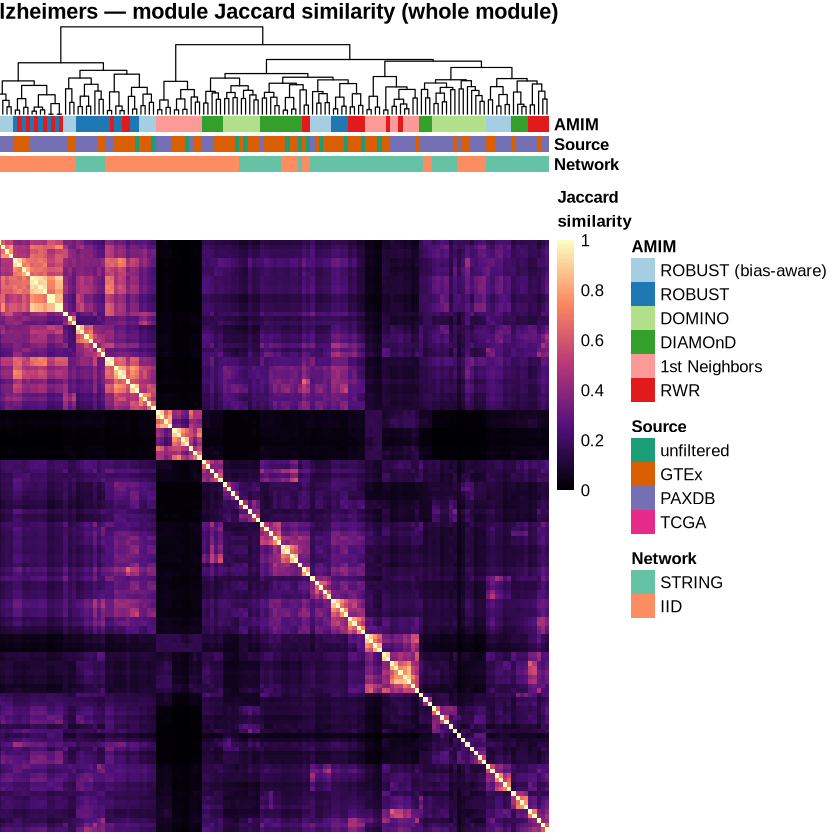

Warning message in plot_module_similarity_heatmap(RUNS[[disease]], disease, node_scope):
“22 / 154 ids in diabetes_typeII jaccard matrix (whole_module) are not AMIM modules (e.g. no_tool), dropping”


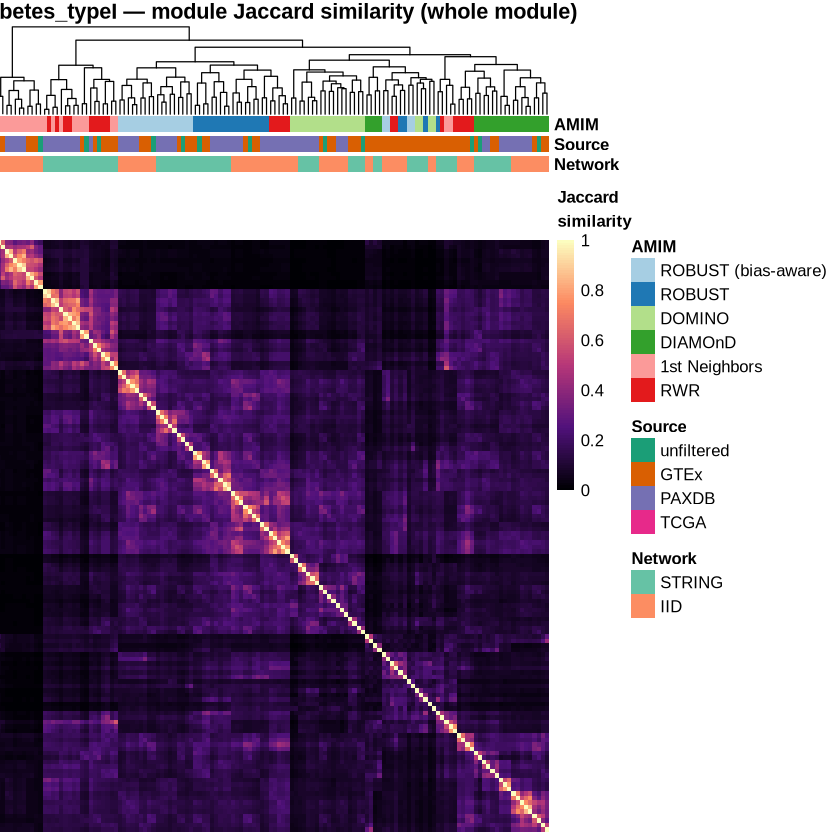

Warning message in plot_module_similarity_heatmap(RUNS[[disease]], disease, node_scope):
“22 / 154 ids in LUAD jaccard matrix (whole_module) are not AMIM modules (e.g. no_tool), dropping”


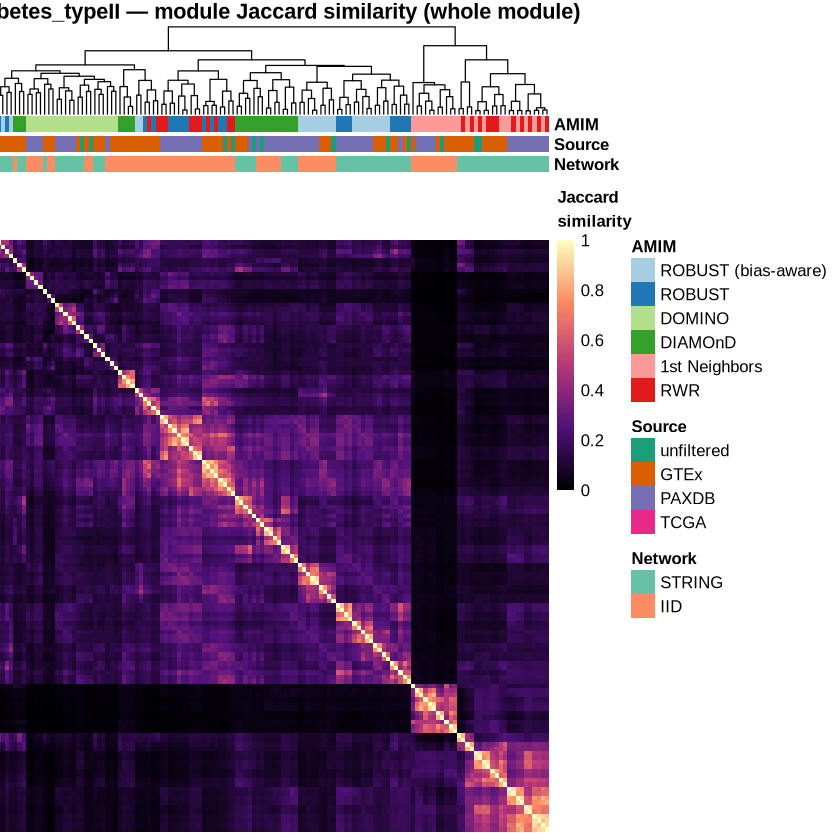

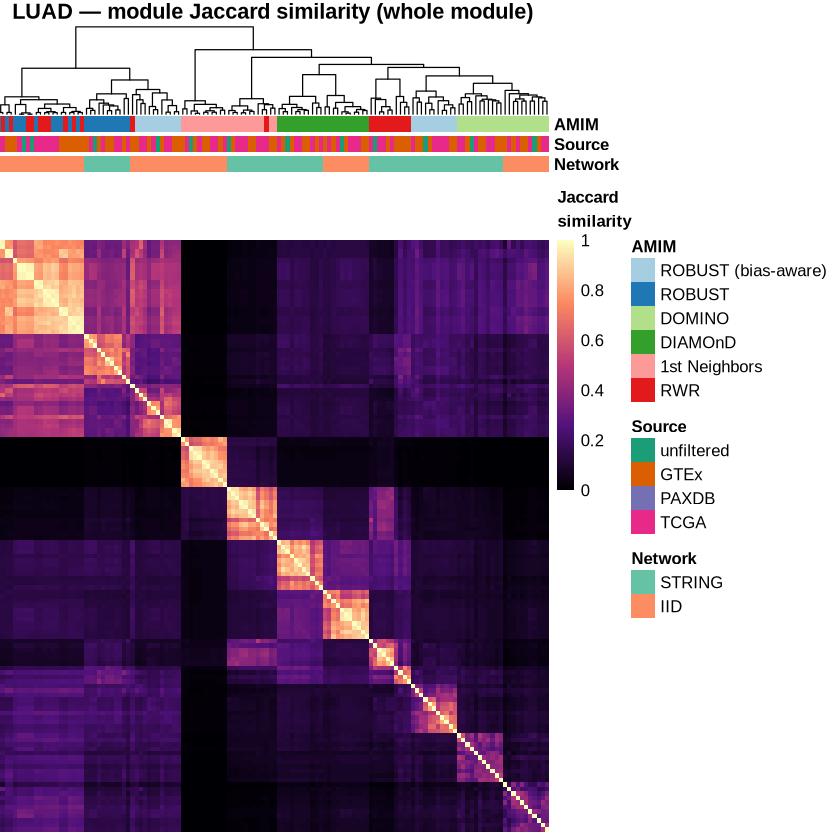

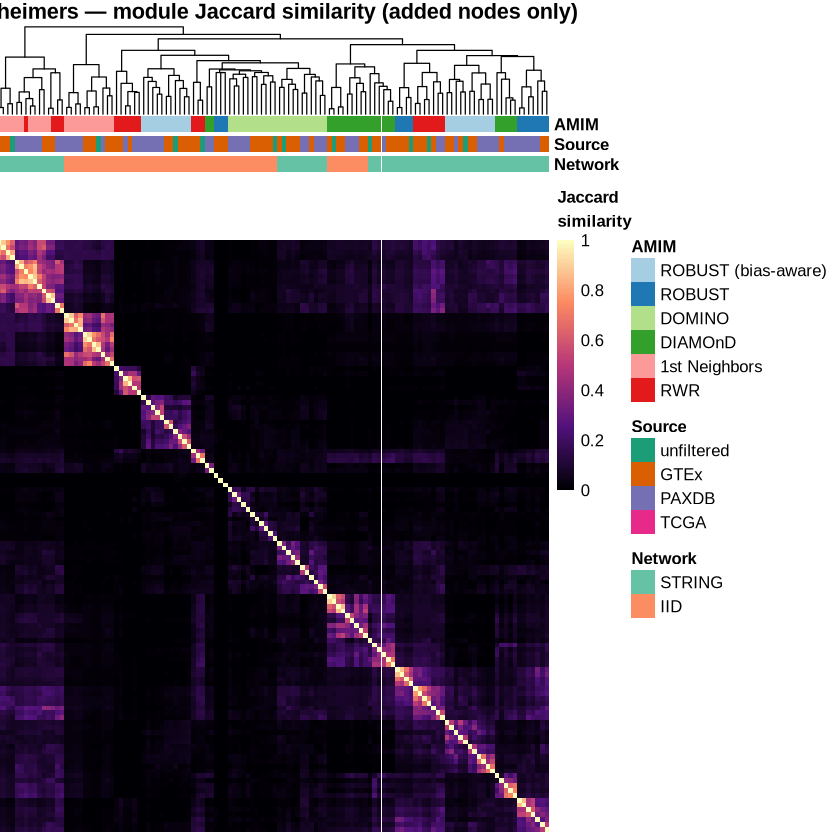

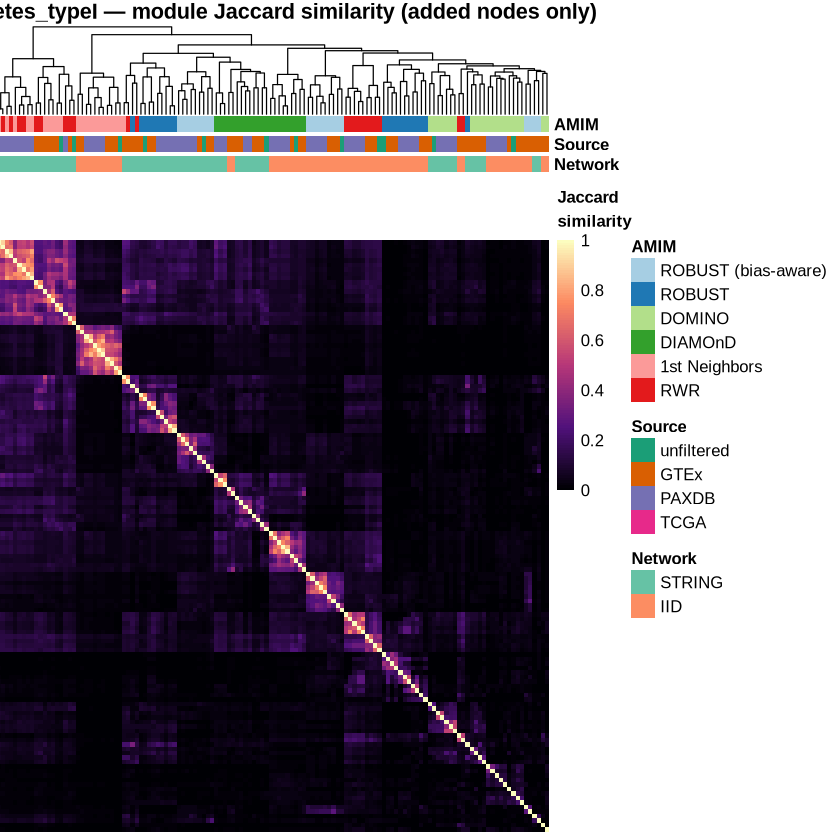

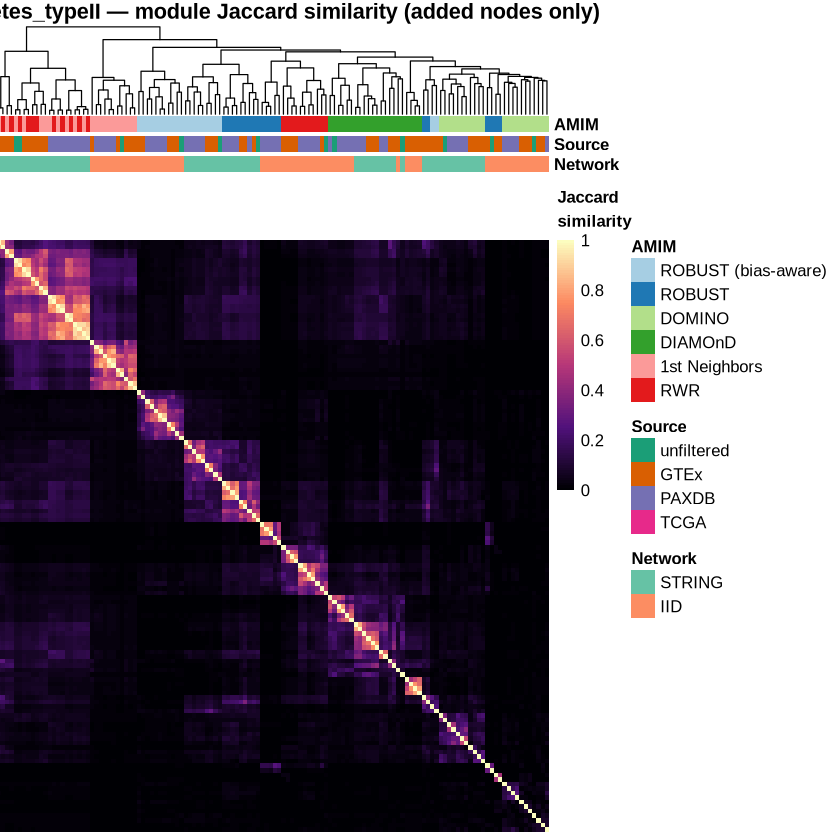

# A tibble: 8 × 3
  node_scope       disease         n_modules
  <chr>            <chr>               <int>
1 whole_module     alzheimers            132
2 whole_module     diabetes_typeI        132
3 whole_module     diabetes_typeII       132
4 whole_module     LUAD                  132
5 added_nodes_only alzheimers            122
6 added_nodes_only diabetes_typeI        132
7 added_nodes_only diabetes_typeII       130
8 added_nodes_only LUAD                  122


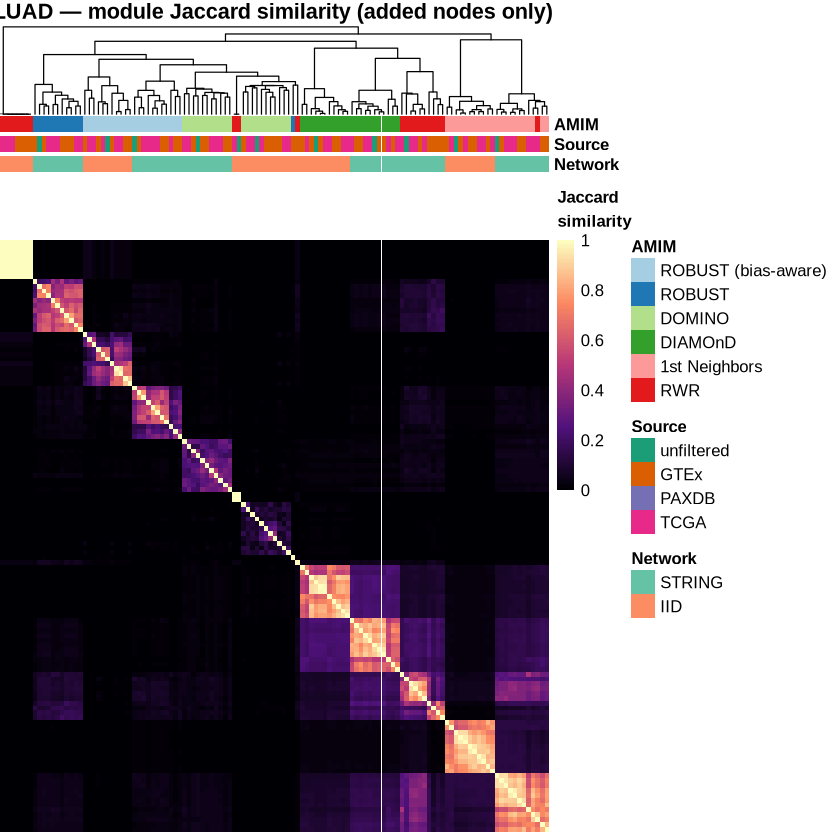

In [66]:
MODULE_SIMILARITY_OUTDIR <- file.path(REPO_ROOT, "results_analysis_output", "module_similarity")
dir.create(MODULE_SIMILARITY_OUTDIR, recursive = TRUE, showWarnings = FALSE)

NETWORK_LABELS <- c(string = "STRING", iid = "IID")

JACCARD_LEGEND_BREAKS <- c(0, 0.2, 0.4, 0.6, 0.8, 1)
JACCARD_LEGEND_LABELS <- c("0", "0.2", "0.4", "0.6", "0.8", "1")
JACCARD_LEGEND_TITLE  <- "Jaccard\nsimilarity"

# pheatmap has no direct "legend title" argument, and the common workaround (an extra
# legend_breaks entry beyond the color scale's max, whose label is meant to be drawn above
# the color bar) silently clips in this pheatmap version -- the computed position falls
# outside the legend cell's own viewport, which the surrounding gtable then cuts off. The
# title is added for real instead, as a text row inserted above the "legend" cell.
add_colorbar_title <- function(gt, title, fontsize = 10) {
  legend_rows <- which(gt$layout$name == "legend")
  if (length(legend_rows) == 0) return(gt)
  legend_row <- gt$layout$t[legend_rows[1]]
  legend_col <- gt$layout$l[legend_rows[1]]
  title_grob <- grid::textGrob(title, gp = grid::gpar(fontsize = fontsize, fontface = "bold"), just = "left", x = 0)
  # extra bottom padding (beyond the title's own text height) so the color bar's
  # top break label -- vertically centered on the bar's top edge, so half of it
  # pokes up above the bar -- has room to clear the title text instead of overlapping it
  title_height <- grid::unit(1, "grobheight", title_grob) + grid::unit(16, "bigpts")
  # carve the title out of the legend row's own height (rather than growing the gtable's
  # total height) so the combined figure's fixed-size legend cell isn't overflowed --
  # arrangeGrob() sizes that cell to the *original* legend height, and a taller gtable
  # placed inside it just gets its top sliced off by the device/page edge
  gt$heights[legend_row] <- gt$heights[legend_row] - title_height
  gt <- gtable::gtable_add_rows(gt, title_height, pos = legend_row - 1)
  gt <- gtable::gtable_add_grob(gt, title_grob, t = legend_row, l = legend_col, name = "legend_title")
  gt$widths[legend_col] <- max(gt$widths[legend_col], grid::unit(1, "grobwidth", title_grob))
  gt
}

# same two node scopes used by the g:Profiler section above: the whole module vs.
# just the non-seed nodes an AMIM added
NODE_SCOPES <- c("whole_module", "added_nodes_only")
NODE_SCOPE_LABELS <- c(whole_module = "whole module", added_nodes_only = "added nodes only")
JACCARD_MATRIX_FILENAMES <- c(
  whole_module = "jaccard_similarity_matrix_mqc.tsv",
  added_nodes_only = "jaccard_similarity_no_seeds_matrix_mqc.tsv"
)

read_jaccard_matrix <- function(run_dir, node_scope) {
  mqc_file <- file.path(run_dir, "mqc_summaries", JACCARD_MATRIX_FILENAMES[[node_scope]])
  if (!file.exists(mqc_file)) {
    warning("Missing jaccard similarity matrix (", node_scope, "): ", mqc_file)
    return(NULL)
  }
  raw <- read_tsv(mqc_file, show_col_types = FALSE)
  mat <- as.matrix(raw %>% select(-ID))
  rownames(mat) <- raw$ID
  mat
}

# saves a pheatmap object (drawn with silent = TRUE) to PNG, since pheatmap's own
# `filename` argument draws to file instead of the active device
save_pheatmap_png <- function(p, filename, width, height, res = 300) {
  png(filename, width = width, height = height, units = "in", res = res)
  grid::grid.newpage()
  grid::grid.draw(p$gtable)
  dev.off()
}

plot_module_similarity_heatmap <- function(run_dir, disease, node_scope) {
  mat <- read_jaccard_matrix(run_dir, node_scope)
  if (is.null(mat)) return(NULL)

  meta <- parse_run_id(rownames(mat))
  meta$threshold <- as.double(meta$threshold)  # parse_run_id leaves it as character; numeric needed to sort thresholds correctly below
  keep <- !is.na(meta$amim)  # drops the raw "no_tool" network entries (not AMIM modules)
  if (any(!keep)) {
    warning(sum(!keep), " / ", nrow(meta), " ids in ", disease,
            " jaccard matrix (", node_scope, ") are not AMIM modules (e.g. no_tool), dropping")
  }
  meta <- meta[keep, ]
  mat <- mat[keep, keep, drop = FALSE]
  if (nrow(mat) < 2) return(NULL)

  # thresholds aren't comparable across sources, so levels/colors are built per-disease
  # from whatever thresholds actually occur in this run, ordered low -> high
  threshold_label <- if_else(meta$filtered, as.character(meta$threshold), "unfiltered")
  threshold_values_sorted <- sort(unique(meta$threshold[meta$filtered]))
  threshold_levels <- c("unfiltered", as.character(threshold_values_sorted))
  threshold_colors <- c(
    unfiltered = "grey85",
    setNames(
      colorRampPalette(brewer.pal(9, "YlOrRd"))(length(threshold_values_sorted)),
      as.character(threshold_values_sorted)
    )
  )

  annotation <- data.frame(
    Network   = unname(NETWORK_LABELS[meta$network]),
    Source    = if_else(meta$filtered, meta$source, "unfiltered"),
    #Threshold = factor(threshold_label, levels = threshold_levels),
    AMIM      = unname(AMIM_LABELS[meta$amim]),
    row.names = rownames(mat),
    stringsAsFactors = FALSE
  )

  network_levels <- unname(NETWORK_LABELS[KNOWN_NETWORKS])
  source_levels  <- c("unfiltered", KNOWN_SOURCES)
  amim_levels    <- unname(AMIM_LABELS[KNOWN_AMIMS])

  annotation_colors <- list(
    Network   = setNames(brewer.pal(max(3, length(network_levels)), "Set2")[seq_along(network_levels)], network_levels),
    Source    = setNames(brewer.pal(max(3, length(source_levels)), "Dark2")[seq_along(source_levels)], source_levels),
   #Threshold = threshold_colors,
    AMIM      = setNames(brewer.pal(max(3, length(amim_levels)), "Paired")[seq_along(amim_levels)], amim_levels)
  )

  # only annotate columns (not rows) so the color bars sit along the top edge only,
  # matching the reference figure's layout; the matrix is symmetric so this loses no information
  ph <- pheatmap(
    mat,
    color = colorRampPalette(c("#000004", "#51127c", "#b73779", "#fc8961", "#fcfdbf"))(100),
    breaks = seq(0, 1, length.out = 101),
    annotation_col = annotation,
    annotation_colors = annotation_colors,
    show_rownames = FALSE,
    show_colnames = FALSE,
    treeheight_row = 0,
    border_color = NA,
    legend_breaks = JACCARD_LEGEND_BREAKS,
    legend_labels = JACCARD_LEGEND_LABELS,
    main = paste0(disease, " — module Jaccard similarity (", NODE_SCOPE_LABELS[node_scope], ")"),
    silent = TRUE
  )
  ph$gtable <- add_colorbar_title(ph$gtable, JACCARD_LEGEND_TITLE)
  attr(ph, "n_modules") <- nrow(mat)
  ph
}

module_similarity_heatmaps <- list()
module_similarity_dims <- tibble(node_scope = character(), disease = character(), n_modules = integer())
for (node_scope in NODE_SCOPES) {
  scope_outdir <- file.path(MODULE_SIMILARITY_OUTDIR, node_scope)
  dir.create(scope_outdir, recursive = TRUE, showWarnings = FALSE)

  for (disease in names(RUNS)) {
    p <- plot_module_similarity_heatmap(RUNS[[disease]], disease, node_scope)
    if (is.null(p)) {
      warning("No module similarity data for disease=", disease, " node_scope=", node_scope)
      next
    }
    module_similarity_heatmaps[[node_scope]][[disease]] <- p
    module_similarity_dims <- bind_rows(
      module_similarity_dims,
      tibble(node_scope = node_scope, disease = disease, n_modules = attr(p, "n_modules"))
    )
    grid::grid.newpage()
    grid::grid.draw(p$gtable)
    save_pheatmap_png(
      p, file.path(scope_outdir, paste0(disease, ".png")),
      width = 9, height = 8
    )
  }
}

# per-disease heatmaps pool all 6 AMIMs together (2 networks x 2 sources x 5 thresholds x 6 amims
# + 2 networks x 6 amims baseline = 132), not 88 -- that count is specific to the single-AMIM,
# pooled-across-diseases heatmaps below
print(module_similarity_dims)

## Method-wise module similarity across diseases

Same "Jaccard Similarity" heatmap concept as above, but pooled across diseases per AMIM (one heatmap per AMIM, all diseases combined) — matching the multi-disease, per-method Jaccard heatmap layout used in the pipeline paper (Kersting et al. 2025), which MultiQC itself cannot produce since it only ever compares modules from a single validation run/disease. Module node sets are re-read directly from each run's `disease_modules/tsv_nodes/<id>.nodes.tsv` files (the same `name`/`is_seed` node lists `bin/module_overlap.py` consumes as `--inputs`) and Jaccard similarity is recomputed here across the pooled, per-AMIM set of modules. Covers both node scopes from the section above: `whole_module` (all nodes) and `added_nodes_only` (`is_seed == 0`, dropping any module left empty after seed removal, same as `module_overlap.py`'s own no-seeds matrix). Color annotation bars mark **Disease**, **Network**, **Filtering source** (`unfiltered` for baseline modules), and **Threshold** (ordinal gradient over whatever threshold values occur for this AMIM/node scope, pooled across all diseases/sources — same treatment as the per-disease heatmap above). Output: `results_analysis_output/module_similarity/method_comparison/<node_scope>/<amim>.png`.

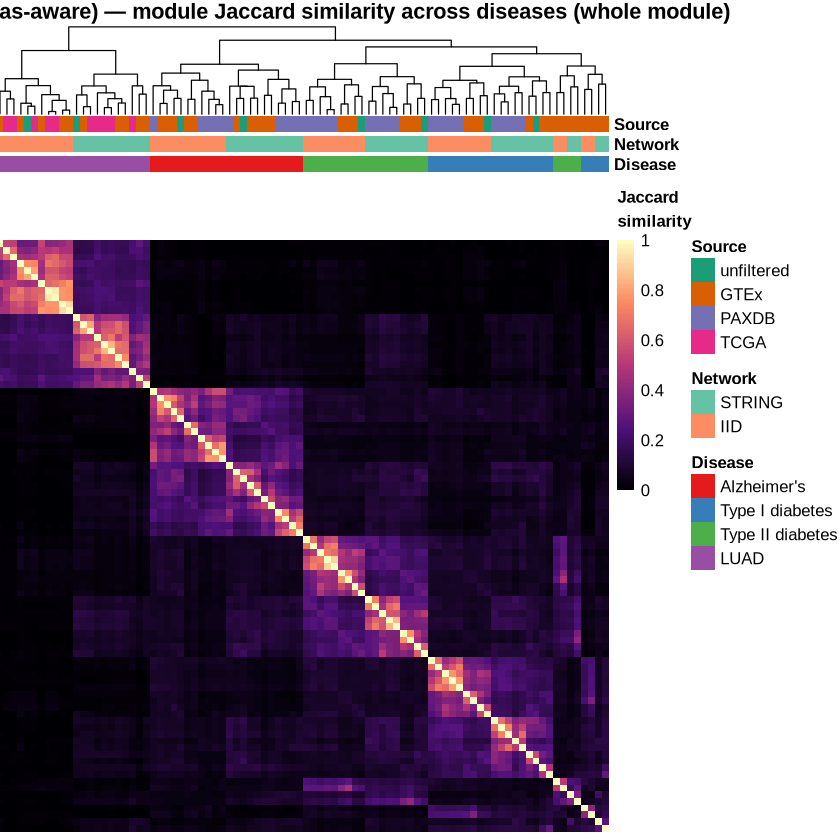

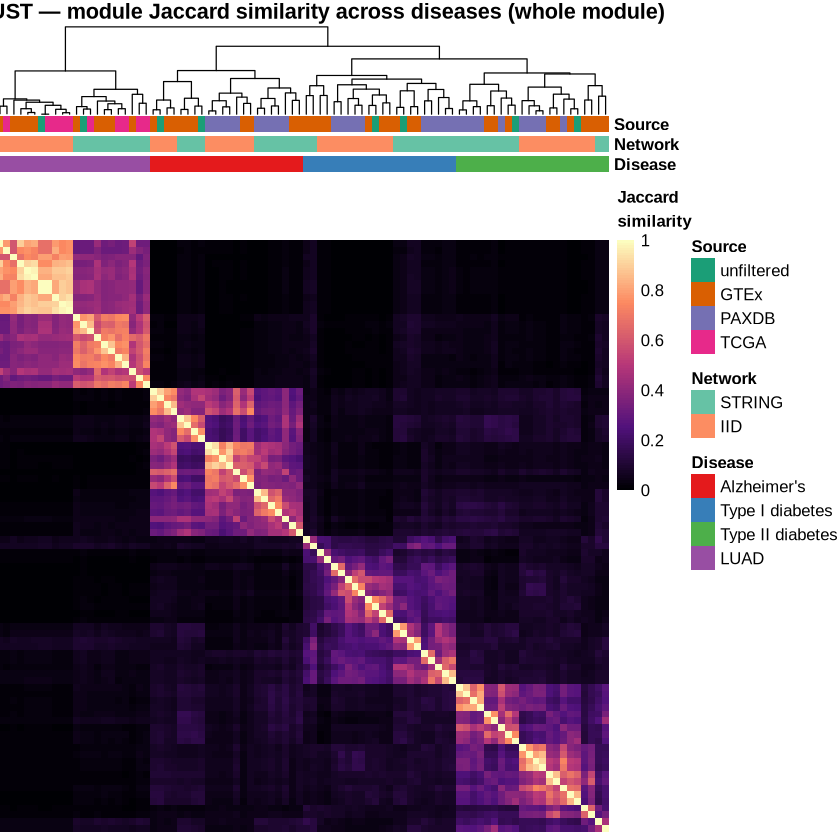

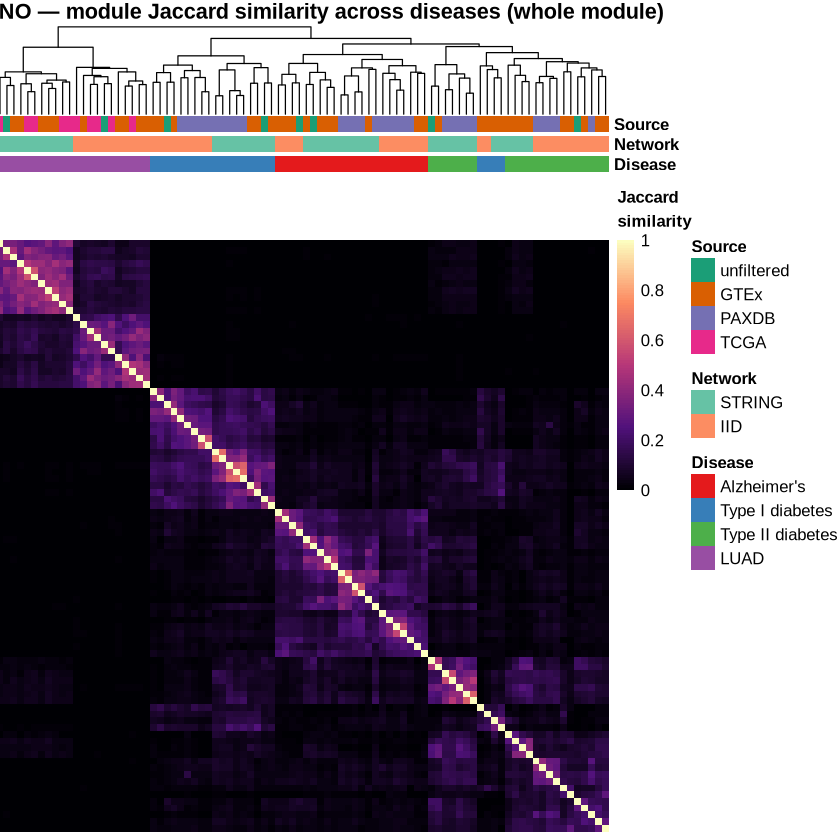

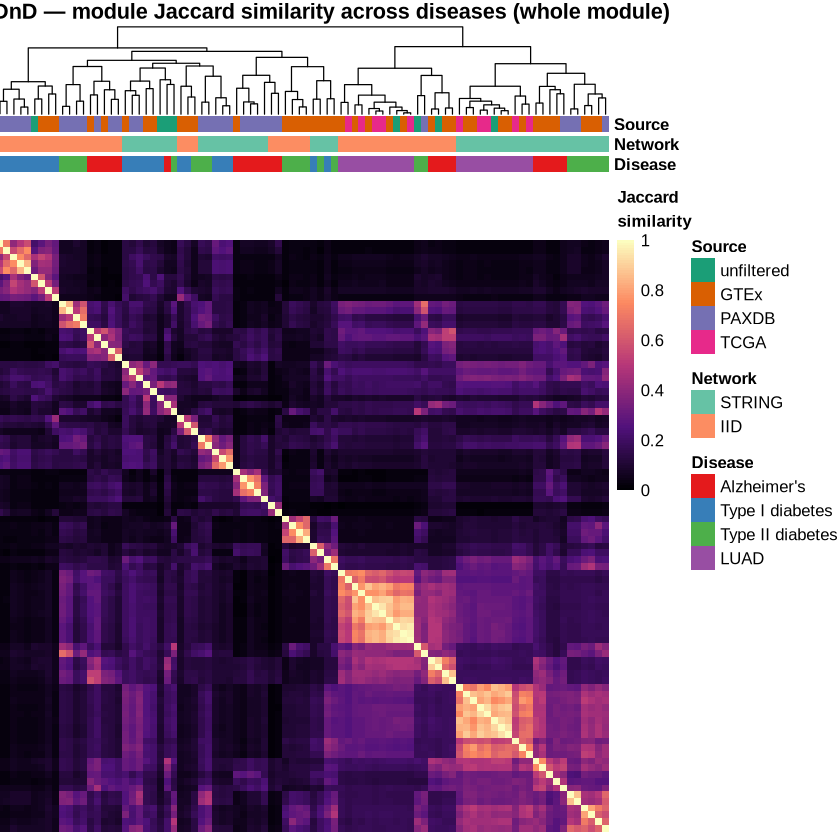

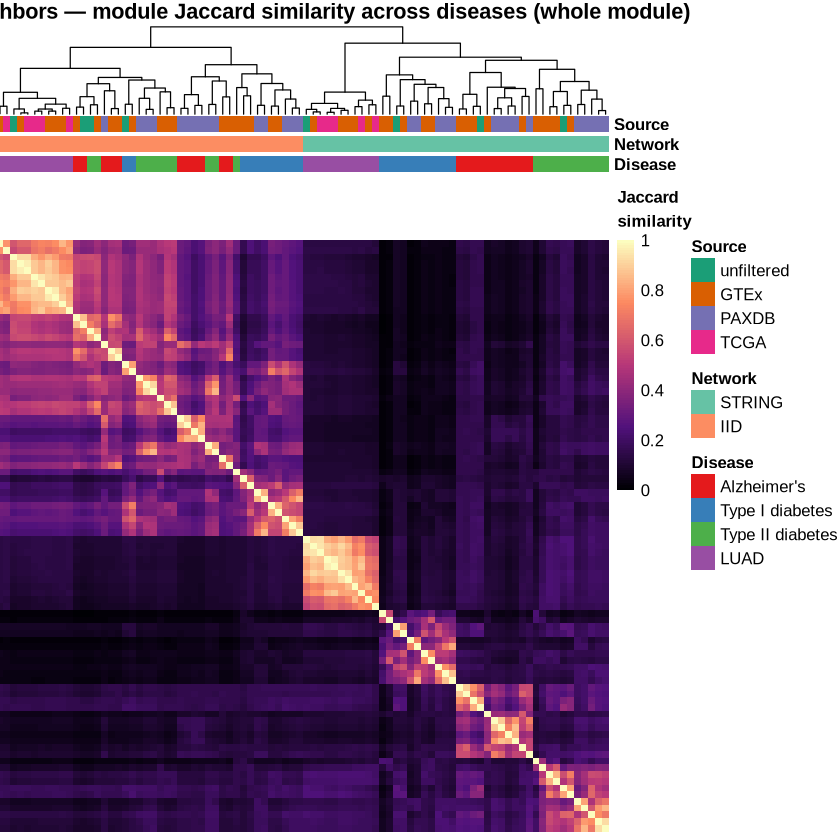

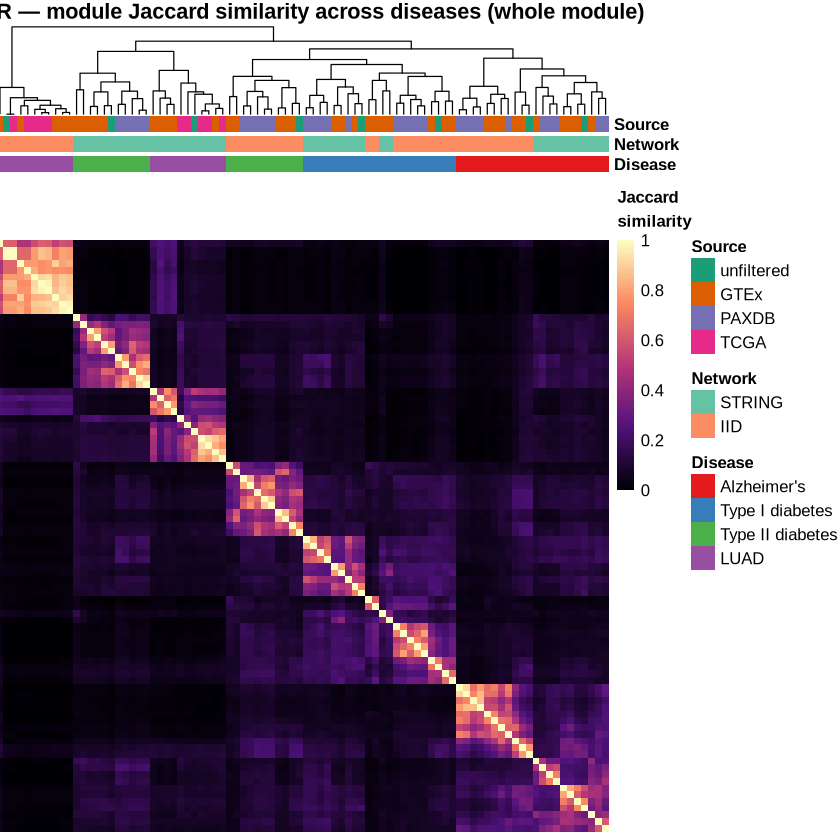

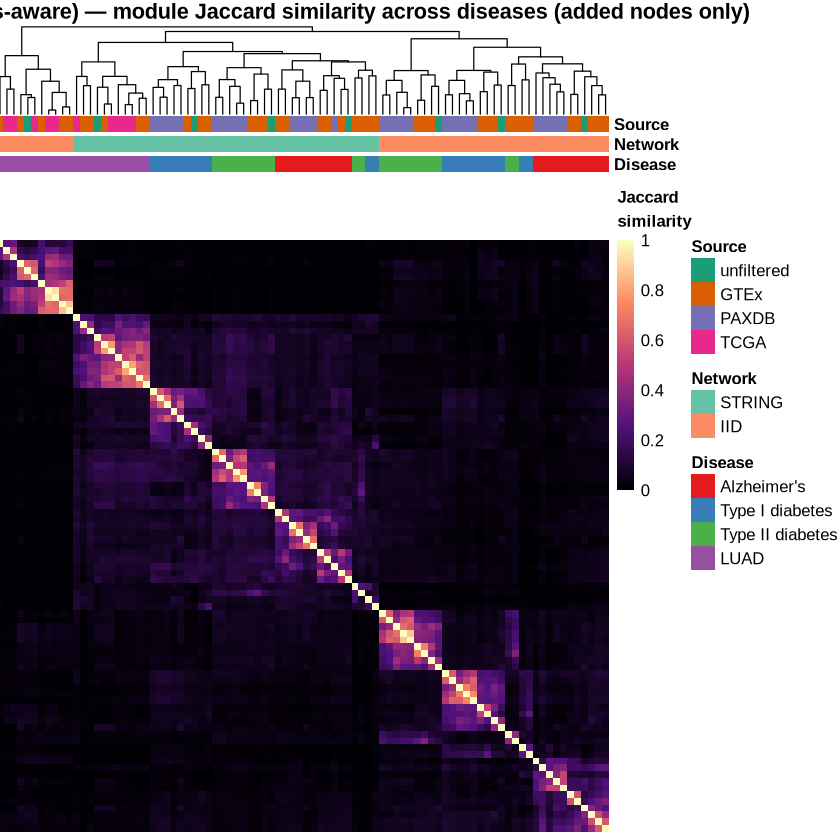

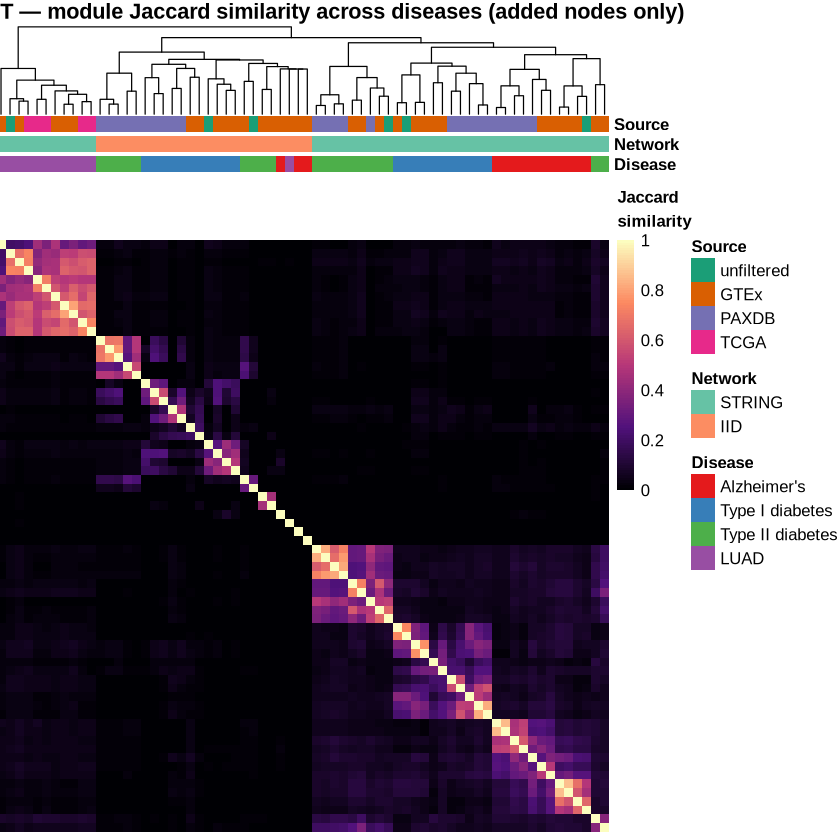

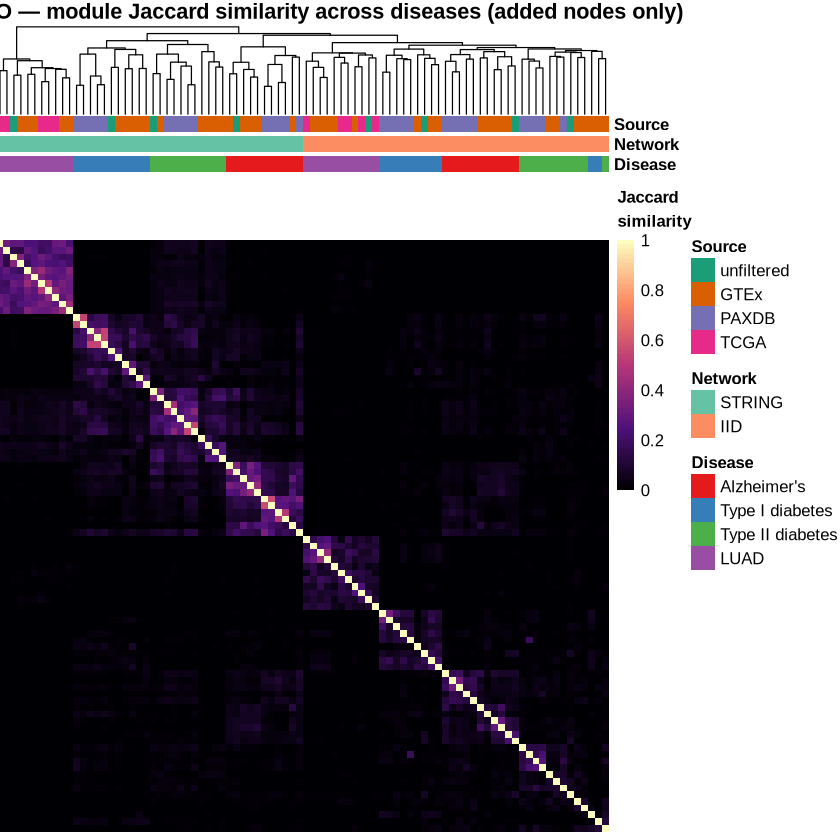

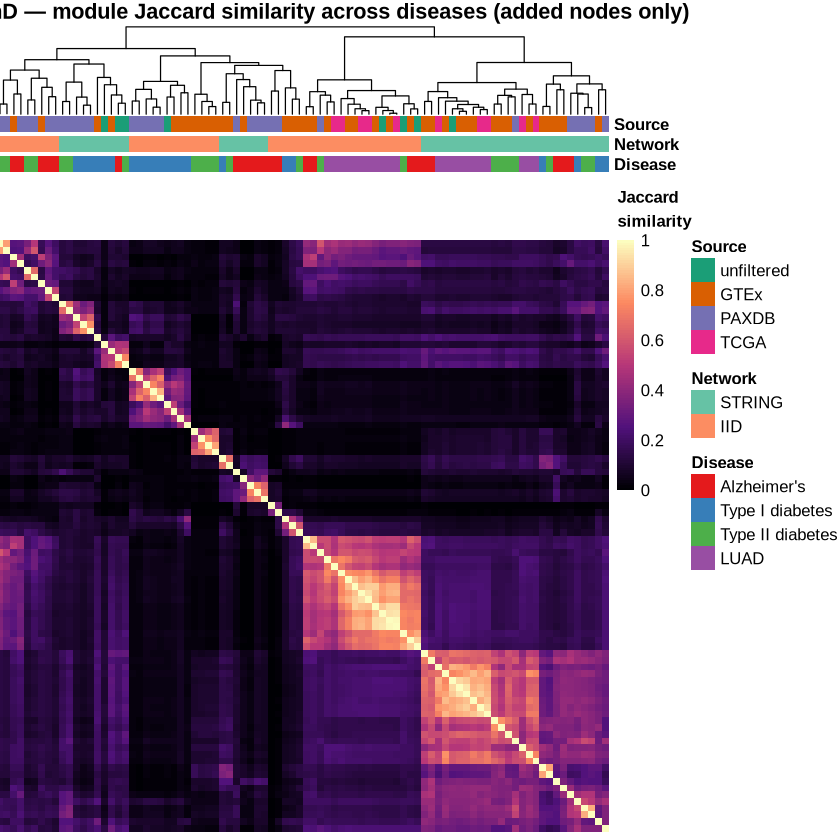

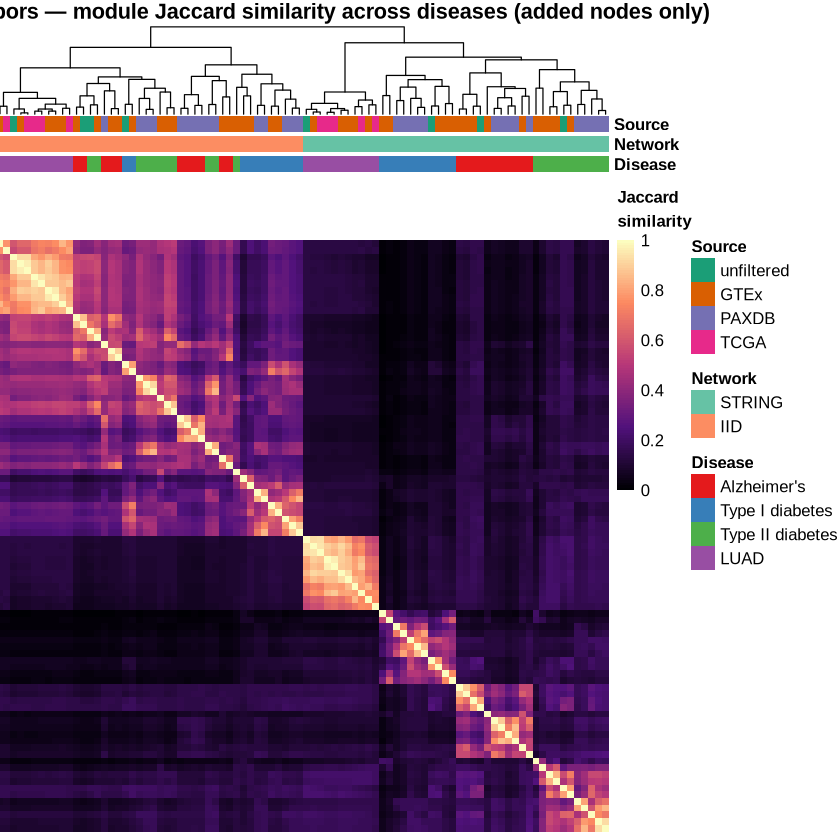

# A tibble: 12 × 4
   node_scope       amim              n_modules expected_88
   <chr>            <chr>                 <int> <lgl>      
 1 whole_module     robust_bias_aware        88 TRUE       
 2 whole_module     robust                   88 TRUE       
 3 whole_module     domino                   88 TRUE       
 4 whole_module     diamond                  88 TRUE       
 5 whole_module     firstneighbor            88 TRUE       
 6 whole_module     rwr                      88 TRUE       
 7 added_nodes_only robust_bias_aware        88 TRUE       
 8 added_nodes_only robust                   68 FALSE      
 9 added_nodes_only domino                   88 TRUE       
10 added_nodes_only diamond                  88 TRUE       
11 added_nodes_only firstneighbor            88 TRUE       
12 added_nodes_only rwr                      86 FALSE      


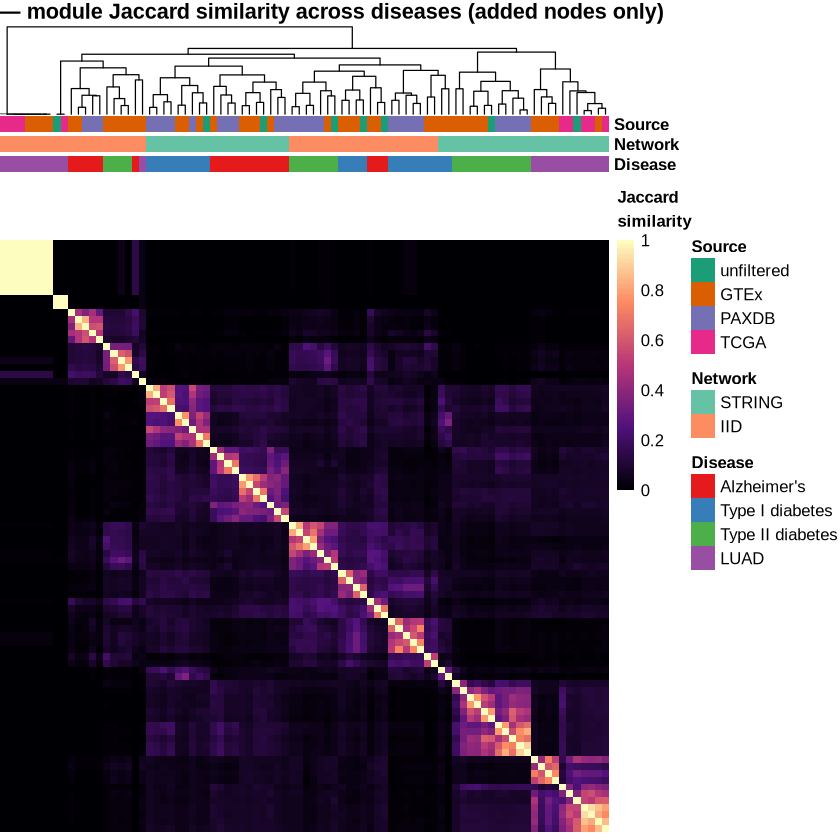

In [ ]:
METHOD_SIMILARITY_OUTDIR <- file.path(MODULE_SIMILARITY_OUTDIR, "method_comparison")

DISEASE_LABELS <- c(
  alzheimers = "Alzheimer's", diabetes_typeI = "Type I diabetes",
  diabetes_typeII = "Type II diabetes", LUAD = "LUAD"
)

list_module_node_files <- function(run_dir) {
  # published under "disease_modules/tsv_nodes" (see conf/modules.config: publishDir
  # "${params.outdir}/disease_modules", with .nodes.tsv routed into a tsv_nodes/ subfolder)
  base <- file.path(run_dir, "disease_modules", "tsv_nodes")
  if (!dir.exists(base)) return(character(0))
  list.files(base, pattern = "\\.nodes\\.tsv$", full.names = TRUE)
}

# node_scope == "added_nodes_only" keeps only the non-seed ("added") nodes, mirroring
# module_overlap.py's own no-seeds matrix
read_module_gene_set <- function(f, node_scope) {
  df <- read_tsv(f, show_col_types = FALSE,
                  col_types = cols_only(name = col_character(), is_seed = col_double()))
  if (node_scope == "added_nodes_only") df <- df %>% filter(is_seed == 0)
  as.character(df$name)
}

# every module across every run, keyed by disease + id (the same id string can recur
# across diseases, e.g. "entrez_seeds_1...", since each run reuses the same seeds_id
# naming convention for its own, disease-specific seed file)
module_registry <- imap_dfr(RUNS, function(run_dir, disease) {
  files <- list_module_node_files(run_dir)
  if (length(files) == 0) {
    warning("No module node files found for disease=", disease, " in ", run_dir)
    return(NULL)
  }
  ids <- str_remove(basename(files), "\\.nodes\\.tsv$")
  bind_cols(tibble(disease = disease, id = ids, file = files), parse_run_id(ids) %>% select(-id))
}) %>%
  filter(!is.na(amim)) %>%  # drops the raw "no_tool" network entries (not AMIM modules)
  mutate(
    threshold = as.double(threshold),  # parse_run_id leaves it as character; numeric needed to sort thresholds correctly below
    unique_id = paste(disease, id, sep = "::")
  )

compute_jaccard_matrix <- function(sets, ids) {
  n <- length(sets)
  m <- matrix(1, n, n, dimnames = list(ids, ids))
  if (n < 2) return(m)
  for (i in seq_len(n - 1)) {
    for (j in seq(i + 1, n)) {
      value <- length(intersect(sets[[i]], sets[[j]])) / length(union(sets[[i]], sets[[j]]))
      m[i, j] <- value
      m[j, i] <- value
    }
  }
  m
}

plot_method_similarity_heatmap <- function(amim, node_scope, legend = TRUE, annotation_legend = TRUE,
                                            annotation_names_col = annotation_legend, title = NULL) {
  reg <- module_registry %>% filter(amim == !!amim)
  if (nrow(reg) < 2) return(NULL)

  sets <- map(reg$file, read_module_gene_set, node_scope = node_scope)

  # module_overlap.py drops modules left empty after removing seeds (added_nodes_only only)
  non_empty <- lengths(sets) > 0
  if (any(!non_empty)) {
    reg <- reg[non_empty, ]
    sets <- sets[non_empty]
  }
  if (nrow(reg) < 2) return(NULL)

  mat <- compute_jaccard_matrix(sets, reg$unique_id)

  # thresholds aren't comparable across sources (or diseases), so levels/colors are built
  # per-call from whatever thresholds actually occur for this AMIM/node scope, ordered low -> high
  threshold_label <- if_else(reg$filtered, as.character(reg$threshold), "unfiltered")
  threshold_values_sorted <- sort(unique(reg$threshold[reg$filtered]))
  threshold_levels <- c("unfiltered", as.character(threshold_values_sorted))
  threshold_colors <- c(
    unfiltered = "grey85",
    setNames(
      colorRampPalette(brewer.pal(9, "YlOrRd"))(length(threshold_values_sorted)),
      as.character(threshold_values_sorted)
    )
  )

  annotation <- data.frame(
    Disease   = unname(DISEASE_LABELS[reg$disease]),
    Network   = unname(NETWORK_LABELS[reg$network]),
    Source    = if_else(reg$filtered, reg$source, "unfiltered"),
    #Threshold = factor(threshold_label, levels = threshold_levels),
    row.names = reg$unique_id,
    stringsAsFactors = FALSE
  )

  disease_levels <- unname(DISEASE_LABELS[names(RUNS)])
  network_levels <- unname(NETWORK_LABELS[KNOWN_NETWORKS])
  source_levels  <- c("unfiltered", KNOWN_SOURCES)

  annotation_colors <- list(
    Disease   = setNames(brewer.pal(max(3, length(disease_levels)), "Set1")[seq_along(disease_levels)], disease_levels),
    Network   = setNames(brewer.pal(max(3, length(network_levels)), "Set2")[seq_along(network_levels)], network_levels),
    Source    = setNames(brewer.pal(max(3, length(source_levels)), "Dark2")[seq_along(source_levels)], source_levels)
    #Threshold = threshold_colors
  )

  if (is.null(title)) {
    title <- paste0(AMIM_LABELS[amim], " — module Jaccard similarity across diseases (", NODE_SCOPE_LABELS[node_scope], ")")
  }

  ph <- pheatmap(
    mat,
    color = colorRampPalette(c("#000004", "#51127c", "#b73779", "#fc8961", "#fcfdbf"))(100),
    breaks = seq(0, 1, length.out = 101),
    annotation_col = annotation,
    annotation_colors = annotation_colors,
    show_rownames = FALSE,
    show_colnames = FALSE,
    treeheight_row = 0,
    border_color = NA,
    legend_breaks = JACCARD_LEGEND_BREAKS,
    legend_labels = JACCARD_LEGEND_LABELS,
    legend = legend,
    annotation_legend = annotation_legend,
    annotation_names_col = annotation_names_col,
    main = title,
    silent = TRUE
  )
  ph$gtable <- add_colorbar_title(ph$gtable, JACCARD_LEGEND_TITLE)
  attr(ph, "n_modules") <- nrow(mat)
  ph
}

method_similarity_heatmaps <- list()
method_similarity_dims <- tibble(node_scope = character(), amim = character(), n_modules = integer())
for (node_scope in NODE_SCOPES) {
  scope_outdir <- file.path(METHOD_SIMILARITY_OUTDIR, node_scope)
  dir.create(scope_outdir, recursive = TRUE, showWarnings = FALSE)

  for (amim in KNOWN_AMIMS) {
    p <- plot_method_similarity_heatmap(amim, node_scope)
    if (is.null(p)) {
      warning("No pooled module similarity data for amim=", amim, " node_scope=", node_scope)
      next
    }
    method_similarity_heatmaps[[node_scope]][[amim]] <- p
    method_similarity_dims <- bind_rows(
      method_similarity_dims,
      tibble(node_scope = node_scope, amim = amim, n_modules = attr(p, "n_modules"))
    )
    grid::grid.newpage()
    grid::grid.draw(p$gtable)
    save_pheatmap_png(
      p, file.path(scope_outdir, paste0(amim, ".png")),
      width = 9, height = 8
    )
  }
}

# whole_module heatmaps pool 4 diseases x (2 networks x 2 sources x 5 thresholds
# + 2 network baselines) = 4 x 22 = 88 modules per AMIM when nothing failed/was dropped;
# added_nodes_only can be < 88 since module_overlap.py's own no-seeds logic drops any
# module left empty after removing seeds
print(method_similarity_dims %>% mutate(expected_88 = n_modules == 88))

## Combined method-wise figure (all AMIMs, one legend)

Merges the per-AMIM heatmaps above into a single figure — one panel per (node scope, AMIM), arranged as `whole_module`/`added_nodes_only` rows x the six AMIMs as columns, matching the reference figure's layout (AMIM column headers on the top row only, one shared color scale + one shared annotation legend on the right instead of one per panel). Uses `gtable::gtable_filter()` to pull the legend grobs out of a single reference panel (colors/levels are identical across panels since they come from the fixed `KNOWN_NETWORKS`/`KNOWN_SOURCES`/`DISEASE_LABELS` lists, not from per-panel data) and `gridExtra::arrangeGrob()` to lay everything out. Output: `results_analysis_output/module_similarity/method_comparison/combined.png`.


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




agg_record_2ff7402c2033d3 
                        2

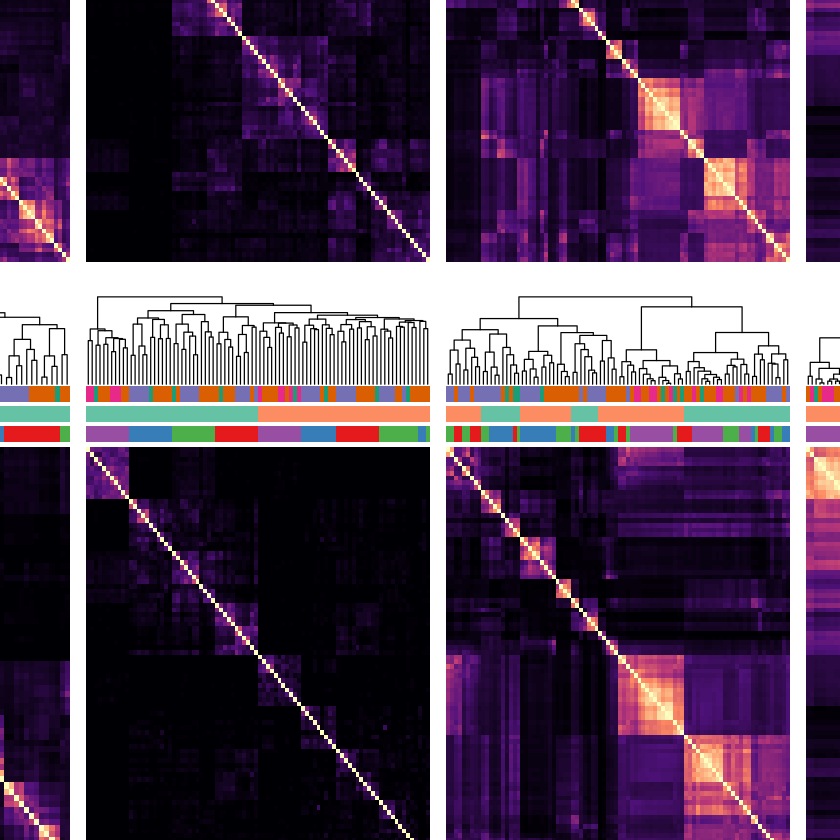

In [27]:
library(gridExtra)
library(gtable)

save_grob_png <- function(g, filename, width, height, res = 300) {
  png(filename, width = width, height = height, units = "in", res = res)
  grid::grid.newpage()
  grid::grid.draw(g)
  dev.off()
}

extract_legend_grob <- function(ph) {
  gtable::gtable_filter(ph$gtable, "legend", fixed = FALSE)
}

build_combined_method_similarity_figure <- function(node_scopes = NODE_SCOPES, amims = KNOWN_AMIMS) {
  panel_grobs <- list()
  legend_grob <- NULL

  for (node_scope in node_scopes) {
    for (amim in amims) {
      # AMIM name as a column header on the top row only, like the reference figure
      title <- if (node_scope == node_scopes[1]) AMIM_LABELS[[amim]] else ""
      need_legend <- is.null(legend_grob)

      ph <- plot_method_similarity_heatmap(
        amim, node_scope,
        legend = need_legend, annotation_legend = need_legend,
        title = title
      )
      if (is.null(ph)) {
        warning("No pooled module similarity data for amim=", amim, " node_scope=", node_scope, " (combined figure)")
        panel_grobs[[paste(node_scope, amim, sep = "::")]] <- grid::nullGrob()
        next
      }
      if (need_legend) {
        legend_grob <- extract_legend_grob(ph)
        # redraw the same panel without its own legend so every panel is the same width
        ph <- plot_method_similarity_heatmap(amim, node_scope, legend = FALSE, annotation_legend = FALSE, title = title)
      }
      panel_grobs[[paste(node_scope, amim, sep = "::")]] <- ph$gtable
    }
  }

  list(panels = panel_grobs, legend = legend_grob)
}

combined <- build_combined_method_similarity_figure()

n_amim  <- length(KNOWN_AMIMS)
n_scope <- length(NODE_SCOPES)

row_label_grobs <- lapply(NODE_SCOPES, function(ns) {
  grid::textGrob(NODE_SCOPE_LABELS[[ns]], rot = 90, gp = grid::gpar(fontface = "bold", fontsize = 12))
})

# grob index layout: row labels (1 per row) | panels (node_scope x amim, row-major) | one shared legend
# spanning the full width in a row below the panels
legend_idx <- n_scope + n_amim * n_scope + 1
layout_matrix <- rbind(
  cbind(
    matrix(seq_len(n_scope), ncol = 1),
    matrix(n_scope + seq_len(n_amim * n_scope), nrow = n_scope, byrow = TRUE)
  ),
  matrix(rep(legend_idx, n_amim + 1), nrow = 1)
)

# absolute (inch) widths/heights, not relative fractions: the legend's content has a
# fixed size regardless of how many heatmap columns there are, so a relative fraction
# (e.g. "0.35 of one panel") shrinks along with the panels and starts overlapping them
row_label_width  <- 0.3
panel_width      <- 3
legend_height    <- 2.5
panel_height     <- 5

combined_plot <- gridExtra::arrangeGrob(
  grobs = c(row_label_grobs, combined$panels, list(combined$legend)),
  layout_matrix = layout_matrix,
  widths = grid::unit(c(row_label_width, rep(panel_width, n_amim)), "in"),
  heights = grid::unit(c(rep(panel_height, n_scope), legend_height), "in")
)

grid::grid.newpage()
grid::grid.draw(combined_plot)
save_grob_png(
  combined_plot,
  file.path(METHOD_SIMILARITY_OUTDIR, "combined.png"),
  width = row_label_width + panel_width * n_amim,
  height = panel_height * n_scope + legend_height
)

In [ ]:
seed_only_modules <- module_registry %>%
  filter(amim %in% c("robust", "rwr")) %>%
  mutate(is_seed_only = map_lgl(file, function(f) {
    df <- read_tsv(f, show_col_types = FALSE, col_types = cols_only(is_seed = col_double()))
    all(df$is_seed == 1)
  })) %>%
  filter(is_seed_only) %>%
  select(disease, network, source, threshold, filtered, amim)

print(seed_only_modules, n = Inf)

# A tibble: 22 × 6
   disease         network source threshold filtered amim  
   <chr>           <chr>   <chr>      <dbl> <lgl>    <chr> 
 1 alzheimers      iid     GTEx         2   TRUE     robust
 2 alzheimers      iid     GTEx         5   TRUE     robust
 3 alzheimers      iid     PAXDB        0.1 TRUE     robust
 4 alzheimers      iid     PAXDB        1   TRUE     robust
 5 alzheimers      iid     PAXDB       10   TRUE     robust
 6 alzheimers      iid     PAXDB       10   TRUE     rwr   
 7 alzheimers      iid     PAXDB        2   TRUE     robust
 8 alzheimers      iid     PAXDB        5   TRUE     robust
 9 alzheimers      iid     PAXDB        5   TRUE     rwr   
10 alzheimers      iid     NA          NA   FALSE    robust
11 diabetes_typeII iid     GTEx         1   TRUE     robust
12 diabetes_typeII iid     GTEx         2   TRUE     robust
13 LUAD            iid     GTEx         1   TRUE     robust
14 LUAD            iid     GTEx        10   TRUE     robust
15 LUAD            ii

# Network topology changes under context-specific filtering

Everything above evaluates the *modules*; this section looks one step earlier, at what the
filtering does to the **input network itself**. Source is the pipeline's own network summary
table, `mqc_summaries/input_network_mqc.tsv` (the "Input → Network" table of the MultiQC
report), written by `save_multiqc()` in `bin/graph_tool_parser.py` for every parsed `.gt`
network — i.e. once for the unfiltered baseline network and once per
`CONTEXT_SPECIFIC_FILTERING` output — and aggregated per run by `collectFile` in
`workflows/diseasemodulediscovery.nf`. Columns: `nodes`, `edges`, `components`,
`largest_component`, `diameter`, `self_loops`, `duplicate_edges`.

Two things differ from the module-level sections above:

* **The id scheme is different.** These rows are keyed by `meta.network_id`, not `meta.id`,
  so they carry neither a `seeds_id` nor an AMIM:
  `"<network>.<organism>.<id_space>.<context>.<source>.<threshold>"` when filtered and
  `"<network>.<organism>.<id_space>"` for the unfiltered baseline. `parse_run_id()` cannot be
  reused; `parse_network_id()` below is its network-level counterpart.
* **The rows are not disease-specific.** Filtering only depends on (network, context, source,
  threshold), so the same network reappears identically in every run that uses it — the two
  diabetes runs share the exact same `Pancreas` networks. Rows are therefore deduplicated by
  `network_id`, keeping a `diseases` column that records which runs used each network, and
  the figures are keyed by context/source rather than by disease.

**Caveat on `diameter`:** `gt.pseudo_diameter()` starts from an arbitrary vertex and only
explores that vertex's connected component. The baseline `iid` network is connected so its
value is meaningful, but every filtered network is fragmented (19–484 components), and
several rows are literally `0` — the search happened to start in a singleton component. The
column is set to `NA` on load and excluded from the figures; `self_loops` and
`duplicate_edges` are `0` everywhere and are likewise not plotted.

Outputs: `results_analysis_output/network_topology/`.

In [ ]:
NETWORK_TOPOLOGY_OUTDIR <- file.path(REPO_ROOT, "results_analysis_output", "network_topology")
dir.create(NETWORK_TOPOLOGY_OUTDIR, recursive = TRUE, showWarnings = FALSE)

# Network-level counterpart of parse_run_id(): no seeds_id, no amim (see markdown above).
# As there, the threshold itself can contain a dot ("0.1"), so it has to be the trailing
# catch-all group rather than a "[^.]+" token.
network_filtered_pattern <- sprintf(
  "^(%s)\\.[^.]+\\.[^.]+\\.([^.]+)\\.(%s)\\.(.+)$",
  paste(KNOWN_NETWORKS, collapse = "|"),
  paste(KNOWN_SOURCES, collapse = "|")
)
network_baseline_pattern <- sprintf(
  "^(%s)\\.[^.]+\\.[^.]+$",
  paste(KNOWN_NETWORKS, collapse = "|")
)

parse_network_id <- function(id) {
  mf <- str_match(id, network_filtered_pattern)
  mb <- str_match(id, network_baseline_pattern)
  is_filtered <- !is.na(mf[, 1])

  tibble(
    network_id = id,
    network    = if_else(is_filtered, mf[, 2], mb[, 2]),
    context    = mf[, 3],
    source     = mf[, 4],
    threshold  = mf[, 5],
    filtered   = is_filtered
  )
}

read_network_summary <- function(run_dir) {
  mqc_file <- file.path(run_dir, "mqc_summaries", "input_network_mqc.tsv")
  if (!file.exists(mqc_file)) {
    warning("Missing network summary: ", mqc_file)
    return(NULL)
  }
  raw <- read_tsv(mqc_file, show_col_types = FALSE)
  parsed <- parse_network_id(raw$Network)
  unmatched <- sum(is.na(parsed$network))
  if (unmatched > 0) {
    warning(unmatched, " / ", nrow(parsed), " network ids in ", mqc_file,
            " did not match the expected pattern")
  }
  bind_cols(parsed, raw %>% select(-Network)) %>%
    mutate(threshold = as.numeric(threshold))
}

network_topology_runs <- imap(RUNS, function(run_dir, disease) {
  df <- read_network_summary(run_dir)
  if (is.null(df)) return(NULL)
  df %>% mutate(disease = disease, .before = 1)
}) %>%
  bind_rows() %>%
  filter(!is.na(network))

# A network_id should describe the same network in every run it appears in (filtering runs
# before the seeds are involved) -- check that before deduplicating rather than assuming it.
inconsistent <- network_topology_runs %>%
  group_by(network_id) %>%
  summarise(n = n_distinct(nodes, edges, components, largest_component), .groups = "drop") %>%
  filter(n > 1)
if (nrow(inconsistent) > 0) {
  warning("network ids with differing topology across runs: ",
          paste(inconsistent$network_id, collapse = ", "))
}

network_topology <- network_topology_runs %>%
  group_by(network_id) %>%
  mutate(diseases = paste(sort(unique(disease)), collapse = " + ")) %>%
  slice(1) %>%
  ungroup() %>%
  select(-disease) %>%
  mutate(
    filter_config = if_else(filtered, paste(context, source, sep = " / "), NA_character_),
    mean_degree   = 2 * edges / nodes,
    density       = 2 * edges / (nodes * (nodes - 1)),
    lcc_fraction  = largest_component / nodes,
    # unreliable on the fragmented filtered networks -- see markdown above
    diameter      = na_if(diameter, 0)
  )

TOPOLOGY_METRICS <- c(
  nodes             = "Nodes",
  edges             = "Edges",
  mean_degree       = "Mean degree",
  density           = "Edge density",
  components        = "Connected components",
  largest_component = "Largest component (nodes)",
  lcc_fraction      = "Largest component (fraction)"
)

NETWORK_THRESHOLDS <- sort(unique(network_topology$threshold))

write_tsv(
  network_topology %>% arrange(network, source, context, threshold),
  file.path(NETWORK_TOPOLOGY_OUTDIR, "network_topology_summary.tsv")
)

network_topology %>%
  select(network, context, source, threshold, diseases, nodes, edges,
         mean_degree, components, lcc_fraction) %>%
  arrange(network, source, context, threshold) %>%
  print(n = Inf)

# A tibble: 62 × 10
   network context source threshold diseases nodes  edges mean_degree components
   <chr>   <chr>   <chr>      <dbl> <chr>    <dbl>  <dbl>       <dbl>      <dbl>
 1 iid     Brain_… GTEx         0.1 alzheim… 15285 1.01e6       132.          38
 2 iid     Brain_… GTEx         1   alzheim… 12709 8.05e5       127.          40
 3 iid     Brain_… GTEx         2   alzheim… 11252 7.00e5       124.          40
 4 iid     Brain_… GTEx         5   alzheim…  8158 4.59e5       113.          41
 5 iid     Brain_… GTEx        10   alzheim…  5298 2.55e5        96.4         45
 6 iid     Lung    GTEx         0.1 LUAD     15749 1.06e6       134.          22
 7 iid     Lung    GTEx         1   LUAD     13729 9.19e5       134.          23
 8 iid     Lung    GTEx         2   LUAD     12761 8.39e5       131.          22
 9 iid     Lung    GTEx         5   LUAD     11042 7.21e5       131.          28
10 iid     Lung    GTEx        10   LUAD      8954 5.72e5       128.          17
11 iid  

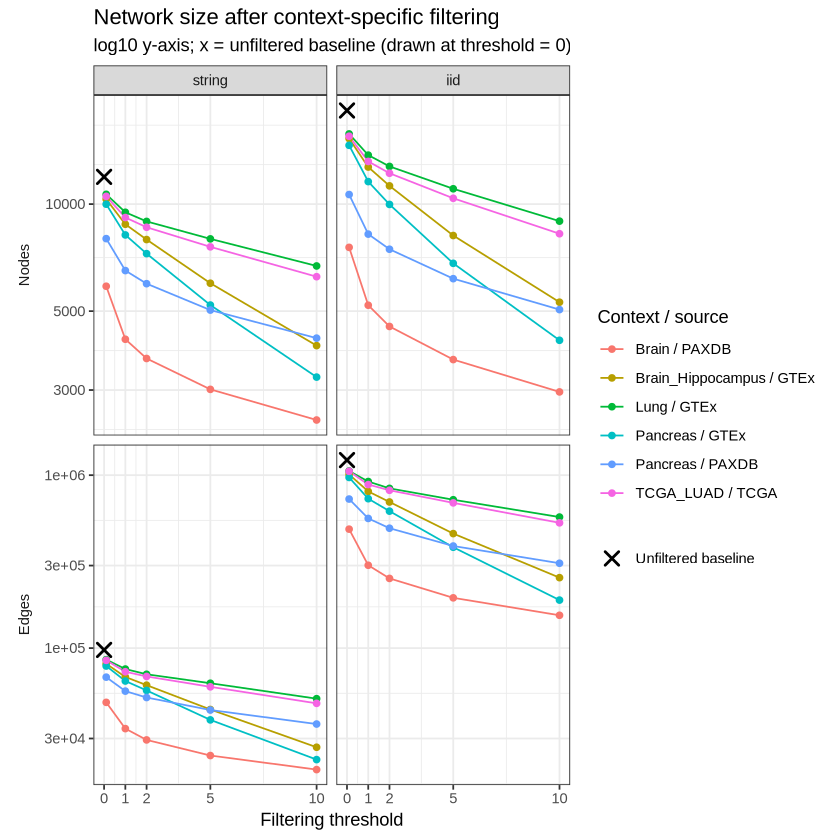

In [ ]:
# Each filtered network against the unfiltered baseline of the *same* base network
# (string/iid), so "rel_x" is always "fraction of the corresponding unfiltered value".
baseline_topology <- network_topology %>%
  filter(!filtered) %>%
  select(network, all_of(names(TOPOLOGY_METRICS))) %>%
  rename_with(~ paste0("baseline_", .x), all_of(names(TOPOLOGY_METRICS)))

network_topology_rel <- network_topology %>%
  filter(filtered) %>%
  left_join(baseline_topology, by = "network")

# plain loop rather than across(..., cur_column()): dplyr expands the across() expressions
# before evaluating them, so cur_column() errors out with "Must only be used inside across()"
for (metric in names(TOPOLOGY_METRICS)) {
  network_topology_rel[[paste0("rel_", metric)]] <-
    network_topology_rel[[metric]] / network_topology_rel[[paste0("baseline_", metric)]]
}

# long form for the facetted figures; prefix picks absolute ("") vs. relative ("rel_") columns
topology_long <- function(df, metrics, prefix = "") {
  cols <- paste0(prefix, names(metrics))
  df %>%
    select(network, context, source, threshold, filter_config, all_of(cols)) %>%
    pivot_longer(all_of(cols), names_to = "metric", values_to = "value") %>%
    mutate(
      metric  = str_remove(metric, paste0("^", prefix)),
      metric  = factor(metric, levels = names(metrics), labels = unname(metrics)),
      network = factor(network, levels = KNOWN_NETWORKS)
    )
}

# The 0.1 tick would sit on top of the baseline tick at 0 on a linear axis, so thresholds
# that close to 0 are left unticked (their points are still drawn).
NETWORK_THRESHOLD_BREAKS <- c(
  0, NETWORK_THRESHOLDS[NETWORK_THRESHOLDS > 0.05 * max(NETWORK_THRESHOLDS)]
)

# Same convention as the module-level figures above: the unfiltered baseline has no
# threshold, so it is drawn as an "x" at threshold = 0 (no real threshold is 0).
# independent_y switches from facet_grid to facet_wrap because facet_grid's
# scales = "free_y" frees the scale per *row*, not per panel -- fine when the two base
# networks are within an order of magnitude of each other (nodes, edges), but it flattens
# the iid panel for metrics where they are not (1 vs. 241 components when unfiltered).
plot_network_topology_absolute <- function(metrics, title, subtitle = NULL, log_y = FALSE,
                                           independent_y = FALSE) {
  d <- topology_long(network_topology %>% filter(filtered), metrics)
  b <- topology_long(network_topology %>% filter(!filtered), metrics) %>%
    mutate(threshold = 0)

  facets <- if (independent_y) {
    facet_wrap(vars(metric, network), scales = "free_y", ncol = length(KNOWN_NETWORKS))
  } else {
    facet_grid(metric ~ network, scales = "free_y", switch = "y")
  }

  p <- ggplot(mapping = aes(x = threshold, y = value)) +
    facets +
    geom_line(data = d, aes(color = filter_config)) +
    geom_point(data = d, aes(color = filter_config)) +
    geom_point(data = b, aes(shape = "Unfiltered baseline"), size = 3, stroke = 1.2) +
    scale_shape_manual(name = NULL, values = c("Unfiltered baseline" = 4)) +
    scale_x_continuous(breaks = NETWORK_THRESHOLD_BREAKS) +
    labs(title = title, subtitle = subtitle, x = "Filtering threshold", y = NULL,
         color = "Context / source") +
    theme_bw() +
    theme(strip.placement = "outside", strip.background.y = element_blank())
  if (log_y) p <- p + scale_y_log10()
  p
}

p_size <- plot_network_topology_absolute(
  TOPOLOGY_METRICS[c("nodes", "edges")],
  title = "Network size after context-specific filtering",
  subtitle = "log10 y-axis; x = unfiltered baseline (drawn at threshold = 0)",
  log_y = TRUE
)
ggsave(file.path(NETWORK_TOPOLOGY_OUTDIR, "network_size.png"),
       plot = p_size, width = 10, height = 6, dpi = 300)
print(p_size)

## Relative change vs. the unfiltered baseline

The absolute counts above are dominated by the difference between the two base networks
(`iid` has ~12x the edges of `string_min900`). Normalising every metric by the unfiltered
value of its *own* base network makes the two comparable and shows how similarly — or not —
the same threshold acts on them.

`mean_degree` (2E/V) and `density` (2E/(V(V-1))) are the interesting rows here: a filter that
merely removed a random fraction *p* of nodes would keep only ~*p²* of the edges and thus
scale the mean degree by ~*p*, while leaving the density roughly unchanged. Anything above
that is evidence that the surviving (co-expressed) proteins preferentially interact with each
other rather than with the removed ones — which is the whole premise of context-specific
filtering. The next figure makes that comparison explicit.

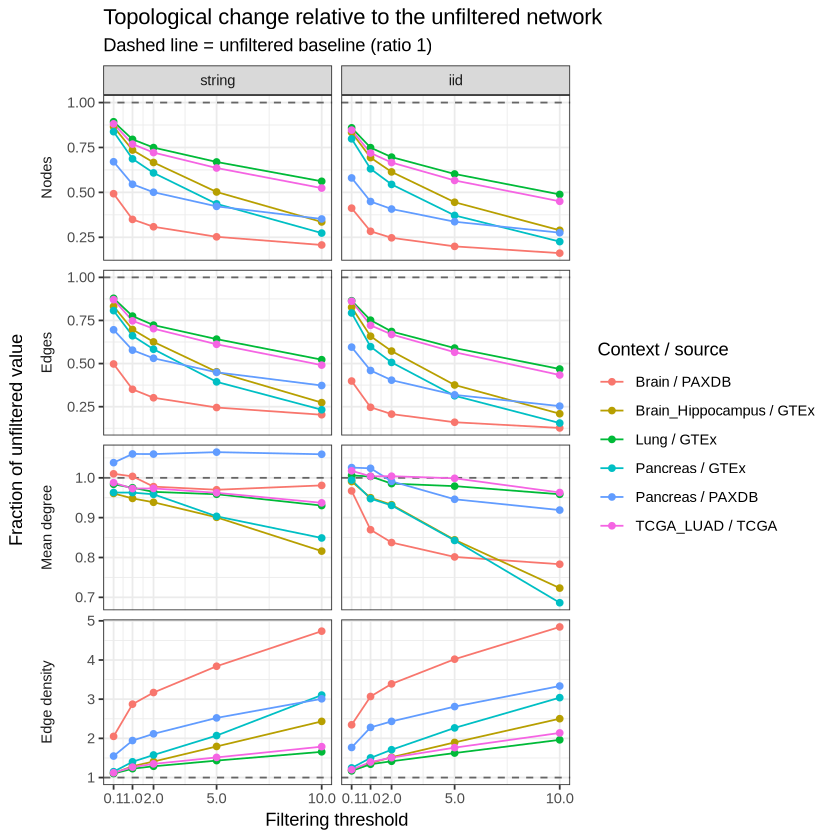

In [ ]:
plot_network_topology_relative <- function(metrics, title, subtitle = NULL) {
  d <- topology_long(network_topology_rel, metrics, prefix = "rel_")

  ggplot(d, aes(x = threshold, y = value, color = filter_config)) +
    facet_grid(metric ~ network, scales = "free_y", switch = "y") +
    geom_hline(yintercept = 1, linetype = "dashed", color = "grey40") +
    geom_line() +
    geom_point() +
    scale_x_continuous(breaks = NETWORK_THRESHOLDS) +
    labs(title = title, subtitle = subtitle, x = "Filtering threshold",
         y = "Fraction of unfiltered value", color = "Context / source") +
    theme_bw() +
    theme(strip.placement = "outside", strip.background.y = element_blank())
}

p_rel <- plot_network_topology_relative(
  TOPOLOGY_METRICS[c("nodes", "edges", "mean_degree", "density")],
  title = "Topological change relative to the unfiltered network",
  subtitle = "Dashed line = unfiltered baseline (ratio 1)"
)
ggsave(file.path(NETWORK_TOPOLOGY_OUTDIR, "relative_change.png"),
       plot = p_rel, width = 10, height = 9, dpi = 300)
print(p_rel)

### Edge retention vs. node retention

Direct test of the "removed proteins are not the interaction partners of the kept ones"
expectation: each point is one (context, source, threshold) network, positioned by the
fraction of nodes it kept (x) and the fraction of edges it kept (y). Points of the same
context/source are connected in order of increasing threshold, so each trajectory runs from
the mildest filter (top right) to the strictest (bottom left).

Two reference curves:

* `y = x` — every removed node was isolated; filtering costs no interactions at all.
* `y = x²` — the removed nodes were a *random* subset, so an edge survives only if both of
  its endpoints do (the null model).

Points between the two curves mean the filter removes nodes that are less connected to the
retained subnetwork than chance would predict, i.e. the retained context-specific part of the
interactome is more self-contained than a random subnetwork of the same size.

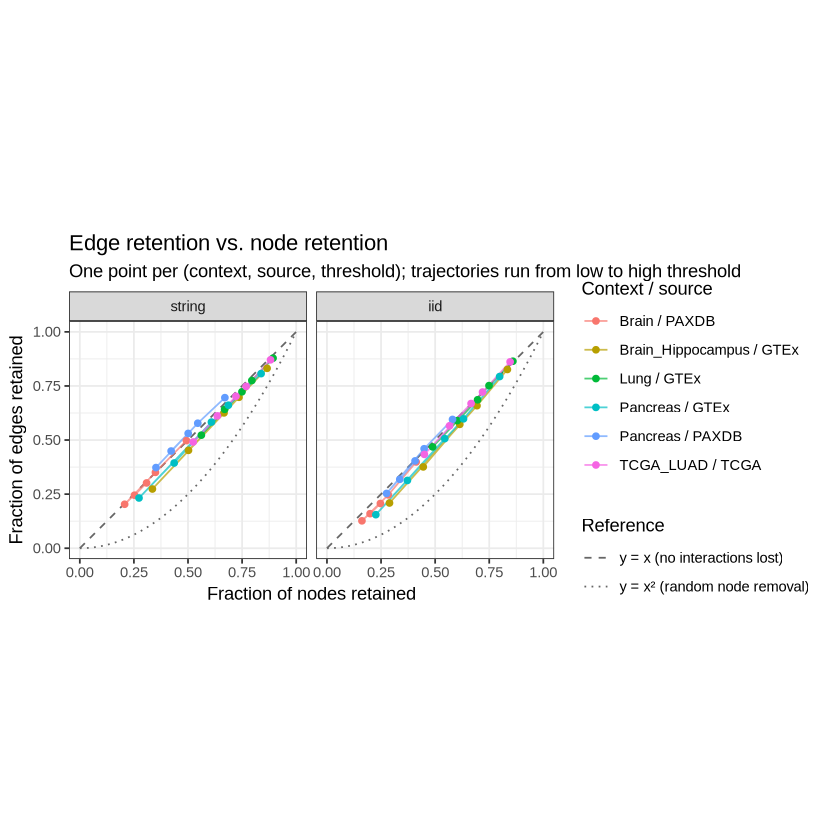

In [ ]:
edge_node_reference <- tibble(rel_nodes = seq(0, 1, by = 0.01)) %>%
  mutate(
    `y = x (no interactions lost)`    = rel_nodes,
    `y = x² (random node removal)` = rel_nodes^2
  ) %>%
  pivot_longer(-rel_nodes, names_to = "reference", values_to = "rel_edges")

p_retention <- ggplot(
    network_topology_rel %>% mutate(network = factor(network, levels = KNOWN_NETWORKS)),
    aes(x = rel_nodes, y = rel_edges)
  ) +
  facet_wrap(~ network, ncol = 2) +
  geom_line(data = edge_node_reference, inherit.aes = FALSE,
            mapping = aes(x = rel_nodes, y = rel_edges, linetype = reference),
            color = "grey40") +
  geom_path(aes(color = filter_config, group = filter_config), alpha = 0.7) +
  geom_point(aes(color = filter_config)) +
  scale_linetype_manual(values = c("dashed", "dotted")) +
  coord_equal(xlim = c(0, 1), ylim = c(0, 1)) +
  labs(
    title = "Edge retention vs. node retention",
    subtitle = "One point per (context, source, threshold); trajectories run from low to high threshold",
    x = "Fraction of nodes retained", y = "Fraction of edges retained",
    color = "Context / source", linetype = "Reference"
  ) +
  theme_bw()

ggsave(file.path(NETWORK_TOPOLOGY_OUTDIR, "edge_vs_node_retention.png"),
       plot = p_retention, width = 10, height = 5.5, dpi = 300)
print(p_retention)

## Fragmentation

Removing nodes also breaks the network apart, which matters directly for module discovery:
seeds that end up in different components can no longer be connected by any AMIM, and a
strongly fragmented network gives the connectivity-based methods much less room to expand.

`components` counts connected components (the unfiltered `iid` network is a single component,
unfiltered `string_min900` already has 241); `lcc_fraction` is the share of the remaining
nodes that still sit in the largest component. Note the different behaviour of the two base
networks: `iid` stays almost entirely connected (LCC fraction > 0.99 throughout) and just
sheds small satellites, while `string_min900` both fragments into more components and loses a
visible share of its nodes to them.

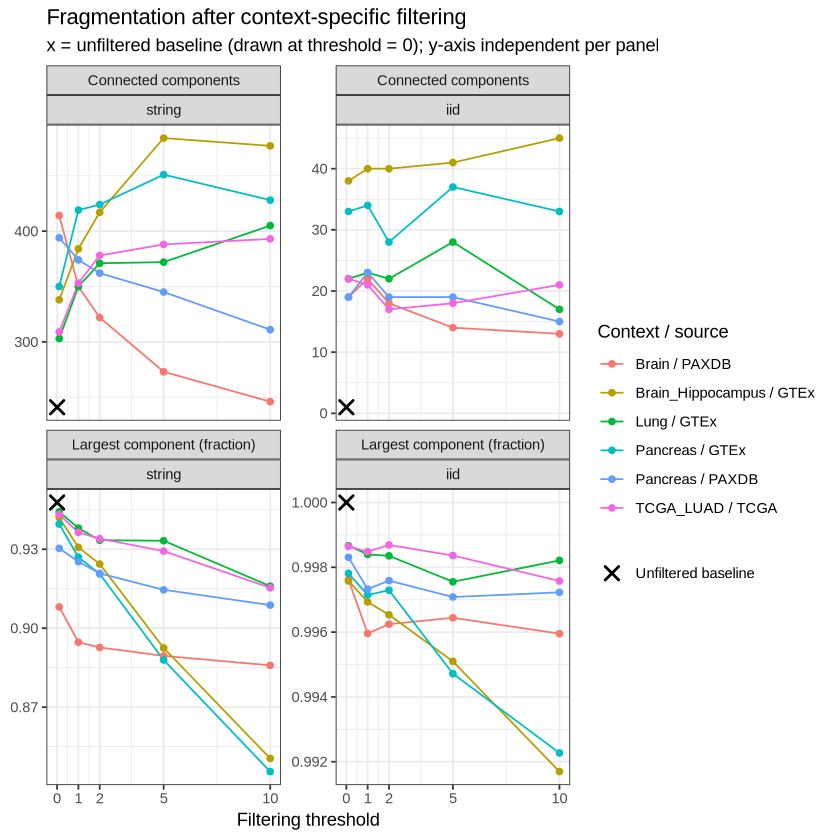

In [ ]:
p_frag <- plot_network_topology_absolute(
  TOPOLOGY_METRICS[c("components", "lcc_fraction")],
  title = "Fragmentation after context-specific filtering",
  subtitle = "x = unfiltered baseline (drawn at threshold = 0); y-axis independent per panel",
  independent_y = TRUE
)
ggsave(file.path(NETWORK_TOPOLOGY_OUTDIR, "fragmentation.png"),
       plot = p_frag, width = 10, height = 6, dpi = 300)
print(p_frag)

## Combined overview (log2 fold change heatmap)

All of the above in one figure, in the same delta-heatmap style used for the robustness and
pathway sections: rows are the topology metrics, columns are the filter configurations
(labelled `context.source.threshold`, ordered by source then threshold), one panel per base
network, and the cell value is `log2(filtered / unfiltered)` — 0 means unchanged, −1 means
halved, +1 means doubled. A log ratio is used rather than a raw difference because the metrics
live on completely different scales (counts in the 10⁶ range next to densities of ~10⁻³); the
signed, zero-centred result still works with the diverging colour scale.

As in the robustness delta heatmaps, the colour scale is capped (`cap = 3`, i.e. 8-fold) and
values beyond it are squished to the end colour rather than dropped. The cap is needed because
of one row: the unfiltered `iid` network is a single connected component, so *any*
fragmentation gives `log2(components / 1)` ≈ 4–5.5 and would flatten every other row to
near-white. The printed cell labels always show the true, uncapped value.

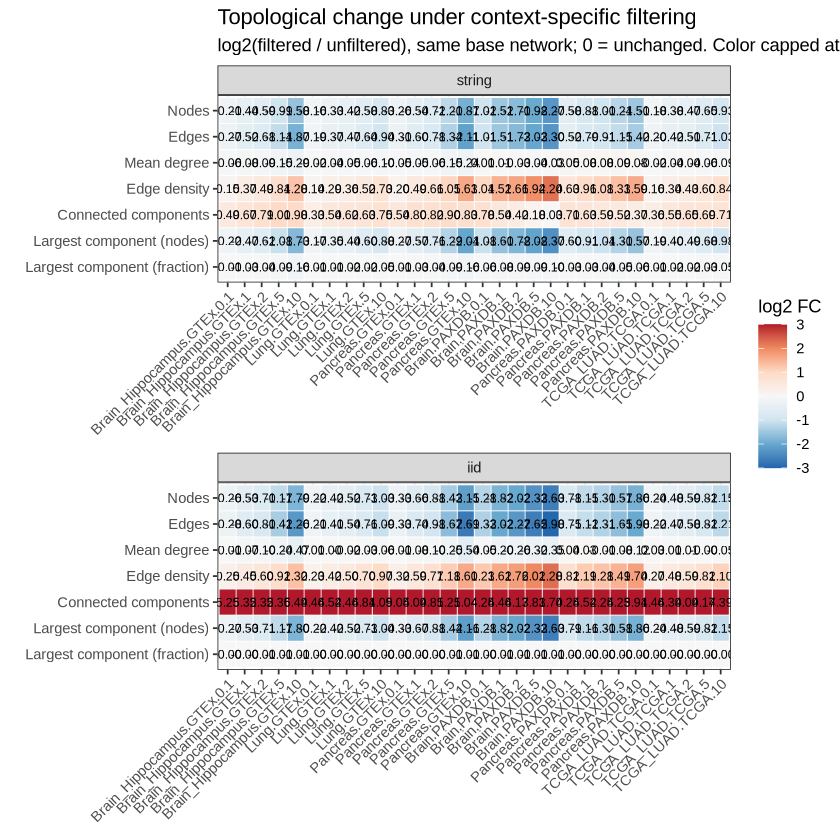

In [ ]:
build_network_topology_log2fc_heatmap <- function(metrics = TOPOLOGY_METRICS, cap = 3) {
  d <- topology_long(network_topology_rel, metrics, prefix = "rel_") %>%
    mutate(
      log2fc = log2(value),
      label  = paste(context, source, threshold, sep = ".")
    )

  x_levels <- d %>%
    distinct(source, context, threshold, label) %>%
    arrange(source, context, threshold) %>%
    pull(label)

  d <- d %>% mutate(label = factor(label, levels = x_levels))

  # Capped shared scale (same idiom as the robustness delta heatmaps): the unfiltered iid
  # network is a single component, so its "Connected components" row is log2(n / 1) ~ 4-5.5
  # and would otherwise stretch the scale until every other row reads as near-white.
  # Values beyond the cap are squished to the end color; the cell labels stay uncapped.
  data_max_abs <- max(abs(d$log2fc), na.rm = TRUE)
  max_abs <- if (is.null(cap)) data_max_abs else min(cap, data_max_abs)

  ggplot(d, aes(x = label, y = fct_rev(metric), fill = log2fc)) +
    facet_wrap(~ network, ncol = 1, scales = "free_x") +
    geom_tile(color = "white") +
    geom_text(aes(label = sprintf("%.2f", log2fc)), size = 2.6) +
    scale_fill_distiller(
      palette = "RdBu", direction = -1,
      limits = c(-max_abs, max_abs), oob = scales::squish
    ) +
    labs(
      title = "Topological change under context-specific filtering",
      subtitle = paste0(
        "log2(filtered / unfiltered), same base network; 0 = unchanged. ",
        "Color capped at +/-", max_abs, ", labels uncapped"
      ),
      x = NULL, y = NULL, fill = "log2 FC"
    ) +
    theme_bw() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

p_heat <- build_network_topology_log2fc_heatmap()
ggsave(file.path(NETWORK_TOPOLOGY_OUTDIR, "log2fc_heatmap.png"),
       plot = p_heat, width = 13, height = 9, dpi = 300)
print(p_heat)

# Seed retention under context-specific filtering

Filtering removes nodes from the network, and some of those nodes are seeds — a seed that is
not in the network can no longer be used by any AMIM (`INPUTCHECK` drops it before module
detection and writes it to `input/seeds/<id>.removed.tsv`). This section quantifies that loss,
which is the direct cost side of the filtering trade-off evaluated everywhere above.

Source is the pipeline's own seed summary table, `mqc_summaries/input_seeds_mqc.tsv` (the
"Input → Seeds" table of the MultiQC report), written by `bin/input_check.py` once per
(seed file × network) and aggregated per run by `collectFile` in
`workflows/diseasemodulediscovery.nf`. Columns: `Seed file` (= `<seeds_id>.<network_id>`),
`Seeds` (seeds found in that network) and `Not in network` (seeds that were not).

The id scheme is a third variant, in between the two already parsed above: it *keeps* the
`seeds_id` (unlike `meta.network_id`) but has *no* `amim` (unlike `meta.id`), because
`INPUTCHECK` runs before network expansion. Rather than a fourth hand-rolled regex, seed-file
ids are matched against the network ids the network-topology section below already parsed
(`match_seeds_network()`) — see that cell for why.

Three reference quantities are computed per filtered network, and it matters which one a
number is relative to:

* **`retention_vs_input`** — `Seeds / (Seeds + Not in network)`, i.e. the fraction of the
  *original seed file* that survives. Its ceiling is the unfiltered network, which already
  loses some seeds simply because they are not in the interactome at all.
* **`retention_vs_baseline`** — `Seeds / Seeds(unfiltered, same base network)`, i.e. the
  fraction lost *attributable to filtering*. This is the number to quote when comparing
  filter configurations.
* **`lost_by_filtering`** — the absolute count behind it, and the gene set used for the
  functional analysis in the next section.

In [ ]:
SEED_RETENTION_OUTDIR <- file.path(REPO_ROOT, "results_analysis_output", "seed_retention")
dir.create(SEED_RETENTION_OUTDIR, recursive = TRUE, showWarnings = FALSE)

# Rather than re-deriving network/context/source/threshold from the seed-file id with a
# second, independent regex (as parse_run_id() / parse_network_id() do above), match each
# seed-file id against the network ids the network-topology section already parsed and
# validated (network_topology$network_id). This also sidesteps a pipeline bug found while
# building this section: NETWORK_FILTERING builds the context-specific seed-file prefix as
# `seeds.baseName + network.baseName + "." + context_key` in
# subworkflows/local/network_filtering/main.nf (fixed upstream, but old runs on disk may
# still have it), which concatenates seeds_id directly onto network.baseName with no "."
# between them -- a regex anchored on "<seeds_id>.<network>" would silently drop every
# filtered seed file. Suffix-matching against a known network id works either way.
KNOWN_NETWORK_IDS <- network_topology %>%
  distinct(network_id, network, context, source, threshold, filtered) %>%
  arrange(desc(nchar(network_id)))

match_seeds_network <- function(ids) {
  map_dfr(ids, function(id) {
    hit <- KNOWN_NETWORK_IDS %>% filter(str_ends(id, fixed(network_id))) %>% slice(1)
    if (nrow(hit) == 0) {
      return(tibble(seeds_file = id, seeds_id = NA_character_, network = NA_character_,
                    network_id = NA_character_, context = NA_character_,
                    source = NA_character_, threshold = NA_real_, filtered = NA))
    }
    tibble(seeds_file = id, seeds_id = str_remove(str_remove(id, fixed(hit$network_id)), "\\.$")) %>%
      bind_cols(hit)
  })
}

read_seeds_summary <- function(run_dir) {
  mqc_file <- file.path(run_dir, "mqc_summaries", "input_seeds_mqc.tsv")
  if (!file.exists(mqc_file)) {
    warning("Missing seed summary: ", mqc_file)
    return(NULL)
  }
  raw <- read_tsv(mqc_file, show_col_types = FALSE)
  parsed <- match_seeds_network(raw$`Seed file`)
  unmatched <- sum(is.na(parsed$network))
  if (unmatched > 0) {
    warning(unmatched, " / ", nrow(parsed), " seed ids in ", mqc_file,
            " did not match any known network id")
  }
  bind_cols(
    parsed %>% select(-seeds_file),
    raw %>% select(seeds_in_network = Seeds, seeds_not_in_network = `Not in network`)
  )
}

seed_retention_runs <- imap(RUNS, function(run_dir, disease) {
  df <- read_seeds_summary(run_dir)
  if (is.null(df)) return(NULL)
  df %>% mutate(disease = disease, .before = 1)
}) %>%
  bind_rows() %>%
  filter(!is.na(network))

# every filtered network is compared to the unfiltered baseline of its own base network
# (string/iid) and its own seed file, so "lost" always means "lost by filtering"
seed_baseline <- seed_retention_runs %>%
  filter(!filtered) %>%
  select(disease, seeds_id, network,
         baseline_in_network     = seeds_in_network,
         baseline_not_in_network = seeds_not_in_network)

seed_retention <- seed_retention_runs %>%
  left_join(seed_baseline, by = c("disease", "seeds_id", "network")) %>%
  mutate(
    total_seeds           = seeds_in_network + seeds_not_in_network,
    lost_by_filtering     = baseline_in_network - seeds_in_network,
    retention_vs_baseline = seeds_in_network / baseline_in_network,
    retention_vs_input    = seeds_in_network / total_seeds,
    filter_config         = if_else(filtered, paste(context, source, sep = " / "), NA_character_)
  )

# the seed file itself never changes within a run, so the total must be constant per disease
inconsistent_totals <- seed_retention %>%
  group_by(disease, seeds_id) %>%
  summarise(n = n_distinct(total_seeds), .groups = "drop") %>%
  filter(n > 1)
if (nrow(inconsistent_totals) > 0) {
  warning("differing seed-file sizes within a run: ",
          paste(inconsistent_totals$disease, collapse = ", "))
}

# shared x-axis order for the bar plots below: "baseline" first, then each source's
# thresholds ascending (same convention as build_x_levels() in the g:Profiler section)
SEED_X_LEVELS <- c(
  "baseline",
  seed_retention %>%
    filter(filtered) %>%
    distinct(source, threshold) %>%
    arrange(source, threshold) %>%
    mutate(label = paste(source, threshold)) %>%
    pull(label)
)

write_tsv(
  seed_retention %>% arrange(disease, network, source, threshold),
  file.path(SEED_RETENTION_OUTDIR, "seed_retention_summary.tsv")
)

seed_retention %>%
  select(disease, network, context, source, threshold, total_seeds, seeds_in_network,
         lost_by_filtering, retention_vs_baseline, retention_vs_input) %>%
  arrange(disease, network, source, threshold) %>%
  print(n = Inf)

## How many seeds survive each filter, GTEx vs. the other source (grouped bar plot)

One panel per (disease, base network) — 8 panels for the 4 diseases × 2 base networks used
here. Within a panel: a single grey **baseline** bar (seeds found in the unfiltered network),
then for each filtering threshold a pair of dodged bars, one per source — GTEx vs. whichever
other source that disease also uses (PAXDB or TCGA) — since every disease here sweeps both
sources over the *same* threshold grid, putting threshold on the x-axis and source as the
dodge lets the two be compared directly at equivalent thresholds. Bar height is seeds kept;
how many were lost is the gap to the grey baseline bar (also in
`seed_retention_summary.tsv` as `lost_by_filtering` for the exact count).

Panels use `scales = "free_x"` because the diseases do not all use the same sources (`PAXDB`
vs. `TCGA`). Output: `results_analysis_output/seed_retention/seed_retention_grouped.png`.

In [ ]:
# same palette/assignment as the module-similarity heatmaps' "Source" annotation bar above
# (source_levels <- c("unfiltered", KNOWN_SOURCES); brewer.pal(..., "Dark2")), so a source
# means the same color everywhere in this notebook. "unfiltered" occupies the first slot
# there but isn't needed here -- the baseline bar is drawn separately, in solid grey.
SEED_SOURCE_LEVELS <- c("unfiltered", KNOWN_SOURCES)
SEED_SOURCE_COLORS <- setNames(
  brewer.pal(max(3, length(SEED_SOURCE_LEVELS)), "Dark2")[seq_along(SEED_SOURCE_LEVELS)],
  SEED_SOURCE_LEVELS
)[KNOWN_SOURCES]
BASELINE_BAR_COLOR <- "grey55"

# threshold-only x-axis (shared across sources) rather than SEED_X_LEVELS (source + threshold,
# used by the enrichment heatmaps further down): the point of this figure is to compare
# sources head-to-head at the *same* threshold, which only works because every disease here
# sweeps GTEx and its other source (PAXDB or TCGA) over an identical threshold grid.
SEED_THRESHOLD_LEVELS <- c(
  "baseline",
  seed_retention %>%
    filter(filtered) %>%
    distinct(threshold) %>%
    arrange(threshold) %>%
    mutate(label = as.character(threshold)) %>%
    pull(label)
)

# facet_wrap rather than facet_grid: facet_grid's scales = "free_x" frees the scale per
# *column* of the grid (i.e. per network), not per panel, so a disease that only uses GTEx
# would still get empty TCGA/PAXDB slots in its row -- the same gotcha noted for free_y in
# the network-topology section above.
seed_retention_thresholds <- seed_retention %>%
  filter(filtered) %>%
  transmute(
    disease, network = factor(network, levels = KNOWN_NETWORKS), source,
    x_label = factor(as.character(threshold), levels = SEED_THRESHOLD_LEVELS),
    seeds   = seeds_in_network
  )

seed_retention_baseline <- seed_retention %>%
  filter(!filtered) %>%
  transmute(disease, network = factor(network, levels = KNOWN_NETWORKS),
            x_label = factor("baseline", levels = SEED_THRESHOLD_LEVELS),
            seeds = seeds_in_network)

p_seed_bars <- ggplot() +
  facet_wrap(vars(disease, network), scales = "free_x", ncol = length(KNOWN_NETWORKS)) +
  geom_col(data = seed_retention_baseline, aes(x = x_label, y = seeds),
           fill = BASELINE_BAR_COLOR, width = 0.6) +
  geom_text(data = seed_retention_baseline, aes(x = x_label, y = seeds, label = seeds),
            vjust = -0.4, size = 2.6, color = "grey20") +
  geom_col(data = seed_retention_thresholds, aes(x = x_label, y = seeds, fill = source),
           position = position_dodge2(width = 0.8, padding = 0.1)) +
  geom_text(data = seed_retention_thresholds, aes(x = x_label, y = seeds, group = source, label = seeds),
            position = position_dodge2(width = 0.8, padding = 0.1), vjust = -0.4, size = 2.3) +
  scale_fill_manual(values = SEED_SOURCE_COLORS, name = NULL) +
  # extra top headroom: the shared y-scale is set by the single tallest bar across every
  # panel, and the default 5% expansion leaves its count label clipped by the facet strip
  scale_y_continuous(expand = expansion(mult = c(0, 0.12))) +
  labs(
    title = "Seed retention after context-specific filtering",
    subtitle = "Grey = baseline (unfiltered); at each threshold, one bar per filtering source = seeds kept",
    x = "Filtering threshold", y = "Seeds"
  ) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "top")

ggsave(file.path(SEED_RETENTION_OUTDIR, "seed_retention_grouped.png"),
       plot = p_seed_bars, width = 12, height = 9, dpi = 300)
print(p_seed_bars)

## Seed retention across thresholds (line plot)

The same numbers as a threshold sweep, in the layout used throughout this notebook: x =
filtering threshold, color = disease, linetype = filtering source, one panel per base network,
and the unfiltered baseline drawn as an "×" at `threshold = 0` (no real threshold is 0).

y is `retention_vs_input` (fraction of the *original* seed file), so the baseline "×" is
informative: the gap between it and 1.0 is the share of seeds that the interactome never
contained, and everything below it is the filtering-attributable loss.
Output: `results_analysis_output/seed_retention/seed_retention_thresholds.png`.

In [ ]:
plot_seed_retention_lines <- function(df, metric = "retention_vs_input", metric_label = NULL) {
  d <- df %>%
    filter(filtered) %>%
    mutate(network = factor(network, levels = KNOWN_NETWORKS))
  b <- df %>%
    filter(!filtered) %>%
    mutate(network = factor(network, levels = KNOWN_NETWORKS), threshold = 0)

  ggplot(mapping = aes(x = threshold, y = .data[[metric]], color = disease)) +
    facet_wrap(~ network, ncol = 2, drop = FALSE) +
    geom_line(data = d, aes(linetype = source)) +
    geom_point(data = d) +
    geom_point(data = b, aes(shape = "Unfiltered baseline"), size = 3, stroke = 1.2) +
    scale_shape_manual(name = NULL, values = c("Unfiltered baseline" = 4)) +
    scale_linetype_manual(values = c(GTEx = "solid", PAXDB = "dashed", TCGA = "dotted")) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
    labs(
      title = "Seed retention vs. filtering threshold",
      subtitle = "x = unfiltered baseline (drawn at threshold = 0)",
      x = "Filtering threshold", y = metric_label, color = "Disease", linetype = "Source"
    ) +
    theme_bw()
}

p_seed_lines <- plot_seed_retention_lines(
  seed_retention, "retention_vs_input", "Seeds retained (of the input seed file)"
)
ggsave(file.path(SEED_RETENTION_OUTDIR, "seed_retention_thresholds.png"),
       plot = p_seed_lines, width = 10, height = 5, dpi = 300)
print(p_seed_lines)

## Are seeds lost faster or slower than the network as a whole?

Seed retention on its own is hard to read — a filter that removes 40 % of the network is
*expected* to remove roughly 40 % of the seeds too. The informative quantity is seed retention
**relative to node retention**: if the seeds of a tissue-specific disease are preferentially
expressed in that tissue, they should survive the filter at a higher rate than an arbitrary
network node, which is exactly the observation Magger et al. (2012,
doi:10.1371/journal.pcbi.1002690) report for disease genes in their tissue-specific networks.

Each point is one (context, source, threshold) configuration, positioned by the fraction of
network nodes it kept (x, `rel_nodes` from the network-topology section above) and the fraction
of *seeds* it kept (y, both relative to the same unfiltered base network). The diagonal is the
null expectation "seeds are removed like any other node"; points above it mean seeds are
preferentially retained.

The accompanying test makes that explicit: a one-sided binomial test per configuration
(`k` = seeds kept, `n` = seeds in the unfiltered network, `p` = node retention rate,
`alternative = "greater"`), Benjamini-Hochberg corrected across all configurations. Note that
this deliberately uses the network's node retention as the null rather than the expression
data's — the question is whether the filter treats seeds differently from the rest of *this*
interactome. Output: `results_analysis_output/seed_retention/seed_vs_node_retention.png` and
`seed_vs_node_retention_tests.tsv`.

In [ ]:
# network_topology_rel (from the network-topology section above) is keyed by the network id
# only, so the join is on the filter configuration -- the same filtered network is shared by
# every disease that uses that context.
seed_vs_node_retention <- seed_retention %>%
  filter(filtered) %>%
  left_join(
    network_topology_rel %>% select(network, context, source, threshold, rel_nodes),
    by = c("network", "context", "source", "threshold")
  )

missing_rel_nodes <- sum(is.na(seed_vs_node_retention$rel_nodes))
if (missing_rel_nodes > 0) {
  warning(missing_rel_nodes, " seed-retention rows had no matching network-topology row")
}

seed_vs_node_retention <- seed_vs_node_retention %>%
  filter(!is.na(rel_nodes), baseline_in_network > 0) %>%
  mutate(
    p_seed_enrichment = pmap_dbl(
      list(seeds_in_network, baseline_in_network, rel_nodes),
      function(k, n, p) binom.test(k, n, p = min(max(p, 1e-12), 1 - 1e-12),
                                   alternative = "greater")$p.value
    ),
    p_adj = p.adjust(p_seed_enrichment, method = "BH"),
    enriched = p_adj < 0.05,
    network = factor(network, levels = KNOWN_NETWORKS)
  )

write_tsv(
  seed_vs_node_retention %>%
    select(disease, network, context, source, threshold, baseline_in_network,
           seeds_in_network, retention_vs_baseline, rel_nodes, p_seed_enrichment, p_adj) %>%
    arrange(disease, network, source, threshold),
  file.path(SEED_RETENTION_OUTDIR, "seed_vs_node_retention_tests.tsv")
)

n_sig <- sum(seed_vs_node_retention$enriched, na.rm = TRUE)
p_seed_vs_nodes <- ggplot(seed_vs_node_retention,
                          aes(x = rel_nodes, y = retention_vs_baseline)) +
  facet_wrap(~ network, ncol = 2, drop = FALSE) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey40") +
  geom_point(aes(color = disease, shape = source, alpha = enriched), size = 2.5) +
  scale_shape_manual(values = c(GTEx = 16, PAXDB = 17, TCGA = 15)) +
  scale_alpha_manual(values = c(`TRUE` = 1, `FALSE` = 0.35),
                     labels = c(`TRUE` = "BH p < 0.05", `FALSE` = "n.s.")) +
  coord_equal(xlim = c(0, 1), ylim = c(0, 1)) +
  labs(
    title = "Seed retention vs. node retention",
    subtitle = sprintf(
      "Dashed line = seeds removed like any other node; above it = seeds preferentially kept (%d/%d configurations, BH p < 0.05)",
      n_sig, nrow(seed_vs_node_retention)
    ),
    x = "Fraction of network nodes kept", y = "Fraction of seeds kept",
    color = "Disease", shape = "Source", alpha = "Binomial test"
  ) +
  theme_bw()

ggsave(file.path(SEED_RETENTION_OUTDIR, "seed_vs_node_retention.png"),
       plot = p_seed_vs_nodes, width = 11, height = 5.5, dpi = 300)
print(p_seed_vs_nodes)

# Functional analysis of the filtered-out genes

Magger et al. (2012, doi:10.1371/journal.pcbi.1002690), who build tissue-specific PPI networks
by the same node-removal principle used here, do not stop at counting the disease genes their
filter discards — they ask *what kind of genes* those are, and find them enriched for
developmental processes (GO "multicellular organism development", "organ development"), i.e.
genes whose disease relevance comes from an embryonic role rather than from adult expression in
the affected tissue. That is a functional explanation for why a lowly-expressed gene can still
be disease-causing, and therefore for a specific failure mode of expression-based filtering.

This section reproduces that analysis for the runs evaluated here, in two scopes:

1. **Filtered-out seeds** (primary, mirrors Magger et al.): the seeds that are present in the
   unfiltered network but removed by the context filter, computed exactly as
   `setdiff(input/seeds/<baseline id>.tsv, input/seeds/<filtered id>.tsv)`. These files are
   written by `INPUTCHECK` from the actual `.gt` networks, so the sets are exact.
2. **All filtered-out network nodes** (optional, `RUN_LOST_NODE_ORA`): the same question asked
   of the whole discarded subnetwork rather than only the disease genes — what biology does the
   filter throw away. Independent of the seeds, so it is keyed by (network, context, source,
   threshold) only.

Enrichment uses **g:Profiler** through `gprofiler2::gost()` — the same tool the pipeline itself
uses for module ORA (`GPROFILER2_GOST`), with the same sources (`GO,WP,REAC,KEGG`), the same
`gSCS` correction and `p < 0.05` threshold, and the **unfiltered network's node set as the
custom background** (the pipeline passes the parsed network as `custom_bg` as well). The
background matters here: against a genome-wide background, any network-derived gene set looks
enriched for "protein binding"-style terms simply because it comes from an interactome.

> **Requirements.** `gprofiler2` must be installed (`install.packages("gprofiler2")`) and the
> machine running the notebook needs network access to `biit.cs.ut.ee/gprofiler` — unlike every
> other section in this notebook, this one queries a web service rather than reading pipeline
> outputs. Results are cached as `.rds` files under
> `results_analysis_output/lost_gene_function/`; delete them (or set `FORCE_GOST_REFRESH`) to
> re-query.

In [ ]:
FUNCTIONAL_OUTDIR <- file.path(REPO_ROOT, "results_analysis_output", "lost_gene_function")
dir.create(FUNCTIONAL_OUTDIR, recursive = TRUE, showWarnings = FALSE)

read_gene_list <- function(path) {
  if (!file.exists(path)) return(character(0))
  x <- trimws(readLines(path, warn = FALSE))
  unique(x[nzchar(x)])
}

# input/seeds/<id>.tsv holds the seeds that were found in that network; <id>.removed.tsv the
# ones that were not (and is only written when non-empty). The kept lists are used here and
# the lost set derived from them, so a missing .removed.tsv cannot silently become "no loss".
list_seed_files <- function(run_dir) {
  base <- file.path(run_dir, "input", "seeds")
  if (!dir.exists(base)) {
    warning("Missing seed directory: ", base)
    return(character(0))
  }
  files <- list.files(base, pattern = "\\.tsv$", full.names = TRUE)
  files[!str_detect(basename(files), "\\.removed\\.tsv$")]
}

seed_file_registry <- imap(RUNS, function(run_dir, disease) {
  files <- list_seed_files(run_dir)
  if (length(files) == 0) return(NULL)
  tibble(disease = disease, file = files,
         id = str_remove(basename(files), "\\.tsv$"))
}) %>% bind_rows()

seed_sets <- bind_cols(
  seed_file_registry,
  match_seeds_network(seed_file_registry$id) %>% select(-seeds_file)
) %>%
  filter(!is.na(network)) %>%
  mutate(genes = map(file, read_gene_list))

baseline_seed_sets <- seed_sets %>%
  filter(!filtered) %>%
  select(disease, seeds_id, network, baseline_genes = genes)

lost_seeds <- seed_sets %>%
  filter(filtered) %>%
  left_join(baseline_seed_sets, by = c("disease", "seeds_id", "network")) %>%
  mutate(
    lost   = map2(baseline_genes, genes, setdiff),
    n_kept = lengths(genes),
    n_lost = lengths(lost)
  )

# cross-check against the MultiQC counts: the two are read from different outputs of the same
# process, so a mismatch means the id parsing or the file listing is off
count_check <- lost_seeds %>%
  select(disease, network, context, source, threshold, n_kept, n_lost) %>%
  inner_join(
    seed_retention %>% select(disease, network, context, source, threshold,
                              seeds_in_network, lost_by_filtering),
    by = c("disease", "network", "context", "source", "threshold")
  ) %>%
  filter(n_kept != seeds_in_network | n_lost != lost_by_filtering)
if (nrow(count_check) > 0) {
  warning(nrow(count_check), " configurations disagree with input_seeds_mqc.tsv")
  print(count_check)
}

lost_seeds %>%
  select(disease, network, context, source, threshold, n_kept, n_lost) %>%
  arrange(disease, network, source, threshold) %>%
  print(n = Inf)

In [ ]:
FORCE_GOST_REFRESH <- FALSE

if (!requireNamespace("gprofiler2", quietly = TRUE)) {
  stop("gprofiler2 is required for this section: install.packages(\"gprofiler2\")")
}

# Same settings as the pipeline's own ORA (conf/modules.config: --sources "GO,WP,REAC,KEGG",
# gprofiler2_gost.R defaults: gSCS correction, p < 0.05, significant terms only).
GOST_SOURCES <- c("GO", "WP", "REAC", "KEGG")

# Node sets of the input networks, read from the edge lists the pipeline publishes for the
# AMIMs under input/networks/ (the .gt files it also publishes are not readable from R).
# Caveat: an edge list cannot represent isolated nodes, and filtering can isolate a node whose
# partners were all removed -- such nodes are counted as "lost" here although they are still
# in the .gt. The check below reports the size of that effect against input_network_mqc.tsv.
NETWORK_EDGE_SUFFIXES <- c(".diamond.csv", ".rwr.csv", ".robust.tsv")
NETWORK_NODES_CACHE <- file.path(FUNCTIONAL_OUTDIR, "network_node_sets.rds")
network_node_sets <- if (file.exists(NETWORK_NODES_CACHE)) readRDS(NETWORK_NODES_CACHE) else list()

find_network_edge_file <- function(network_id) {
  for (run_dir in RUNS) {
    for (suffix in NETWORK_EDGE_SUFFIXES) {
      f <- file.path(run_dir, "input", "networks", paste0(network_id, suffix))
      if (file.exists(f)) return(f)
    }
  }
  NA_character_
}

read_network_node_set <- function(network_id) {
  f <- find_network_edge_file(network_id)
  if (is.na(f)) {
    warning("No published edge list found for network ", network_id)
    return(character(0))
  }
  edges <- data.table::fread(
    f, header = FALSE, sep = if (str_detect(f, "\\.csv$")) "," else "\t",
    select = 1:2, colClasses = "character", showProgress = FALSE
  )
  unique(c(edges[[1]], edges[[2]]))
}

get_network_nodes <- function(network_id) {
  if (is.null(network_node_sets[[network_id]])) {
    network_node_sets[[network_id]] <<- read_network_node_set(network_id)
    saveRDS(network_node_sets, NETWORK_NODES_CACHE)
  }
  network_node_sets[[network_id]]
}

baseline_network_ids <- network_topology %>%
  filter(!filtered) %>%
  select(network, network_id) %>%
  deframe()

# how many nodes the edge-list reconstruction misses (isolated nodes, see comment above)
baseline_node_check <- tibble(network = names(baseline_network_ids)) %>%
  mutate(
    network_id       = unname(baseline_network_ids[network]),
    nodes_edge_list  = map_int(network_id, ~ length(get_network_nodes(.x))),
    nodes_multiqc    = map_dbl(network_id, function(id)
      network_topology$nodes[match(id, network_topology$network_id)]),
    isolated         = nodes_multiqc - nodes_edge_list
  )
print(baseline_node_check)

run_gost_queries <- function(queries, background) {
  queries <- queries[lengths(queries) > 0]
  if (length(queries) == 0) return(NULL)
  res <- gprofiler2::gost(
    query               = queries,
    organism            = "hsapiens",
    significant         = TRUE,
    correction_method   = "gSCS",
    user_threshold      = 0.05,
    sources             = GOST_SOURCES,
    custom_bg           = background,
    domain_scope        = "custom",
    evcodes             = FALSE
  )
  if (is.null(res)) return(NULL)
  # "source" would collide with the filtering source (GTEx/PAXDB/TCGA) everywhere else in
  # this notebook, so the g:Profiler one is renamed on the way in
  as_tibble(res$result) %>%
    select(query, term_source = source, term_id, term_name, p_value,
           term_size, query_size, intersection_size, precision, recall)
}

LOST_SEED_GOST_CACHE <- file.path(FUNCTIONAL_OUTDIR, "gost_lost_seeds.rds")

# typed 0-row template: g:Profiler legitimately returns nothing for a configuration that
# loses only a handful of seeds, and the plots below still need their columns to exist
EMPTY_ENRICHMENT <- tibble(
  network = character(), query = character(), term_source = character(),
  term_id = character(), term_name = character(), p_value = numeric(),
  term_size = numeric(), query_size = numeric(), intersection_size = numeric(),
  precision = numeric(), recall = numeric(), context = character(),
  source = character(), threshold = numeric(), n_lost = numeric()
)

compute_lost_seed_enrichment <- function() {
  out <- list()
  for (dis in names(RUNS)) {
    for (net in KNOWN_NETWORKS) {
      d <- lost_seeds %>% filter(disease == dis, network == net, n_lost > 0)
      if (nrow(d) == 0) next
      labels <- paste(d$source, d$threshold)
      if (any(duplicated(labels))) {
        # would silently merge two configurations into one g:Profiler query
        labels <- paste(d$context, d$source, d$threshold)
      }
      queries <- set_names(d$lost, labels)
      background <- get_network_nodes(baseline_network_ids[[net]])
      res <- tryCatch(
        run_gost_queries(queries, background),
        error = function(e) {
          warning("g:Profiler failed for ", dis, " / ", net, ": ", conditionMessage(e))
          NULL
        }
      )
      if (is.null(res) || nrow(res) == 0) next
      qmap <- d %>% transmute(query = labels, context, source, threshold, n_lost)
      out[[paste(dis, net)]] <- res %>%
        left_join(qmap, by = "query") %>%
        mutate(disease = dis, network = net, .before = 1)
    }
  }
  if (length(out) == 0) EMPTY_ENRICHMENT %>% mutate(disease = character(), .before = 1)
  else bind_rows(out)
}

lost_seed_enrichment <- if (file.exists(LOST_SEED_GOST_CACHE) && !FORCE_GOST_REFRESH) {
  readRDS(LOST_SEED_GOST_CACHE)
} else {
  res <- compute_lost_seed_enrichment()
  saveRDS(res, LOST_SEED_GOST_CACHE)
  res
}

write_tsv(lost_seed_enrichment, file.path(FUNCTIONAL_OUTDIR, "lost_seed_enrichment.tsv"))

if (nrow(lost_seed_enrichment) == 0) {
  message("g:Profiler returned no significant terms for any filtered-out seed set")
} else {
  lost_seed_enrichment %>%
    count(disease, network, query, name = "significant_terms") %>%
    arrange(disease, network, query) %>%
    print(n = Inf)
}

## Enriched terms of the filtered-out seeds

One heatmap per disease: rows = the `TOP_N_LOST_TERMS` terms with the strongest enrichment
anywhere in that disease (ranked by their best p-value across configurations), columns = filter
configuration, fill = `-log10(p)`, panels = base network. Empty cells mean the term was not
significant for that configuration's lost-seed set (including configurations that lose too few
seeds for anything to reach significance at all).

Read this the way Magger et al. read their Table: recurring developmental / morphogenesis terms
mean the filter is discarding seeds whose disease relevance is embryonic rather than
adult-tissue expression — a systematic, explainable blind spot. Terms that instead look like
the disease's own biology are the more worrying case, since those are seeds the filter should
have kept. Output: `results_analysis_output/lost_gene_function/lost_seeds/<disease>.png`.

In [ ]:
LOST_SEED_PLOT_DIR <- file.path(FUNCTIONAL_OUTDIR, "lost_seeds")
dir.create(LOST_SEED_PLOT_DIR, recursive = TRUE, showWarnings = FALSE)

TOP_N_LOST_TERMS <- 20

plot_lost_seed_enrichment <- function(df, disease, top_n = TOP_N_LOST_TERMS) {
  d <- df %>% filter(disease == !!disease)
  if (nrow(d) == 0) return(NULL)

  top_terms <- d %>%
    group_by(term_id) %>%
    summarise(best_p = min(p_value), .groups = "drop") %>%
    slice_min(best_p, n = top_n, with_ties = FALSE)

  d <- d %>%
    semi_join(top_terms, by = "term_id") %>%
    mutate(
      network    = factor(network, levels = KNOWN_NETWORKS),
      x_label    = factor(paste(source, threshold),
                          levels = intersect(SEED_X_LEVELS, paste(source, threshold))),
      term_label = str_trunc(paste0(term_name, " [", term_source, "]"), 55),
      score      = -log10(p_value)
    )

  ggplot(d, aes(x = x_label, y = fct_reorder(term_label, score, .fun = max), fill = score)) +
    facet_wrap(~ network, ncol = 2, scales = "free_x", drop = FALSE) +
    geom_tile(color = "white") +
    scale_fill_distiller(palette = "YlOrRd", direction = 1) +
    labs(
      title = paste0("Enrichment of the filtered-out seeds — ", disease),
      subtitle = paste0(
        "Top ", top_n, " terms by best p-value; background = unfiltered network nodes. ",
        "Blank = not significant for that configuration"
      ),
      x = "Source / threshold", y = NULL, fill = "-log10(p)"
    ) +
    theme_bw() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1),
          axis.text.y = element_text(size = 7))
}

for (dis in if (nrow(lost_seed_enrichment) == 0) character(0) else names(RUNS)) {
  p <- plot_lost_seed_enrichment(lost_seed_enrichment, dis)
  if (is.null(p)) {
    warning("No enriched terms for the filtered-out seeds of ", dis)
    next
  }
  ggsave(file.path(LOST_SEED_PLOT_DIR, paste0(dis, ".png")),
         plot = p, width = 11, height = 6.5, dpi = 300)
  print(p)
}

## What fraction of the filtered-out seeds each term accounts for

The heatmaps rank terms by significance; Magger et al. instead report *coverage* — "44 of the
76 lowly-expressed disease genes (58 %) are involved in multicellular development". This figure
is that statement, per disease: for the configuration that loses the most seeds (the one with
the most power, named in each panel strip), the top terms by p-value are shown as bars whose
length is `precision` = `intersection_size / query_size`, i.e. the share of the lost seeds
carrying that annotation, with the raw counts as bar labels.

Output: `results_analysis_output/lost_gene_function/lost_seed_composition.png`.

In [ ]:
TOP_N_COMPOSITION_TERMS <- 12

# one configuration per disease: the one that loses the most seeds (ties broken by the
# stricter threshold), since coverage percentages on a handful of genes are meaningless
composition_configs <- lost_seeds %>%
  semi_join(lost_seed_enrichment %>% distinct(disease, network, context, source, threshold),
            by = c("disease", "network", "context", "source", "threshold")) %>%
  group_by(disease) %>%
  arrange(desc(n_lost), desc(threshold), .by_group = TRUE) %>%
  slice(1) %>%
  ungroup() %>%
  select(disease, network, context, source, threshold, n_lost)

lost_seed_composition <- lost_seed_enrichment %>%
  inner_join(composition_configs,
             by = c("disease", "network", "context", "source", "threshold", "n_lost")) %>%
  group_by(disease) %>%
  slice_min(p_value, n = TOP_N_COMPOSITION_TERMS, with_ties = FALSE) %>%
  ungroup() %>%
  mutate(
    panel_label = sprintf("%s — %s, %s %s (%d seeds lost)",
                          disease, network, source, threshold, n_lost),
    term_label  = str_trunc(paste0(term_name, " [", term_source, "]"), 50)
  )

if (nrow(lost_seed_composition) == 0) {
  message("No enriched terms to plot for the filtered-out seeds -- skipping composition figure")
} else {

p_composition <- ggplot(
    lost_seed_composition,
    aes(x = precision, y = fct_reorder(term_label, precision), fill = -log10(p_value))
  ) +
  facet_wrap(~ panel_label, scales = "free_y", ncol = 2) +
  geom_col(width = 0.7) +
  geom_text(aes(label = sprintf("%d/%d", intersection_size, query_size)),
            hjust = -0.15, size = 2.5, color = "grey20") +
  scale_fill_distiller(palette = "YlOrRd", direction = 1) +
  scale_x_continuous(labels = scales::percent_format(accuracy = 1),
                     expand = expansion(mult = c(0, 0.22))) +
  labs(
    title = "Composition of the filtered-out seeds",
    subtitle = paste0(
      "Top ", TOP_N_COMPOSITION_TERMS,
      " terms by p-value for the configuration losing the most seeds; ",
      "bar = share of the lost seeds annotated with the term"
    ),
    x = "Share of filtered-out seeds", y = NULL, fill = "-log10(p)"
  ) +
  theme_bw() +
  theme(axis.text.y = element_text(size = 7))

ggsave(file.path(FUNCTIONAL_OUTDIR, "lost_seed_composition.png"),
       plot = p_composition, width = 13, height = 8, dpi = 300)
print(p_composition)
}

## Optional: the whole filtered-out subnetwork, not only the seeds

Same enrichment, asked of *every* node the filter removes rather than only the disease genes —
"what biology does this filter discard from the interactome". This is seed-independent, so it
is keyed by (network, context, source, threshold) only and each network is queried once with
all of its configurations.

Two caveats specific to this scope, both consequences of the node sets being reconstructed
from the published edge lists (see the `network_node_sets` comment above): nodes that filtering
leaves isolated are counted as removed although they remain in the `.gt`, and the query sets
here are thousands of genes, so terms reach significance easily — compare configurations to
each other rather than reading absolute p-values.

Set `RUN_LOST_NODE_ORA <- FALSE` to skip; reading the edge lists of every filtered network is
the slowest step in this notebook (the `iid` ones are ~10⁶ edges each), which is why the node
sets are cached in `network_node_sets.rds`.
Output: `results_analysis_output/lost_gene_function/lost_nodes/<network>.png`.

In [ ]:
RUN_LOST_NODE_ORA <- TRUE
LOST_NODE_GOST_CACHE <- file.path(FUNCTIONAL_OUTDIR, "gost_lost_nodes.rds")

compute_lost_node_enrichment <- function() {
  out <- list()
  for (net in KNOWN_NETWORKS) {
    configs <- network_topology %>% filter(filtered, network == net)
    if (nrow(configs) == 0) next
    background <- get_network_nodes(baseline_network_ids[[net]])
    lost_sets <- map(configs$network_id, ~ setdiff(background, get_network_nodes(.x)))
    labels <- paste(configs$source, configs$threshold)
    if (any(duplicated(labels))) labels <- paste(configs$context, configs$source, configs$threshold)
    queries <- set_names(lost_sets, labels)
    res <- tryCatch(
      run_gost_queries(queries, background),
      error = function(e) {
        warning("g:Profiler failed for ", net, ": ", conditionMessage(e))
        NULL
      }
    )
    if (is.null(res) || nrow(res) == 0) next
    qmap <- configs %>%
      transmute(query = labels, context, source, threshold, n_lost = lengths(lost_sets))
    out[[net]] <- res %>%
      left_join(qmap, by = "query") %>%
      mutate(network = net, .before = 1)
  }
  if (length(out) == 0) EMPTY_ENRICHMENT else bind_rows(out)
}

lost_node_enrichment <- if (!RUN_LOST_NODE_ORA) {
  NULL
} else if (file.exists(LOST_NODE_GOST_CACHE) && !FORCE_GOST_REFRESH) {
  readRDS(LOST_NODE_GOST_CACHE)
} else {
  res <- compute_lost_node_enrichment()
  saveRDS(res, LOST_NODE_GOST_CACHE)
  res
}

if (!is.null(lost_node_enrichment) && nrow(lost_node_enrichment) > 0) {
  write_tsv(lost_node_enrichment, file.path(FUNCTIONAL_OUTDIR, "lost_node_enrichment.tsv"))

  LOST_NODE_PLOT_DIR <- file.path(FUNCTIONAL_OUTDIR, "lost_nodes")
  dir.create(LOST_NODE_PLOT_DIR, recursive = TRUE, showWarnings = FALSE)

  plot_lost_node_enrichment <- function(df, net, top_n = TOP_N_LOST_TERMS) {
    d <- df %>% filter(network == net)
    if (nrow(d) == 0) return(NULL)
    top_terms <- d %>%
      group_by(term_id) %>%
      summarise(best_p = min(p_value), .groups = "drop") %>%
      slice_min(best_p, n = top_n, with_ties = FALSE)
    d <- d %>%
      semi_join(top_terms, by = "term_id") %>%
      mutate(
        x_label    = factor(paste(source, threshold),
                            levels = intersect(SEED_X_LEVELS, paste(source, threshold))),
        term_label = str_trunc(paste0(term_name, " [", term_source, "]"), 55),
        score      = -log10(p_value)
      )
    ggplot(d, aes(x = x_label, y = fct_reorder(term_label, score, .fun = max), fill = score)) +
      geom_tile(color = "white") +
      scale_fill_distiller(palette = "YlGnBu", direction = 1) +
      labs(
        title = paste0("Enrichment of all filtered-out nodes — ", net),
        subtitle = paste0("Top ", top_n,
                          " terms by best p-value; background = unfiltered network nodes"),
        x = "Source / threshold", y = NULL, fill = "-log10(p)"
      ) +
      theme_bw() +
      theme(axis.text.x = element_text(angle = 45, hjust = 1),
            axis.text.y = element_text(size = 7))
  }

  for (net in KNOWN_NETWORKS) {
    p <- plot_lost_node_enrichment(lost_node_enrichment, net)
    if (is.null(p)) next
    ggsave(file.path(LOST_NODE_PLOT_DIR, paste0(net, ".png")),
           plot = p, width = 10, height = 6.5, dpi = 300)
    print(p)
  }
}

## Disease-specific pathway significance — baseline vs. filtered (bar plot)

Bar-plot alternative to the combined delta heatmap above: instead of `filtered − baseline`,
this shows the raw `-log10(p)` for baseline and every filtered threshold side by side, so the
absolute significance level (not just its change) is visible. Restricted to each disease's
**direct-naming pathway only** (e.g. KEGG "Alzheimer disease" for the alzheimer's run) —
`DISEASE_PATHWAYS`' second, broader entry for alzheimers ("Pathways of neurodegeneration -
multiple diseases") is dropped here, since it names a class of diseases rather than the
disease under study and would otherwise sit in the same row/color as the on-target pathway.

Same facet layout as the delta heatmap: rows = network, columns = source (`GTEx` /
`PAXDB/LUAD`, `PAXDB` and `TCGA` merged since they never share a disease), `scales = "free_x"`
so each source keeps its own tested thresholds. Within a facet, bars are dodged by disease
(one direct pathway per disease, so disease and pathway are equivalent here) and colored with
the same `MODULE_SIZE_DISEASE_COLORS` used for disease color everywhere else in this notebook.
One figure per AMIM, then a combined figure merging all six with a shared legend (same
`patchwork` idiom as the delta heatmap's `build_combined_gprofiler_pathway_delta_heatmap`).
Output: `results_analysis_output/gprofiler/disease_pathways/score_barplots_baseline/<node_scope>/<amim>.png`
and `.../combined.png`.

In [ ]:
# each disease's direct-naming pathway only -- drops DISEASE_PATHWAYS' broader/tangential
# second entries (currently just alzheimers' "Pathways of neurodegeneration - multiple
# diseases"); scoped to this bar plot rather than changing DISEASE_PATHWAYS itself, since the
# delta heatmap above is still meant to track both.
DIRECT_DISEASE_PATHWAYS <- list(
  alzheimers      = c("KEGG:05010" = "Alzheimer disease"),
  diabetes_typeI  = c("KEGG:04940" = "Type I diabetes mellitus"),
  diabetes_typeII = c("KEGG:04930" = "Type II diabetes mellitus"),
  LUAD            = c("KEGG:05223" = "Non-small cell lung cancer")
)
DIRECT_PATHWAY_IDS <- map_chr(DIRECT_DISEASE_PATHWAYS, names)

disease_pathway_scores_direct <- disease_pathway_scores %>%
  filter(pathway_id == DIRECT_PATHWAY_IDS[disease])

GPROFILER_PATHWAY_BARPLOT_OUTDIR <- file.path(DISEASE_PATHWAYS_OUTDIR, "score_barplots_baseline")

# PAXDB and TCGA never share a disease (PAXDB = alzheimers/diabetes, TCGA = LUAD), same
# non-overlap the delta heatmap's recode_source() relies on, so they're merged into one
# facet column labeled by whichever source actually produced each disease's data
recode_pathway_source <- function(s) if_else(s %in% c("PAXDB", "TCGA"), "PAXDB/LUAD", s)

plot_gprofiler_pathway_score_barplot <- function(df, node_scope, amim, title = NULL) {
  d <- df %>% filter(node_scope == !!node_scope, amim == !!amim)
  if (nrow(d) == 0) return(NULL)

  threshold_levels <- d %>%
    filter(filtered) %>%
    distinct(threshold) %>%
    arrange(threshold) %>%
    transmute(label = as.character(threshold)) %>%
    pull(label)

  d <- d %>%
    mutate(
      network = factor(network, levels = KNOWN_NETWORKS),
      source_facet = factor(if_else(filtered, recode_pathway_source(source), "baseline"),
                            levels = c("baseline", "GTEx", "PAXDB/LUAD")),
      threshold_label = factor(if_else(filtered, as.character(threshold), "baseline"),
                                levels = c("baseline", threshold_levels))
    )

  ggplot(d, aes(x = threshold_label, y = score, fill = disease)) +
    geom_col(position = position_dodge2(width = 0.8, padding = 0.1)) +
    facet_grid(
      network ~ source_facet, scales = "free_x", space = "free_x",
      labeller = labeller(source_facet = function(x) ifelse(x == "baseline", "", x))
    ) +
    scale_fill_manual(values = MODULE_SIZE_DISEASE_COLORS, labels = DISEASE_LABELS, name = "Disease") +
    labs(
      title = if (is.null(title)) paste0(AMIM_LABELS[[amim]], " -- pathway significance vs. baseline (", node_scope, ")") else title,
      x = "Filtering threshold", y = "-log10(p)"
    ) +
    theme_bw() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

for (node_scope in c("whole_module", "added_nodes_only")) {
  node_scope_outdir <- file.path(GPROFILER_PATHWAY_BARPLOT_OUTDIR, node_scope)
  dir.create(node_scope_outdir, recursive = TRUE, showWarnings = FALSE)

  for (amim in KNOWN_AMIMS) {
    p <- plot_gprofiler_pathway_score_barplot(disease_pathway_scores_direct, node_scope, amim)
    if (is.null(p)) {
      warning("No pathway score barplot data for node_scope=", node_scope, " amim=", amim)
      next
    }
    ggsave(
      filename = file.path(node_scope_outdir, paste0(amim, ".png")),
      plot = p, width = 9, height = 4.5, dpi = 300
    )
  }
}

### Combined figure (all AMIMs, one legend)

Merges the per-AMIM panels above into a single figure per node scope, same idiom as the
delta heatmap's combined figure: one subfigure per AMIM (titled with just the method name)
arranged with `patchwork::wrap_plots`, and a single shared disease legend
(`plot_layout(guides = "collect")`) -- no shared limit computation needed here, unlike the
delta heatmap's `max_abs`, since the legend is categorical (disease color) rather than a
continuous fill scale. Output:
`results_analysis_output/gprofiler/disease_pathways/score_barplots_baseline/<node_scope>/combined.png`.

In [ ]:
build_combined_gprofiler_pathway_score_barplot <- function(node_scope, amims = KNOWN_AMIMS) {
  plots <- Filter(Negate(is.null), lapply(amims, function(amim) {
    plot_gprofiler_pathway_score_barplot(
      disease_pathway_scores_direct, node_scope, amim, title = AMIM_LABELS[[amim]]
    )
  }))
  if (length(plots) == 0) return(NULL)

  patchwork::wrap_plots(plots, ncol = 3) +
    patchwork::plot_layout(guides = "collect") +
    patchwork::plot_annotation(title = paste0("Pathway significance vs. unfiltered baseline (", node_scope, ")"))
}

for (node_scope in c("whole_module", "added_nodes_only")) {
  node_scope_outdir <- file.path(GPROFILER_PATHWAY_BARPLOT_OUTDIR, node_scope)
  dir.create(node_scope_outdir, recursive = TRUE, showWarnings = FALSE)

  p <- build_combined_gprofiler_pathway_score_barplot(node_scope)
  if (is.null(p)) {
    warning("No combined pathway score barplot for node_scope=", node_scope)
    next
  }
  ggsave(
    filename = file.path(node_scope_outdir, "combined.png"),
    plot = p, width = 20, height = 8, dpi = 300
  )
}

### Pathway significance vs. baseline — line plot version

Same panel layout as the bar plots above (network rows × GTEx/PAXDB-LUAD columns, colour = disease) using `disease_pathway_scores_direct`, drawn as lines across thresholds instead of bars. The unfiltered baseline has no source of its own, so its score is replicated as the leftmost "baseline" point on both source columns, giving each line an unfiltered starting point instead of a separate baseline panel.

In [ ]:
plot_gprofiler_pathway_score_lineplot <- function(df, node_scope, amim, title = NULL) {
  d <- df %>% filter(node_scope == !!node_scope, amim == !!amim)
  if (nrow(d) == 0) return(NULL)

  d_filtered <- d %>%
    filter(filtered) %>%
    mutate(source_facet = recode_pathway_source(source))
  if (nrow(d_filtered) == 0) return(NULL)

  threshold_levels <- d_filtered %>%
    distinct(threshold) %>%
    arrange(threshold) %>%
    transmute(label = as.character(threshold)) %>%
    pull(label)

  # unfiltered baseline has no source of its own; replicate its score onto the
  # leftmost "baseline" position of every source column that exists for that
  # disease/network, so each line starts from the same unfiltered reference
  # point instead of living in a separate baseline-only panel
  baseline_expanded <- d_filtered %>%
    distinct(network, disease, source_facet) %>%
    inner_join(
      d %>% filter(!filtered) %>% select(network, disease, score),
      by = c("network", "disease")
    ) %>%
    mutate(threshold_label = "baseline")

  d_plot <- bind_rows(
    d_filtered %>% mutate(threshold_label = as.character(threshold)),
    baseline_expanded
  ) %>%
    mutate(
      network = factor(network, levels = KNOWN_NETWORKS),
      source_facet = factor(source_facet, levels = c("GTEx", "PAXDB/LUAD")),
      threshold_label = factor(threshold_label, levels = c("baseline", threshold_levels))
    )

  ggplot(d_plot, aes(x = threshold_label, y = score, color = disease, group = disease)) +
    geom_line() +
    geom_point() +
    facet_grid(network ~ source_facet) +
    scale_color_manual(values = MODULE_SIZE_DISEASE_COLORS, labels = DISEASE_LABELS, name = "Disease") +
    labs(
      title = if (is.null(title)) paste0(AMIM_LABELS[[amim]], " -- pathway significance vs. baseline (", node_scope, ")") else title,
      x = "Filtering threshold", y = "-log10(p)"
    ) +
    theme_bw() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

GPROFILER_PATHWAY_LINEPLOT_OUTDIR <- file.path(DISEASE_PATHWAYS_OUTDIR, "score_lineplots_baseline")

for (node_scope in c("whole_module", "added_nodes_only")) {
  node_scope_outdir <- file.path(GPROFILER_PATHWAY_LINEPLOT_OUTDIR, node_scope)
  dir.create(node_scope_outdir, recursive = TRUE, showWarnings = FALSE)

  for (amim in KNOWN_AMIMS) {
    p <- plot_gprofiler_pathway_score_lineplot(disease_pathway_scores_direct, node_scope, amim)
    if (is.null(p)) {
      warning("No pathway score lineplot data for node_scope=", node_scope, " amim=", amim)
      next
    }
    ggsave(
      filename = file.path(node_scope_outdir, paste0(amim, ".png")),
      plot = p, width = 9, height = 4.5, dpi = 300
    )
  }
}

build_combined_gprofiler_pathway_score_lineplot <- function(node_scope, amims = KNOWN_AMIMS) {
  plots <- Filter(Negate(is.null), lapply(amims, function(amim) {
    plot_gprofiler_pathway_score_lineplot(
      disease_pathway_scores_direct, node_scope, amim, title = AMIM_LABELS[[amim]]
    )
  }))
  if (length(plots) == 0) return(NULL)

  patchwork::wrap_plots(plots, ncol = 3) +
    patchwork::plot_layout(guides = "collect") +
    patchwork::plot_annotation(title = paste0("Pathway significance vs. unfiltered baseline, line plot (", node_scope, ")"))
}

for (node_scope in c("whole_module", "added_nodes_only")) {
  node_scope_outdir <- file.path(GPROFILER_PATHWAY_LINEPLOT_OUTDIR, node_scope)
  dir.create(node_scope_outdir, recursive = TRUE, showWarnings = FALSE)

  p <- build_combined_gprofiler_pathway_score_lineplot(node_scope)
  if (is.null(p)) {
    warning("No combined pathway score lineplot for node_scope=", node_scope)
    next
  }
  ggsave(
    filename = file.path(node_scope_outdir, "combined.png"),
    plot = p, width = 20, height = 6, dpi = 300
  )
}